# KODEX AI전력핵심설비 ETF 복제와 Consensus Active MVO 전략

이 발표의 핵심은 복잡한 모델을 많이 붙이는 것이 아닙니다. 순서는 단순합니다.

1. **KODEX AI전력핵심설비 ETF의 실제 KRX PDF 바스켓을 먼저 복제**합니다.
2. 그 PDF 바스켓을 벤치마크로 삼습니다.
3. 같은 ETF 구성종목 안에서 **컨센서스 신호가 좋은 종목을 더 담고, 약한 종목은 덜 담는 active overlay**를 만듭니다.
4. 최종 비중은 단순 점수 순서가 아니라, **PDF 대비 tracking error 20% 예산 안에서 benchmark-relative MVO로 최적화**합니다.

최종 전략은 다음 하나입니다.

```text
consensus_active_mvo_te20_ra1_min1
```

발표에서는 절대수익률보다 다음 네 가지를 중심으로 봅니다.

- PDF 벤치마크 대비 초과성과
- Tracking error, 즉 벤치마크와 다르게 움직인 정도
- Information ratio, 즉 사용한 active risk 대비 초과성과
- 비용과 turnover를 반영한 현실성


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUTPUT = Path('output')

def read_csv(name):
    return pd.read_csv(OUTPUT / name)

def pct(x, digits=2):
    if pd.isna(x):
        return ''
    return f'{x*100:.{digits}f}%'

def pctp(x, digits=2):
    if pd.isna(x):
        return ''
    return f'{x*100:+.{digits}f}%p'

def num(x, digits=3):
    if pd.isna(x):
        return ''
    return f'{x:.{digits}f}'


## 1. 왜 AI전력핵심설비 ETF인가

AI전력핵심설비 ETF를 선택한 이유는 단순히 AI 테마라서가 아닙니다. 이 ETF는 AI 수요 증가가 데이터센터 전력수요, 전력망 투자, 변압기, 전선, 전력기기 수요로 이어지는 **실물 인프라 테마**입니다.

다른 반도체 ETF나 광범위한 AI ETF도 AI 성장의 수혜를 받을 수 있습니다. 하지만 전력설비는 실적 연결고리가 비교적 더 직접적입니다.

```text
AI/데이터센터 투자 확대
→ 전력 사용량 증가
→ 전력망ㆍ변압기ㆍ전선ㆍ전력기기 투자 확대
→ 구성기업의 수주ㆍ매출ㆍ영업이익ㆍEPS 전망 변화
→ FnGuide 컨센서스와 애널리스트 의견에 반영
→ ETF 구성종목 안에서 상대적으로 더 좋은 종목을 더 담을 수 있는지 검증
```

이 연결고리 때문에 컨센서스 기반 팩터를 검증하기에 적합하다고 봤습니다. 즉 이 연구는 “AI 테마를 맞히는 전략”이 아니라, **AI 전력설비 ETF가 이미 담고 있는 종목 안에서 실적 전망과 애널리스트 센티멘트가 비중조정에 도움이 되는지** 확인하는 연구입니다.


## 2. 데이터 원천과 사용 기간

발표에서 가장 먼저 정리해야 하는 것은 “어떤 데이터를, 어느 기간에, 어떤 용도로 썼는가”입니다. 이 프로젝트는 ETF 바스켓, 가격, 컨센서스, ETF 시장정보, 그리고 공분산/ADV 보강 데이터를 결합했습니다.

### 최종 전략에 직접 들어가는 데이터

최종 전략 `consensus_active_mvo_te20_ra1_min1`에 직접 들어가는 데이터는 아래 다섯 묶음입니다.

| 최종 전략 입력 | 원천 파일 | 사용 기간/범위 | 최종 전략에서의 역할 |
|---|---|---|---|
| ETF 실제 PDF 비중 | `input/kodex_ai_power_pdf_history.csv`, `input/kodex_ai_power_weights_pivot.csv` | 원본 PDF: 2024-07-09 ~ 2026-05-07, 전략 평가에는 가격이 있는 2026-05-06까지 사용 | PDF 벤치마크 비중, active weight 기준 |
| 구성종목 가격/거래 데이터 | `input/2022_2026_price_data.xlsx` → `output/model_panel.csv` | 패널 기준 2024-07-09 ~ 2026-05-06, 12개 구성종목 | 전략 수익률, PDF와의 일별 성과 비교 |
| 공분산/ADV 보강 데이터 | `input/공분산추정,ADV용.xlsx` → `output/covariance_adv_supplemental_panel.csv` | 실제 데이터 2022-12-29 ~ 2026-05-14, 12개 구성종목 | MVO 60일 공분산 추정과 20D ADV capacity 보강 |
| EPS 컨센서스 | `input/실적컨센선스24E.xlsx` ~ `input/실적컨센선스27E.xlsx` | 패널에 결합된 일별 컨센서스 | `eps_revision_1m`, 즉 next-year EPS 추정치의 21거래일 변화율 |
| 목표주가/투자의견 컨센서스 | `input/목표주가,투자의견컨센선스.xlsx` | 패널에 결합된 일별 컨센서스 | `target_upside`, `rating_point` 계산 |

최종 점수는 이 세 신호만 사용합니다.

```text
ConsensusScore
= 1/3 * z(EPS revision 1M)
+ 1/3 * z(Target upside)
+ 1/3 * z(Rating point)
```

즉 최종 전략의 메인 점수에는 위 세 신호와 이를 계산하는 데 필요한 데이터만 사용합니다. 다른 후보 팩터나 대안 배분모형 관련 파일은 시행착오 산출물로 남아 있을 수 있지만, 발표의 최종 전략 기준 데이터는 위 데이터입니다.

### PDF 편입 종목만 투자 후보로 사용

전략 유니버스는 리밸런싱일의 KRX PDF에서 **비중이 0보다 큰 종목**으로 제한합니다. ETF가 아직 편입하지 않은 종목은 가격이나 컨센서스 데이터가 있더라도 최적화 후보에서 제외합니다.

```text
투자 가능 유니버스 at rebalance date t
= {종목 i | PDF weight_i,t > 0}
```

따라서 산일전기, 대원전선처럼 ETF 편입 시점이 늦은 종목은 PDF 편입 전에는 점수가 계산될 수 있더라도 전략 비중을 부여하지 않습니다. 편입 이후의 주간 리밸런싱에서만 점수와 공분산을 이용해 비중을 정합니다.

이 기준을 코드에도 반영했습니다.

- `strategy_ic_selected._benchmark_weights()`에서 `PDF weight > 0`인 종목만 남깁니다.
- 최적화 후에도 현재 PDF 유니버스 밖 종목이 남아 있으면 다음 리밸런싱에서 강제로 정리합니다.
- 검증 결과, PDF 비중이 0인 종목에 전략 비중이 들어간 행은 0건입니다.
- 산일전기와 대원전선도 PDF 최초 편입일 이전 전략 비중은 0입니다.

이 처리를 하지 않으면 아직 ETF가 들고 있지 않은 종목을 미리 사는 look-ahead 성격의 오류가 생길 수 있습니다. 그래서 최종 결과는 **PDF 편입 후 종목만 투자 가능**하다는 조건을 적용한 뒤 다시 계산한 숫자입니다.

### PDF 기준 주식 편입 이력

아래 표는 KRX PDF에서 주식 비중이 처음 0보다 커진 날짜를 기준으로 만든 편입 이력입니다. 원화현금은 주식이 아니므로 제외했습니다.

| 종목코드 | 종목명 | 최초 PDF 편입일 | 최초 PDF 비중 | 전략 후보가 된 첫 주간 리밸런싱일 | 전략 비중이 0보다 커진 첫 리밸런싱일 | 구분 |
|---|---|---:|---:|---:|---:|---|
| `000500` | 가온전선 | 2024-07-09 | 1.25% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `001440` | 대한전선 | 2024-07-09 | 11.70% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `006260` | LS | 2024-07-09 | 15.16% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `010120` | LS ELECTRIC | 2024-07-09 | 20.01% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `033100` | 제룡전기 | 2024-07-09 | 8.22% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `060370` | LS마린솔루션 | 2024-07-09 | 1.73% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `103590` | 일진전기 | 2024-07-09 | 2.71% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `229640` | LS에코에너지 | 2024-07-09 | 2.67% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `267260` | HD현대일렉트릭 | 2024-07-09 | 20.82% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `298040` | 효성중공업 | 2024-07-09 | 15.34% | 2024-07-12 | 2024-07-12 | 초기 구성종목 |
| `062040` | 산일전기 | 2024-12-16 | 7.12% | 2024-12-20 | 2024-12-20 | 후속 편입 |
| `006340` | 대원전선 | 2025-12-15 | 0.83% | 2025-12-19 | 2025-12-19 | 후속 편입 |

해석은 다음과 같습니다.

- `최초 PDF 편입일`: KRX PDF에서 해당 종목의 비중이 처음 0보다 커진 날짜입니다.
- `전략 후보가 된 첫 주간 리밸런싱일`: 최초 PDF 편입일 이후 처음 도래한 전략의 주간 리밸런싱일입니다.
- `전략 비중이 0보다 커진 첫 리밸런싱일`: 후보가 된 뒤 MVO가 실제로 양의 비중을 부여한 첫 리밸런싱일입니다.

대원전선은 2025-12-15에 PDF에 편입되었고, 전략에서는 다음 주간 리밸런싱일인 2025-12-19부터 투자 후보가 되었습니다. 최신 최종 전략은 개별 최소비중 1% 제약을 사용하므로, 대원전선의 첫 양의 전략 비중도 2025-12-19의 1.00%입니다. 즉 PDF 편입 전에는 사지 않았고, 편입 후 첫 리밸런싱일부터 최소비중으로 편입했습니다.


### 검증과 설명에만 쓰는 데이터

| 검증/참고 데이터 | 원천 파일 | 사용 기간/범위 | 역할 |
|---|---|---|---|
| ETF 종가, NAV, AUM, 기초지수 | `input/etf_daily_market_data.csv`, `output/benchmark_actual_etf_comparison.csv` | 원본 2024-07-09 ~ 2026-05-14, 전략/PDF와의 공통 수익률 비교 2024-07-10 ~ 2026-05-06 | 공식 ETF 추적오차, NAV/기초지수 비교 |
| 지수/ETF 방법론 PDF | iSelect 지수 방법론, 기업이벤트 방법론, ETF 투자설명서 | 방법론 문서 | 정기변경, 20% cap, 보수/비용, 공식 추적오차 해석 |
| 삼성증권 퀀트 리포트 | `2026043015490043K_02_01.pdf` | 외부 리포트 | EPS revision/목표주가/투자의견 조합의 외부 실무 근거 |

### 최종 분석 기간 정리

| 구분 | 기간 | 설명 |
|---|---|---|
| 패널 데이터 전체 | 2024-07-09 ~ 2026-05-06 | 가격, PDF, 컨센서스가 결합된 최종 패널 |
| 전략/PDF 수익률 평가 | 2024-07-10 ~ 2026-05-06 | 첫날은 전일 수익률이 없으므로 수익률 평가는 2024-07-10부터 |
| NAV/ETF가격/기초지수 공통 비교 | 2024-07-10 ~ 2026-05-06 | NAV, ETF 종가, 기초지수, PDF가 모두 존재하는 공식 비교 구간 |
| MVO 공분산 추정 | 각 리밸런싱일 이전 60거래일 | `공분산추정,ADV용.xlsx`의 보강 수익률을 사용하되, 미래 수익률을 쓰지 않기 위해 `date < rebalance_date`만 사용 |
| Capacity 계산 | 각 리밸런싱일 이전 20거래일 ADV | `공분산추정,ADV용.xlsx`의 거래대금으로 직전 20일 평균 거래대금 사용 |

원본 CSV의 날짜는 `20240709` 같은 `YYYYMMDD` 정수 형태입니다. 그래서 코드를 작성할 때는 반드시 `pd.to_datetime(date, format='%Y%m%d')`처럼 형식을 명시해야 합니다. 형식을 명시하지 않으면 pandas가 정수를 나노초 단위로 해석해 1970년 날짜처럼 잘못 보일 수 있습니다. 종목코드는 모두 `010120`처럼 6자리 문자열로 처리했습니다.

### 공분산/ADV 보강 후 남는 warm-up 이슈

MVO는 각 리밸런싱일 이전 60거래일 수익률로 공분산을 추정합니다. 기존에는 최종 패널이 2024-07-09부터 시작해서 전략 초반의 60일 공분산이 부족했습니다. 이를 보강하기 위해 `input/공분산추정,ADV용.xlsx`를 추가했고, 이 파일의 2022-12-29 이후 수정주가와 거래대금을 공분산 및 ADV 진단에 사용했습니다.

역할 분리는 다음처럼 합니다.

```text
전략 신호와 실제 백테스트 수익률: output/model_panel.csv
MVO 공분산 추정과 20D ADV capacity: input/공분산추정,ADV용.xlsx
```

즉 새 파일은 전략 성과 기간을 뒤로 늘리기 위한 파일이 아니라, 리밸런싱 시점에서 필요한 과거 공분산과 유동성 진단을 더 안정적으로 만들기 위한 파일입니다.

코드에서는 다음처럼 처리합니다.

```text
hist = return_mat[date < rebalance_date].tail(60)
```

리밸런싱일 이후 수익률은 쓰지 않습니다. 새 파일로 대부분 종목은 상장 전 60거래일 이력이 확보되었지만, 산일전기처럼 실제 거래 이력이 2024-07-29부터 시작되는 종목은 상장 전 수익률을 만들 수 없습니다. 그래서 해당 종목이 ETF 유니버스에 들어온 직후에는 일부 리밸런싱에서 개별 종목 관측치 부족이 남습니다.

진단 결과는 다음입니다.

| 항목 | 결과 |
|---|---:|
| 전체 리밸런싱 횟수 | 96회 |
| 모든 최적화 대상 종목이 60개 수익률 관측치를 가진 리밸런싱 | 96회 |
| 적어도 한 종목이 60개 미만 관측치인 리밸런싱 | 0회 |
| 마지막 관측치 부족 리밸런싱일 | 없음 |
| 이후 모든 종목이 60개 관측치를 확보한 첫 리밸런싱일 | 2024-07-12 |

따라서 “초반 전체가 공분산 없이 돌아갔다”는 문제는 새 파일과 PDF 유니버스 제한으로 해결되었습니다. 다만 이 말은 ETF 편입 전 종목까지 미리 쓸 수 있다는 뜻이 아닙니다. 편입 전 종목은 전략 유니버스에서 제외하고, 편입 후부터만 점수와 공분산을 사용합니다.

### 현재 기준으로 부족하거나 추가되면 좋은 데이터

| 구분 | 필요한 데이터 | 왜 필요한가 |
|---|---|---|
| 개별 종목 상장 전 이력 | 산일전기처럼 상장 전 가격이 없는 종목은 수익률 생성 불가 | 실제 거래 이력이 없는 구간은 어떤 데이터로도 완전 보강하기 어렵습니다 |
| 컨센서스 look-ahead 방어 | FnGuide 컨센서스의 실제 반영 가능 시각, 업데이트 타임스탬프 | 리밸런싱 시점에 해당 컨센서스를 실제로 볼 수 있었는지 확인하기 위해 필요 |
| 비용/슬리피지 정교화 | 호가 스프레드, 일중 거래량, 체결가, 주문장 데이터 | 현재 슬리피지는 고정 bp 가정이므로 실제 시장충격을 더 정확히 보려면 필요 |
| 기업이벤트/거래정지 | 거래정지, 액면분할, 유상증자, 권리락, 배당락 등 공식 corporate action 데이터 | 가격수익률, PDF 비중, 거래가능성 해석 오류를 줄이기 위해 필요 |
| 리포트식 팩터 확장 | 분기 EPS/영업이익 컨센서스 FQ1/FQ2, 목표주가 1개월 변화율, 투자의견 상향/하향 수 | 삼성증권 리포트의 “다음 분기 실적 분위기”와 더 가깝게 만들기 위해 필요 |

반대로, 최종 전략 기준으로는 대안 배분모형 관련 추가 데이터는 필요하지 않습니다. 이들은 시행착오 단계의 검토 대상이었고, 최종 발표 전략에서는 제외했습니다.


## 3. 벤치마크를 먼저 정확히 잡는 이유

이 프로젝트에서 가장 헷갈리기 쉬운 부분은 **벤치마크가 하나가 아니라는 점**입니다. ETF에는 실제로 여러 기준이 동시에 존재합니다.

| 기준 | 무엇을 의미하나 | 이 프로젝트에서 쓰는 목적 |
|---|---|---|
| `PDF replication` | KRX PDF에 공개된 실제 ETF 바스켓 비중으로 계산한 복제수익률 | 최종 전략의 직접 벤치마크 |
| `NAV` | ETF가 보유한 자산의 순자산가치 기준 수익률 | 공식 ETF 추적 성과 확인 |
| `underlying index` | ETF가 추종하도록 설계된 iSelect 기초지수 수익률 | 공식 비교지수 확인 |
| `ETF close` | 거래소에서 실제 매매되는 ETF 시장가격 수익률 | 투자자가 체감하는 시장가격 확인 |

### 왜 전략 평가는 PDF를 기준으로 하나

최종 전략은 한국시장 전체에서 새 종목을 고르는 전략이 아닙니다. KODEX AI전력핵심설비 ETF가 실제로 들고 있는 구성종목, 즉 KRX PDF 바스켓 안에서 **비중만 다르게 가져가는 active overlay 전략**입니다.

따라서 전략이 잘했는지 보려면 다음 질문에 답해야 합니다.

> 같은 ETF 구성종목을 들고 있었을 때, ETF의 실제 PDF 비중보다 내 비중조정이 더 나았는가?

이 질문의 기준은 기초지수나 ETF 시장가격이 아니라 **PDF replication**입니다. 그래서 최종 성과는 PDF 대비 초과수익률, PDF 대비 tracking error, PDF 대비 information ratio를 중심으로 봅니다.

### 그럼 기초지수와 NAV는 언제 쓰나

기초지수와 NAV는 전략 성과의 직접 벤치마크라기보다, ETF 복제가 잘 되는지 확인할 때 씁니다.

- `NAV vs underlying index`: 운용사가 지수를 얼마나 잘 따라갔는지 보는 공식 ETF 추적오차에 가깝습니다.
- `PDF replication vs NAV/index`: 우리가 KRX PDF와 가격데이터로 ETF 바스켓을 얼마나 잘 복제했는지 확인합니다.
- `strategy vs PDF replication`: 최종 active overlay가 실제 ETF 바스켓 대비 추가 성과를 냈는지 확인합니다.

즉 세 질문은 서로 다릅니다.

```text
공식 ETF 추적오차:       NAV - 기초지수
내부 복제모델 오차:      PDF replication - NAV 또는 기초지수
전략의 active 성과:      최종 전략 - PDF replication
```

이 세 가지를 섞으면 안 됩니다. 예를 들어 전략을 기초지수와 바로 비교하면, 내 비중조정 효과뿐 아니라 ETF의 현금, 운용비, 지수와 PDF의 미세한 차이, 가격 데이터 차이까지 같이 섞입니다. 그러면 “전략이 잘한 것인지”, “ETF/NAV/지수 차이 때문인지” 해석이 흐려집니다.

### 날짜도 반드시 맞춰야 합니다

현재 NAV, ETF 종가, 기초지수, PDF, cap20이 모두 존재하는 공통 수익률 구간은 **2024-07-10 ~ 2026-05-06**입니다. PDF와 전략 수익률은 2026-05-06까지 있지만, 공식 ETF/NAV/기초지수 비교를 할 때는 반드시 2026-05-06까지의 공통 날짜만 사용합니다.

발표에서는 이렇게 말하면 됩니다.

> 공식 ETF 추적오차는 NAV와 기초지수 기준으로 보고, 제 전략의 성과는 실제 ETF 바스켓인 PDF replication 대비로 봤습니다. 전략은 ETF가 실제로 보유한 종목 안에서 비중만 바꾸는 구조이기 때문에, PDF가 가장 직접적인 벤치마크입니다. NAV나 기초지수와 비교할 때는 공통 날짜인 2026-05-06까지 사용했습니다.


In [2]:
import numpy as np
comparison = read_csv('benchmark_actual_etf_comparison.csv')
ret_cols = ['nav_return', 'etf_close_return', 'underlying_index_close_return', 'pdf_return', 'cap20_return']
common = comparison.dropna(subset=ret_cols).copy()
common['date'] = pd.to_datetime(common['date'])
summary = pd.DataFrame({
    '항목': ['공통 시작일', '공통 마지막일', '공통 관측치 수'],
    '값': [common['date'].min().strftime('%Y-%m-%d'), common['date'].max().strftime('%Y-%m-%d'), f'{len(common):,}일']
})
display(summary)

def _perf_from_returns(name, r, benchmark=None):
    r = pd.to_numeric(r, errors='coerce').dropna()
    if r.empty:
        return {'strategy': name}
    wealth = (1.0 + r).cumprod()
    cumulative = wealth.iloc[-1] - 1.0
    vol = r.std(ddof=1) * np.sqrt(252)
    ann_ret = (1.0 + cumulative) ** (252 / len(r)) - 1.0
    sharpe = ann_ret / vol if vol and pd.notna(vol) else np.nan
    mdd = (wealth / wealth.cummax() - 1.0).min()
    out = {
        'strategy': name,
        'cumulative_return': cumulative,
        'annualized_volatility': vol,
        'sharpe_ratio': sharpe,
        'max_drawdown': mdd,
    }
    if benchmark is not None:
        b = pd.to_numeric(benchmark, errors='coerce')
        aligned = pd.concat([r, b], axis=1).dropna()
        if not aligned.empty:
            active = aligned.iloc[:, 0] - aligned.iloc[:, 1]
            out['tracking_error'] = active.std(ddof=1) * np.sqrt(252)
            out['correlation'] = aligned.iloc[:, 0].corr(aligned.iloc[:, 1])
    return out

bench_rows = []
bench_defs = [
    ('PDF 복제', 'pdf_return'),
    ('cap20 방법론 복제', 'cap20_return'),
    ('ETF 시장가격', 'etf_close_return'),
    ('NAV', 'nav_return'),
    ('기초지수', 'underlying_index_close_return'),
]
base_pdf = common['pdf_return']
for label, col in bench_defs:
    bench_rows.append(_perf_from_returns(label, common[col], benchmark=None if col == 'pdf_return' else base_pdf))
bench_show = pd.DataFrame(bench_rows)
for c in ['cumulative_return','annualized_volatility','max_drawdown','tracking_error']:
    if c in bench_show.columns:
        bench_show[c] = bench_show[c].map(lambda x: pct(x) if pd.notna(x) else '')
if 'correlation' in bench_show.columns:
    bench_show['correlation'] = bench_show['correlation'].map(lambda x: num(x, 3) if pd.notna(x) else '')
if 'sharpe_ratio' in bench_show.columns:
    bench_show['sharpe_ratio'] = bench_show['sharpe_ratio'].map(lambda x: num(x, 2) if pd.notna(x) else '')
display(bench_show)

risk = read_csv('risk_period_summary.csv')
risk_show = risk[['period','start_date','end_date','observations','official_nav_vs_index_te','market_price_vs_index_te','pdf_replication_vs_index_te','cap20_replication_vs_index_te','pdf_replication_vs_nav_te']].copy()
risk_show = risk_show.rename(columns={
    'period': '기간',
    'start_date': '시작일',
    'end_date': '종료일',
    'observations': '관측치',
    'official_nav_vs_index_te': '공식형 NAV-기초지수 TE',
    'market_price_vs_index_te': 'ETF 시장가격-기초지수 TE',
    'pdf_replication_vs_index_te': 'PDF 복제-기초지수 TE',
    'cap20_replication_vs_index_te': 'cap20 복제-기초지수 TE',
    'pdf_replication_vs_nav_te': 'PDF 복제-NAV TE',
})
for c in ['공식형 NAV-기초지수 TE','ETF 시장가격-기초지수 TE','PDF 복제-기초지수 TE','cap20 복제-기초지수 TE','PDF 복제-NAV TE']:
    risk_show[c] = risk_show[c].map(lambda x: pct(x) if pd.notna(x) else '')
display(risk_show)


,항목,값
0,공통 시작일,2024-07-10
1,공통 마지막일,2026-05-06
2,공통 관측치 수,441일


,strategy,cumulative_return,annualized_volatility,sharpe_ratio,max_drawdown,tracking_error,correlation
0,pdf_replication_common_dates,495.88%,54.10%,3.28,-36.67%,,
1,cap20_methodology_common_dates,487.37%,54.37%,3.22,-36.96%,1.88%,0.999
2,etf_close_common_dates,499.81%,53.89%,3.31,-36.71%,4.06%,0.997
3,nav_common_dates,496.75%,54.12%,3.28,-36.72%,1.15%,1.000
4,underlying_index_common_dates,498.60%,54.32%,3.28,-36.79%,0.32%,1.000


,기간,시작일,종료일,관측치,공식형 NAV-기초지수 TE,ETF 시장가격-기초지수 TE,PDF 복제-기초지수 TE,cap20 복제-기초지수 TE,PDF 복제-NAV TE
0,1M,2026-04-06,2026-05-06,21,0.29%,5.24%,0.14%,3.73%,0.28%
1,3M,2026-02-06,2026-05-06,58,0.56%,5.40%,0.19%,2.69%,0.51%
2,6M,2025-11-06,2026-05-06,121,0.52%,4.35%,0.19%,2.11%,0.50%
3,1Y,2025-05-07,2026-05-06,244,0.39%,3.68%,0.23%,1.72%,0.40%
4,3Y,2024-07-09,2026-05-06,442,1.17%,4.10%,0.32%,1.86%,1.15%
5,since_inception,2024-07-09,2026-05-06,442,1.17%,4.10%,0.32%,1.86%,1.15%


## 4. 최종 팩터는 3개만 사용합니다

최종 전략은 여러 후보 팩터를 다 넣지 않습니다. 발표에서 사용할 최종 점수는 아래 세 개 신호만 사용합니다.

$$
ConsensusScore_{i,t}
= \frac{1}{3} \cdot z(EPSRevision1M_{i,t})
+ \frac{1}{3} \cdot z(TargetUpside_{i,t})
+ \frac{1}{3} \cdot z(RatingPoint_{i,t})
$$

| 신호 | 계산 방식 | 직관 |
|---|---|---|
| `EPS revision 1M` | 다음 연도 EPS 컨센서스의 21거래일 변화율 | 최근 이익 전망이 상향되는 종목 선호 |
| `Target upside` | 목표주가와 현재가의 괴리율 | 애널리스트가 보는 상승 여력이 큰 종목 선호 |
| `Rating point` | 투자의견 포인트 | 애널리스트 의견이 우호적인 종목 선호 |

### 왜 동일가중인가

최종 전략은 세 신호를 모두 **동일가중**으로 합칩니다.

| 신호 | 최종 가중치 | 이유 |
|---|---:|---|
| EPS revision 1M | 1/3 | 최근 이익 전망 변화입니다. 전력설비 기업의 수주, 마진, 실적 기대 변화가 EPS 추정치에 반영될 수 있습니다. |
| Target upside | 1/3 | 목표주가와 현재가의 괴리율입니다. 애널리스트가 보는 상승 여력과 센티멘트를 반영합니다. |
| Rating point | 1/3 | 투자의견 포인트입니다. 단계가 거칠고 천천히 움직이지만 방향 확인용 보조 신호로 의미가 있습니다. |

삼성증권 리포트는 이익 추정치 변화와 애널리스트 센티멘트 계열 신호를 볼 만하다는 외부 근거로 사용했습니다. 다만 최종 발표에서는 세부 가중치를 사후적으로 조정했다는 인상을 줄이기 위해 동일가중을 사용합니다. 이유는 세 가지입니다.

1. 세 신호의 주간 평균 IC가 모두 `0.04~0.05` 수준으로 비슷합니다.
2. 표본 기간이 짧고 ETF 구성종목 수가 적기 때문에 세부 가중치를 과하게 믿기 어렵습니다.
3. 동일가중은 “특정 가중치를 사후적으로 튜닝했다”는 공격을 줄이고, 세 신호를 같은 정보 축으로 보는 더 단순한 기준입니다.

따라서 최종 메시지는 **EPS revision, 목표주가 괴리율, 투자의견을 균형 있게 반영한 consensus score**입니다.


## 5. 삼성증권 리포트와의 연결

이 전략의 3개 신호는 임의로 만든 조합이 아니라, 삼성증권 퀀트 리포트에서 강조한 **이익 추정치 변화와 애널리스트 센티멘트 계열 팩터**와 방향이 같습니다.

다만 이 프로젝트는 삼성 리포트와 완전히 같은 유니버스나 모델을 쓰는 것은 아닙니다. 삼성 리포트는 더 넓은 주식 유니버스와 다양한 팩터 조합을 다루고, 이 프로젝트는 KODEX AI전력핵심설비 ETF 구성종목 안에서만 비중을 조정합니다.

연결되는 부분은 다음입니다.

| 삼성증권 리포트의 축 | 이 프로젝트의 신호 | 공통 해석 |
|---|---|---|
| 이익 추정치 변화 | EPS revision 1M | 최근 이익 전망이 상향되는 종목을 선호 |
| 목표주가/센티멘트 | Target upside | 애널리스트가 보는 가격 여력이 큰 종목을 선호 |
| 투자의견 | Rating point | 애널리스트 의견이 우호적인 종목을 선호 |

즉 두 접근 모두 “최근 이익 전망이 좋아지고, 애널리스트 센티멘트가 우호적인 종목이 다음 구간에서 상대적으로 좋을 수 있다”는 **earnings momentum / analyst sentiment** 논리에 기반합니다.

발표에서는 이렇게 말하면 됩니다.

> 삼성증권 리포트가 제시한 핵심 방향은 이익 추정치 변화와 애널리스트 센티멘트가 종목 선택에 유용할 수 있다는 것입니다. 저는 이 아이디어를 KOSPI 전체가 아니라 KODEX AI전력핵심설비 ETF 구성종목 내부에 적용했고, EPS revision, 목표주가 괴리율, 투자의견 점수라는 세 신호로 단순화한 뒤 IC와 백테스트로 검증했습니다.

따라서 삼성 리포트는 “이 팩터 조합을 왜 볼 만한가”에 대한 외부 실무 근거이고, 최종 사용 여부는 이 프로젝트의 ETF 유니버스 안에서 다시 검증했습니다.


여기서 중요한 점은 삼성 리포트를 **성과의 증명**으로 쓰는 것이 아니라는 점입니다. 삼성 리포트는 “왜 EPS revision, 목표주가, 애널리스트 의견 같은 컨센서스 계열 신호를 볼 만한가”에 대한 외부 실무 근거입니다. 다만 삼성 리포트의 유니버스는 훨씬 넓고, 이 프로젝트는 ETF 구성종목 10여 개 안에서만 비교하므로 그대로 일반화할 수 없습니다. 그래서 본 연구에서는 같은 아이디어를 ETF 바스켓 내부에 다시 적용한 뒤, IC와 백테스트로 별도 검증했습니다.


## 6. 점수 계산을 쉬운 예로 이해하기

서로 단위가 다른 값을 바로 더하면 안 됩니다. EPS revision은 %, 목표주가 괴리율도 %, 투자의견은 점수입니다. 그래서 같은 날짜의 ETF 구성종목 안에서 z-score로 표준화합니다.

$$
z(x_{i,t}) = \frac{x_{i,t} - \bar{x}_t}{\sigma_t}
$$

여기서 평균과 표준편차는 **그 날짜의 ETF 구성종목 안에서만** 계산합니다.

예를 들어 어떤 리밸런싱일에 세 종목의 EPS revision이 다음과 같다고 하겠습니다.

| 종목 | EPS revision 1M | 해석 |
|---|---:|---|
| A | +10% | EPS 전망이 많이 상향 |
| B | +2% | 조금 상향 |
| C | -4% | 하향 |

이 값을 z-score로 바꾸면 A는 양수, C는 음수가 됩니다. 여기에 target upside, rating point도 같은 방식으로 z-score를 만든 뒤 동일가중으로 합칩니다.

최종 전략에서 동일가중을 쓰는 이유는 표본이 짧고 ETF 구성종목 수가 적기 때문입니다. 특정 신호에 더 큰 가중치를 주면 단기 성과는 좋아질 수도 있지만, 발표에서는 “가중치 튜닝으로 성과를 만든 것 아니냐”는 공격을 받을 수 있습니다. 그래서 세 신호를 같은 정보 축으로 보고 동일가중을 사용했습니다.

결과적으로 점수 해석은 단순합니다.

```text
ConsensusScore > 0  → ETF PDF보다 더 담고 싶은 종목
ConsensusScore < 0  → ETF PDF보다 덜 담고 싶은 종목
ConsensusScore ≈ 0  → PDF 비중과 크게 다르지 않게 유지
```

결측값은 같은 날짜의 중앙값으로 채웁니다. 정보가 없는 종목을 극단적으로 좋거나 나쁘게 처리하지 않기 위해서입니다. 다만 결측을 채웠다는 것은 “정보가 충분하다”는 뜻은 아니므로, 결과 해석에서는 데이터 커버리지 한계를 함께 말해야 합니다.


## 7. IC와 Spearman rank correlation

IC는 Information Coefficient의 약자입니다. 이 프로젝트에서는 **팩터 점수 순위와 다음 리밸런싱 구간 수익률 순위가 얼마나 비슷했는지**를 보는 지표입니다.

계산 흐름은 다음과 같습니다.

```text
1. 리밸런싱일에 종목별 factor score 계산
2. 같은 날짜 안에서 score 순위 계산
3. 다음 리밸런싱 구간의 종목별 실제 수익률 계산
4. 실제 수익률 순위 계산
5. 두 순위의 Spearman rank correlation 계산
```

Spearman rank correlation은 원값의 크기보다 **순위가 같이 움직이는지**를 봅니다. ETF 구성종목 수가 10여 개로 적고 이상치가 있을 수 있기 때문에, 원값의 선형관계를 보는 Pearson correlation보다 순위 기반 Spearman이 더 안정적입니다.

해석은 다음과 같습니다.

```text
IC > 0  → 점수가 높았던 종목이 이후 수익률도 상대적으로 좋았던 경향
IC = 0  → 점수 순위와 이후 수익률 순위의 관계가 약함
IC < 0  → 점수가 높았던 종목이 이후 오히려 부진했던 경향
```

최종 전략은 주간 리밸런싱이므로, 아래 표도 **최종 3개 신호의 주간 기준 IC**를 봅니다.


In [3]:
ic = read_csv('consensus_score_final_weekly_ic_summary.csv')
label_map = {
    'eps_revision_1m': 'EPS revision 1M',
    'target_upside': 'Target upside',
    'rating_point': 'Rating point',
    'consensus_score': 'Consensus score',
}
ic_show = ic.copy()
ic_show['신호'] = ic_show['factor'].map(label_map).fillna(ic_show['factor'])
ic_show = ic_show[['신호','observations','mean_ic','hit_ratio_ic_positive','mean_top_minus_bottom_return','hit_ratio_top_minus_bottom_positive']]
ic_show = ic_show.rename(columns={
    'observations':'관측 구간 수',
    'mean_ic':'평균 IC',
    'hit_ratio_ic_positive':'IC 양수 비율',
    'mean_top_minus_bottom_return':'상위-하위 평균수익률',
    'hit_ratio_top_minus_bottom_positive':'상위-하위 양수 비율',
})
for c in ['평균 IC']:
    ic_show[c] = ic_show[c].map(lambda x: num(x, 3))
for c in ['IC 양수 비율','상위-하위 평균수익률','상위-하위 양수 비율']:
    ic_show[c] = ic_show[c].map(lambda x: pct(x) if pd.notna(x) else '')
display(ic_show)


,신호,관측 구간 수,평균 IC,IC 양수 비율,상위-하위 평균수익률,상위-하위 양수 비율
0,Rating point,43,0.050,55.81%,0.45%,54.74%
1,EPS revision 1M,91,0.048,53.85%,0.67%,54.95%
2,Target upside,95,0.045,56.84%,0.50%,50.53%
3,Consensus score,95,0.043,57.89%,0.50%,62.11%


### 왜 합성 점수의 IC가 단독 신호보다 낮을 수 있는가

합성 점수는 세 신호를 더했으므로 IC가 무조건 단독 신호보다 높아져야 한다고 생각하기 쉽습니다. 하지만 실제로는 그렇지 않습니다. 이유는 세 가지입니다.

1. **IC는 수익률이 아니라 순위 예측력입니다.**  
   Spearman IC는 점수의 절대값이 아니라 종목 순위를 봅니다. 세 신호를 합치면 종목 순위가 새로 만들어지므로, 각 신호가 단독으로 맞혔던 순위가 일부 바뀔 수 있습니다.

2. **세 신호가 항상 같은 방향을 말하지 않습니다.**  
   예를 들어 어떤 종목은 EPS revision은 좋지만 목표주가 괴리율은 낮을 수 있고, 다른 종목은 목표주가 괴리율은 높지만 EPS revision은 약할 수 있습니다. 이 경우 합성 점수는 양쪽을 절충하므로 단독 신호보다 IC가 낮아질 수 있습니다.

3. **합성 점수의 목적은 IC 최대화가 아니라 포트폴리오 안정화입니다.**  
   `ConsensusScore`는 다음 주 수익률 순위를 가장 잘 맞히는 하나의 팩터를 찾기 위한 점수가 아니라, 이익 전망 변화, 목표가 센티멘트, 투자의견을 함께 반영해 특정 신호 하나에 과도하게 의존하지 않도록 만든 점수입니다. 최종 성과는 이 점수를 그대로 매수하는 것이 아니라, MVO에서 공분산, TE 제약, turnover penalty와 함께 비중화한 결과입니다.



이 표에서 중요한 포인트는 평균 IC 하나가 아닙니다. `Rating point`는 평균 IC가 가장 높지만 관측 구간 수가 43개로 적습니다. 반면 `Consensus score`는 평균 IC가 0.043으로 조금 낮지만, IC 양수 비율이 57.89%이고 상위-하위 양수 비율이 62.11%로 가장 안정적입니다. 따라서 최종 신호는 “IC를 가장 크게 만드는 단일 팩터”가 아니라, 세 신호를 균형 있게 합쳐 포트폴리오 입력값으로 쓰는 방식입니다.

따라서 합성 점수의 평균 IC가 단독 신호보다 약간 낮은 것은 이상한 현상이 아닙니다. 오히려 발표에서는 이렇게 설명하는 것이 안전합니다.

> 합성 점수는 단기 IC를 최대화하기 위한 사후 최적화 점수가 아니라, 세 가지 컨센서스 정보를 균형 있게 반영하기 위한 포트폴리오 입력값입니다. 단독 IC는 일부 더 높지만, 최종 전략은 합성 점수를 MVO 제약조건 안에서 비중화했을 때의 PDF 대비 초과성과와 IR로 평가했습니다.


## 8. 점수에서 최종 비중으로: benchmark-relative MVO


### 왜 이름이 Mean-Variance Optimization인가

전통적인 Markowitz MVO는 기대수익률의 평균은 높이고, 수익률의 분산은 낮추는 비중을 찾는 문제입니다.

$$
\max_w \quad \mu^\top w - \lambda w^\top \Sigma w
$$

여기서 $\mu^\top w$는 포트폴리오의 기대수익률이고, $w^\top\Sigma w$는 포트폴리오 분산입니다. 그래서 이름이 mean-variance optimization입니다.

이 프로젝트는 완전히 독립적인 포트폴리오를 만드는 것이 아니라 ETF PDF 벤치마크에서 얼마나 벗어날지를 정합니다. 그래서 전통 MVO를 **benchmark-relative MVO**로 바꿔 씁니다.

| 전통 MVO | 이 프로젝트의 benchmark-relative MVO |
|---|---|
| 기대수익률 $\mu$ | ConsensusScore $s_t$를 expected active return proxy로 사용 |
| 전체 비중 $w$ | PDF 대비 active weight $w_t - w^{PDF}_t$ |
| 전체 분산 $w^\top\Sigma w$ | active return 분산 $(w_t-w^{PDF}_t)^\top\Sigma_t(w_t-w^{PDF}_t)$ |
| 절대 포트폴리오 최적화 | ETF 바스켓 대비 초과성과와 active risk의 균형 최적화 |

따라서 여기서 최적화되는 것은 “미래수익률을 정확히 맞히는 것”이 아니라, **컨센서스 점수 방향으로 비중을 틀되, PDF 대비 active risk와 turnover가 과도하지 않은 비중 조합**입니다.

점수만으로 바로 비중을 크게 바꾸면 특정 종목에 과도하게 쏠릴 수 있습니다. 그래서 최종 전략은 **PDF 벤치마크 대비 active weight**를 최적화합니다.

기준 비중은 ETF PDF 비중입니다.

$$
w^{PDF}_{i,t} = ETFPDFWeight_{i,t}
$$

우리가 정하는 것은 전체 비중 $w_t$ 자체가 아니라, PDF에서 얼마나 벗어날지인 active weight입니다.

$$
a_t = w_t - w^{PDF}_t
$$

최적화 문제는 다음처럼 씁니다.

$$
\max_{w_t}
\quad
s_t^\top (w_t - w^{PDF}_t)
- \lambda (w_t - w^{PDF}_t)^\top \Sigma_t (w_t - w^{PDF}_t)
- \eta \|w_t - w_{t-1}\|_2^2
$$

각 항의 의미는 직관적으로 다음과 같습니다.

| 항 | 쉬운 설명 |
|---|---|
| $s_t^\top (w_t - w^{PDF}_t)$ | 점수가 높은 종목을 PDF보다 더 담을수록 좋아지는 항 |
| $(w_t - w^{PDF}_t)^\top \Sigma_t (w_t - w^{PDF}_t)$ | PDF와 다르게 움직이는 active risk |
| $\lambda$ | active risk를 얼마나 싫어할지 정하는 값 |
| $\eta \|w_t - w_{t-1}\|_2^2$ | 너무 자주 크게 사고팔지 않도록 하는 turnover penalty |

제약조건은 다음입니다.

$$
\sum_i w_{i,t}=1,
\quad
1\% \le w_{i,t} \le 50\%,
\quad
\sqrt{(w_t-w^{PDF}_t)^\top (252\Sigma_t)(w_t-w^{PDF}_t)} \le 20\%
$$

즉, “좋은 점수 종목을 더 담자”는 방향은 유지하되, 편입종목은 최소 1%를 유지하고, 그 결과가 PDF 대비 예상 tracking error 20%를 넘으면 허용하지 않습니다.


### 제약조건을 코드 기준으로 풀어쓰면

최적화에서 직접 들어가는 제약은 다음입니다.

| 제약 | 의미 | 이유 |
|---|---|---|
| $\sum_i w_{i,t}=1$ | 비중 합계 100% | 현금 비중을 따로 두지 않는 fully-invested 포트폴리오 |
| $1\% \le w_{i,t}$ | 편입종목 최소 보유 | ETF PDF에 편입된 종목을 완전히 0%로 만들지 않고 최소 1%는 유지 |
| $w_{i,t} \le 50\%$ | 개별 종목 최대비중 50% | 한 종목 쏠림 방지. 강한 신호가 있어도 포트폴리오 절반을 넘지 못하게 함 |
| $TE_{ex\ ante} \le 20\%$ | PDF 대비 예상 active risk 제한 | ETF 바스켓에서 너무 멀어지지 않게 함 |

여기에 더해 turnover는 두 단계로 관리합니다.

1. 목적식 안의 turnover penalty $\eta\|w_t-w_{t-1}\|_2^2$로 불필요한 비중 흔들림을 줄입니다.
2. raw target을 만든 뒤 one-way turnover가 30%를 넘으면, 직전 비중에서 raw target으로 가는 이동량을 비례 축소합니다.

코드에서 one-way turnover는 다음처럼 계산합니다.

$$
Turnover^{one-way}_t = \frac{1}{2}\sum_i |w^{raw}_{i,t}-w_{i,t-1}|
$$

총 매매비중은 매수와 매도 거래대금을 모두 더한 값입니다.

$$
TotalTradedWeight_t = \sum_i |w^{raw}_{i,t}-w_{i,t-1}|
= 2 \times Turnover^{one-way}_t
$$

예를 들어 어떤 리밸런싱에서 30%를 매도하고 30%를 매수하면, one-way turnover는 30%이고 총 매매비중은 60%입니다.

만약 raw target의 one-way turnover가 40%인데 limit이 30%라면, raw target으로 전부 이동하지 않고 이동량의 $30/40=75\%$만 반영합니다. 이 방식은 점수 신호를 완전히 버리는 것이 아니라, 너무 큰 매매만 줄이는 장치입니다.

실제 거래비용은 이 목적식 안에 직접 넣은 것이 아니라, 최종 비중 변화가 정해진 뒤 `cost_utils.py`로 별도 차감합니다. 이때 비용은 one-way turnover가 아니라 **총 매매비중, 즉 매수와 매도 거래대금 전체**에 대해 계산합니다. 그래서 turnover penalty는 “매매를 줄이기 위한 최적화상 벌점”이고, 수수료ㆍ슬리피지ㆍ매도세는 “성과 계산에서 실제로 차감한 비용”입니다.


### MVO 수식 해석: $s_t$, active risk, turnover penalty

먼저 표기부터 정리합니다.

- $s_t$는 `s times t`가 아니라 **시점 $t$의 consensus score 벡터**입니다.
- 즉 종목이 10개라면 $s_t$는 10개 종목의 점수를 담은 벡터입니다.
- $w_t$는 시점 $t$에 최종적으로 정할 포트폴리오 비중입니다.
- $w^{PDF}_t$는 같은 시점의 ETF PDF 벤치마크 비중입니다.
- $a_t = w_t - w^{PDF}_t$는 PDF에서 얼마나 벗어났는지를 나타내는 active weight입니다.
- 수식에서 `s.t.`라고 쓰는 경우가 있다면 이는 변수명이 아니라 **subject to**, 즉 “다음 제약조건하에서”라는 뜻입니다.

#### 1. 왜 score exposure가 $s_t^\top (w_t - w^{PDF}_t)$인가

최종 전략은 점수가 높은 종목을 PDF보다 더 담고, 점수가 낮은 종목은 PDF보다 덜 담고 싶습니다. 이를 수식으로 쓰면 다음입니다.

$$
s_t^\top a_t
= s_t^\top (w_t - w^{PDF}_t)
$$

예를 들어 어떤 종목의 score가 양수인데 active weight도 양수이면, 이 항은 커집니다. 즉 좋은 점수 종목을 overweight한 것입니다. 반대로 score가 음수인 종목을 underweight해도 이 항은 커집니다. 그래서 이 항은 “점수 방향으로 비중을 잘 틀었는가”를 나타냅니다.

#### 2. 왜 active risk가 $(w_t-w^{PDF}_t)^\top \Sigma_t (w_t-w^{PDF}_t)$인가

전략 수익률과 PDF 벤치마크 수익률의 차이를 active return이라고 합니다.

$$
r^{active}_t
= r^{strategy}_t - r^{PDF}_t
$$

포트폴리오 수익률은 각 종목 수익률의 가중평균입니다. 따라서 전략과 PDF가 같은 종목을 들고 있고 비중만 다르다면, active return은 다음처럼 쓸 수 있습니다.

$$
r^{active}_t
= (w_t - w^{PDF}_t)^\top r_t
= a_t^\top r_t
$$

여기서 $a_t = w_t - w^{PDF}_t$는 active weight이고, $r_t$는 종목 수익률 벡터입니다.

분산 공식은 다음 성질을 사용합니다.

$$
Var(c^\top X) = c^\top Var(X)c
$$

여기서 $c$ 자리에 active weight $a_t$가 들어가고, $X$ 자리에 종목 수익률 벡터 $r_t$가 들어갑니다. 종목 수익률의 공분산 행렬이 $\Sigma_t = Var(r_t)$이므로 active return의 분산은 다음이 됩니다.

$$
Var(r^{active}_t)
= Var(a_t^\top r_t)
= a_t^\top \Sigma_t a_t
= (w_t-w^{PDF}_t)^\top \Sigma_t (w_t-w^{PDF}_t)
$$

즉 active risk 항은 임의로 만든 벌점이 아니라, **PDF 벤치마크와 다르게 움직이는 수익률의 분산**입니다.

#### 3. 왜 이걸 연율화하면 TE인가

Tracking error는 active return의 표준편차입니다. 일별 active return으로 계산하면 먼저 일별 표준편차가 나옵니다.

$$
TE_{daily} = Std(r^{active}_t)
$$

최적화 안에서는 공분산 행렬로 같은 값을 계산합니다.

$$
TE_{daily} = \sqrt{a_t^\top \Sigma_t a_t}
$$

한국 주식시장은 보통 1년에 약 252거래일을 사용하므로, 일별 표준편차를 연율화할 때 $\sqrt{252}$를 곱합니다.

$$
TE_{annual}
= \sqrt{252} \cdot TE_{daily}
= \sqrt{252 \cdot a_t^\top \Sigma_t a_t}
$$

그래서 최적화 제약식의

$$
\sqrt{252 \cdot (w_t-w^{PDF}_t)^\top \Sigma_t (w_t-w^{PDF}_t)} \le 20\%
$$

는 “PDF 벤치마크 대비 연율화 tracking error를 20% 이내로 제한한다”는 뜻입니다.

#### 4. 왜 turnover penalty가 $\|w_t-w_{t-1}\|_2^2$인가

$w_t-w_{t-1}$은 이번 리밸런싱에서 얼마나 비중을 바꾸는지입니다. 이 값이 크면 많이 사고파는 것입니다.

$$
\|w_t-w_{t-1}\|_2^2
= \sum_i (w_{i,t}-w_{i,t-1})^2
$$

제곱을 쓰는 이유는 큰 비중 변화에 더 강한 벌점을 주기 위해서입니다. 예를 들어 1%씩 여러 종목을 조금 바꾸는 것보다, 한 종목을 20%p 크게 바꾸는 것을 더 강하게 억제합니다.

다만 이 항은 실제 거래비용 그 자체는 아닙니다. 실제 거래비용은 별도로 수수료, 슬리피지, 매도세를 계산해서 수익률에서 차감합니다. Turnover penalty는 최적화 과정에서 불필요하게 비중이 흔들리지 않게 하는 부드러운 제약입니다.

#### 5. TE 예산을 거의 다 쓰는 게 정상인가

이론적으로는 정상일 수 있습니다. 최적화 목적식은 score exposure를 키우려고 하고, 제약조건은 active TE가 20%를 넘지 못하게 막습니다. 만약 score가 충분히 강하고 risk aversion이 너무 크지 않다면, 최적해는 보통 TE 제약의 경계 근처에 놓입니다.

쉽게 말하면 다음과 같습니다.

```text
허용된 active risk 안에서 점수 노출을 최대화하라
→ 점수 신호가 살아 있으면 허용된 risk budget을 거의 다 쓰는 해가 나올 수 있음
```

그래서 예상 TE가 20% 근처에 붙는 것 자체는 버그가 아닙니다. 다만 발표에서는 이 점을 과하게 강조하면 공격받기 쉽습니다. 그래서 본문에서는 predicted TE 선그래프를 빼고, 최종적으로는 **목표 TE 20%, 실제 realized TE 17.90%**라고 설명합니다.

더 보수적으로 만들고 싶다면 세 가지 방법이 있습니다.

1. TE budget을 20%보다 낮춘다.
2. risk aversion $\lambda$를 키운다.
3. turnover penalty $\eta$를 키운다.

이 프로젝트에서는 최종 후보를 active overlay로 보기 때문에 TE 예산 20%를 두되, 실제 성과 평가는 realized TE와 IR로 함께 판단했습니다.


## 9. 파라미터 설정 이유

파라미터는 성과를 맞추기 위해 아무렇게나 둔 것이 아니라, 발표에서 방어 가능한 운용 논리로 설정했습니다.

| 파라미터 | 최종값 | 이유 |
|---|---:|---|
| 리밸런싱 주기 | 주간 | 컨센서스 변화는 월말보다 빠르게 반영될 수 있지만, 매일 바꾸면 거래비용과 노이즈가 커집니다. 주간은 반응성과 비용 사이의 절충입니다. |
| TE budget | 20% | ETF와 완전히 같은 전략이 아니라 active overlay이므로 일정 active risk를 허용합니다. 여기서 20%는 1년 수익률이 PDF와 정확히 20%p 차이난다는 뜻이 아니라, 일별 active return의 표준편차를 연율화한 위험예산입니다. 실제 realized TE는 약 17.90%였고, 전략-PDF 상관계수는 0.947라서 PDF와 완전히 따로 움직인 전략은 아닙니다. |
| 개별 최소비중 | 1% | PDF에 편입된 종목을 완전히 0%로 만들지 않기 위한 방어적 제약입니다. 신호가 약한 종목도 ETF 구성종목이면 최소 1%는 유지합니다. |
| 개별 최대비중 | 50% | 특정 종목에 대한 과도한 쏠림을 막기 위한 집중도 제약입니다. 한 종목이 아무리 좋아 보여도 포트폴리오의 절반을 넘지 못하게 합니다. |
| 팩터 가중치 | 동일가중 | EPS revision, target upside, rating point를 각각 같은 정보 축으로 봅니다. 짧은 표본에서 세부 가중치를 과하게 믿지 않기 위한 선택입니다. |
| One-way turnover limit | 30% | 한 번의 리밸런싱에서 one-way 기준 30% 넘게 이동하지 못하게 합니다. 이는 매수+매도 총 매매비중 기준 최대 60%에 해당합니다. 주간 전략이므로 너무 낮으면 신호 반영이 거의 안 됩니다. |
| 공분산 lookback | 60거래일 | 너무 짧으면 노이즈가 크고, 너무 길면 최근 테마 변동성을 반영하기 어렵습니다. 약 3개월을 사용합니다. |
| 공분산 shrinkage | 30% | 구성종목 수가 적어 공분산 추정이 불안정할 수 있으므로, 대각행렬 쪽으로 30% shrink해 극단적 상관 추정의 영향을 줄입니다. |
| Risk aversion $\lambda$ | 1.0 | score 노출을 살리되 active variance도 목적식에 남겨두는 중간값입니다. 이 전략은 BL처럼 view를 누르지 않고, TE 제약으로 risk만 관리합니다. |
| Turnover penalty $\eta$ | 0.05 | turnover limit과 별도로 불필요한 비중 흔들림을 완화합니다. |
| 비용 | 공식 총보수/비용 + 리밸런싱 비용 | 비용 미반영 성과가 아니라 비용 반영 성과를 기준으로 평가합니다. |



### 왜 주간 리밸런싱인가

최종 전략은 컨센서스 변화를 최대한 빨리 포착하려는 전략입니다. EPS 추정치, 목표주가, 투자의견은 월말에만 바뀌는 데이터가 아니라 중간에도 업데이트될 수 있습니다. 그래서 월간 리밸런싱만 사용하면 중요한 컨센서스 변화가 이미 가격에 반영된 뒤에 늦게 따라갈 수 있습니다.

반대로 매일 리밸런싱하면 신호보다 노이즈를 더 많이 거래할 수 있고, 거래비용과 슬리피지가 크게 늘어납니다. 그래서 주간 리밸런싱은 다음 두 목표 사이의 절충입니다.

```text
컨센서스 변화에 너무 늦지 않게 반응하기
vs
매일 거래하면서 비용과 노이즈를 키우지 않기
```

즉 주간 리밸런싱은 “컨센서스 변화 포착”과 “거래비용 통제” 사이의 타협입니다.

### 이 최적화는 rolling으로 수행합니다

최종 비중을 한 번만 계산해서 끝까지 들고 가는 것이 아닙니다. 매주 리밸런싱일마다 그 시점의 자료로 MVO 문제를 다시 풉니다.

리밸런싱일 $t$마다 하는 일은 다음입니다.

```text
1. 그날의 ETF PDF 비중 w_PDF,t를 기준 비중으로 둔다.
2. 그날의 EPS revision, target upside, rating point로 ConsensusScore s_t를 만든다.
3. t 이전 60거래일 종목수익률만 사용해 공분산 행렬 Sigma_t를 추정한다.
4. s_t, w_PDF,t, Sigma_t, 직전 보유비중 w_{t-1}을 넣어 최적 비중 w_t를 다시 계산한다.
5. turnover limit과 거래비용을 반영한 뒤 다음 구간 수익률을 계산한다.
6. 리밸런싱 당일 수익률에는 새 비중을 바로 적용하지 않고, 직전 보유비중을 사용한다. 새 비중은 이후 구간 수익률에 반영한다.
```

따라서 이 전략은 **rolling weekly re-optimization**입니다. 다만 파라미터 자체, 예를 들어 동일가중 점수, TE budget 20%, 개별 최소비중 1%, 개별 최대비중 50%, 공분산 lookback 60일은 매주 새로 튜닝하지 않고 고정합니다. 즉 미래 성과를 보고 매번 파라미터를 고르는 구조가 아니라, 고정된 규칙을 가지고 매주 최신 데이터로 비중만 다시 최적화하는 구조입니다.

그래서 백테스트 명칭을 엄밀하게 말하면, 이 전략은 단순히 전체 기간을 한 번에 맞춘 in-sample backtest가 아니라 **고정된 전략 설계 안에서 공분산과 비중을 매 시점 rolling으로 재추정하는 walk-forward backtest**라고 표현하는 것이 가장 정확합니다.

이 구조는 look-ahead bias를 줄이기 위한 장치입니다. 공분산은 리밸런싱일 이전 60거래일만 사용하고, 수익률 계산에서도 당일 새 비중을 당일 수익률에 바로 적용하지 않습니다. 다만 FnGuide 컨센서스 데이터의 실제 공개 시각까지 완벽히 재현한 것은 아니므로, 더 보수적으로 보려면 신호를 T+1로 한 번 더 미루는 추가 검증이 필요합니다.



In [4]:
summary = read_csv('consensus_score_strategy_summary.csv')
row = summary.iloc[0]
final_table = pd.DataFrame([
    ['누적수익률', pct(row['cumulative_return'])],
    ['PDF 벤치마크 누적수익률', pct(row['benchmark_cumulative_return'])],
    ['PDF 대비 초과 누적수익률', pctp(row['excess_cumulative_return_pct_point'])],
    ['연환산 변동성', pct(row['annualized_volatility'])],
    ['Sharpe ratio', num(row['sharpe_ratio'], 2)],
    ['최대낙폭', pct(row['max_drawdown'])],
    ['PDF 대비 tracking error', pct(row['tracking_error'])],
    ['Information ratio', num(row['information_ratio'], 3)],
    ['PDF와 상관계수', num(row['correlation'], 3)],
    ['평균 one-way turnover', pct(row['average_turnover'])],
    ['평균 총 매매비중, 매수+매도', pct(row['average_turnover'] * 2.0)],
])
final_table.columns = ['지표', '값']
display(final_table)


,지표,값
0,누적수익률,664.06%
1,PDF 벤치마크 누적수익률,495.88%
2,PDF 대비 초과 누적수익률,+168.18%p
3,연환산 변동성,55.78%
4,Sharpe ratio,3.94
5,최대낙폭,-32.92%
6,PDF 대비 tracking error,17.90%
7,Information ratio,0.843
8,PDF와 상관계수,0.947
9,평균 one-way turnover,4.71%


### 비용 반영 여부와 슬리피지 가정

주간 리밸런싱 전략에서는 거래비용이 작지 않습니다. 그래서 최종 성과는 비용 미반영 숫자가 아니라, `cost_utils.py`로 계산한 비용을 차감한 `strategy_return` 기준으로 봅니다.

비용은 두 층으로 반영했습니다.

1. **리밸런싱 매매비용**
   - `active_experiment_runner.py`가 리밸런싱일마다 `cost_utils.calc_rebalance_cost_from_weight_change()`를 호출합니다.
   - 직전 비중과 목표 비중의 차이, 즉 실제로 사고판 비중을 거래대금으로 보고 비용을 계산합니다.
   - 매수에는 수수료, 유관기관수수료, 슬리피지를 반영합니다.
   - 매도에는 수수료, 유관기관수수료, 슬리피지에 더해 증권거래세/농특세를 반영합니다.

2. **펀드 총보수ㆍ비용**
   - 투자설명서의 총보수ㆍ비용 연 **0.4586%**를 `cost_utils.daily_expense_rate()`로 일할 차감합니다.

최종 전략의 기본 비용 시나리오는 `base`입니다.

| 항목 | base 가정 | bp 기준 |
|---|---:|---:|
| 매매수수료 | 0.030% | 3.00bp |
| 유관기관수수료 | 0.0036% | 0.36bp |
| 슬리피지 | 0.030% | 3.00bp |
| 매도세 | 2024년 0.18%, 2025년 0.15%, 2026년 이후 0.20% | 18bp / 15bp / 20bp |
| 펀드 총보수ㆍ비용 | 연 0.4586% | 연 45.86bp |

따라서 base 시나리오에서 매수 1원 거래의 직접 비용률은 다음입니다.

```text
BUY 비용률 = 수수료 3bp + 유관기관 0.36bp + 슬리피지 3bp = 6.36bp
```

매도는 여기에 매도세가 추가됩니다.

```text
2025년 SELL 비용률 = 수수료 3bp + 유관기관 0.36bp + 슬리피지 3bp + 매도세 15bp = 21.36bp
2026년 SELL 비용률 = 수수료 3bp + 유관기관 0.36bp + 슬리피지 3bp + 매도세 20bp = 26.36bp
```

### 슬리피지는 실무에서 어떻게 보는가

슬리피지는 주문을 냈을 때 기대한 가격과 실제 체결가격의 차이입니다. 실무와 백테스트에서는 보통 다음 세 단계 중 하나로 처리합니다.

| 방식 | 설명 | 장점 | 한계 |
|---|---|---|---|
| 고정 bp 방식 | 모든 거래대금에 예: 3bp, 5bp, 10bp를 일괄 부과 | 단순하고 발표에서 설명 쉬움 | 종목별 스프레드와 주문규모 차이를 반영하지 못함 |
| 스프레드 기반 | 호가 스프레드 또는 반스프레드를 비용으로 사용 | 즉시체결 비용을 직관적으로 반영 | 실제 호가/체결 데이터가 필요 |
| 거래량/시장충격 기반 | 주문금액이 ADV나 bar volume의 몇 %인지에 따라 비용 증가 | 대형 주문의 시장충격 반영 | 파라미터 추정이 어렵고 장중 데이터가 필요 |

외부 백테스트 플랫폼에서도 같은 관점입니다. QuantConnect 문서에서는 slippage를 “예상 체결가격과 실제 체결가격의 차이”로 정의하고, 기본적인 constant slippage model 외에도 order size가 volume에서 차지하는 비율에 따라 비용이 커지는 volume-share model, market-impact model을 제공합니다. 즉 실무적으로는 고정 bp만 쓰는 것보다 **스프레드, 주문 크기, 거래량 참여율, 시장충격**을 함께 보는 방향이 더 정교합니다.

### 실제 백테스트 비용과 사후 진단값의 차이

먼저 구분해야 할 점이 있습니다. 최종 백테스트에 직접 들어간 슬리피지는 실제 호가나 체결가로 매일 다르게 계산한 값이 아니라, `cost_utils.py`의 시나리오별 고정 bp입니다.

| 시나리오 | 실제 백테스트 슬리피지 적용 방식 |
|---|---:|
| base | 모든 매수ㆍ매도 거래대금에 3bp 일괄 적용 |
| stress | 모든 매수ㆍ매도 거래대금에 10bp 일괄 적용 |

즉 base에서는 다음처럼 계산합니다.

```text
base slippage cost = traded value × 0.00030
```

stress에서는 다음처럼 계산합니다.

```text
stress slippage cost = traded value × 0.00100
```

아래의 반스프레드 표는 백테스트 비용에 직접 들어간 값이 아닙니다. 이 표는 **base 3bp가 너무 낮은지 확인하기 위한 사후 진단값**입니다.

### 거래대금 기반 동적 슬리피지 추가 점검

여기서 한 단계 더 보수적으로, 기존 base 결과를 지우지 않고 **거래대금 기반 동적 슬리피지 시나리오**를 추가했습니다. 이유는 단순합니다. 거래대금이 큰 종목을 조금 거래할 때와, 거래대금이 작은 종목을 크게 거래할 때의 체결 난이도는 같지 않기 때문입니다.

기존 최종 성과는 그대로 `base` 비용, 즉 모든 거래대금에 고정 슬리피지 3bp를 적용한 결과입니다. 추가 시나리오는 다음처럼 20D ADV 참여율에 따라 슬리피지를 더 키웁니다.

```text
Participation_i,t
= (AUM × |weight_change_i,t| / execution_days) / ADV20_i,t

Dynamic slippage_i,t
= base_slippage + k × sqrt(Participation_i,t)
```

- `ADV20`: 리밸런싱일 직전 20거래일 평균 거래대금
- `AUM`: 가정 운용규모. 여기서는 100억 원
- `execution_days`: 주문을 나누어 체결하는 일수. 여기서는 3일
- `k`: 시장충격 강도. 여기서는 0.0050으로 두어, 하루 주문이 ADV의 100%이면 50bp를 추가합니다. 시장충격 cap도 50bp로 두어 극단적인 참여율에서 비용이 무한히 커지지 않게 했습니다.

예를 들어 어떤 종목의 20D ADV가 100억 원이고, 100억 원 운용전략에서 그 종목을 15%p만큼 사야 한다고 하겠습니다. 이 주문을 3일에 나누면 하루 주문금액은 5억 원입니다. 하루 ADV 참여율은 `5억 / 100억 = 5%`입니다. 그러면 슬리피지는 고정 3bp에 `50bp × sqrt(5%) ≈ 11.18bp`가 추가되어 약 14.18bp가 됩니다.

즉 이 방식은 거래대금이 작은 종목을 많이 매매할수록 비용이 자동으로 커지는 구조입니다. 단, 최종 전략 자체를 바꾼 것은 아니고, **같은 비중 경로에 더 현실적인 비용을 얹어 보는 추가 sensitivity**입니다.

| 비용 모델 | 누적수익률 | PDF 대비 초과 | Sharpe | TE | IR | 총 매매비용 | 시장충격 슬리피지 |
|---|---:|---:|---:|---:|---:|---:|---:|
| 기존 base: 고정 슬리피지 3bp | 664.06% | +168.18%p | 3.937 | 17.90% | 0.843 | -6.14%p | 0.00%p |
| 추가 점검: 20D ADV 참여율 연동 슬리피지 | 645.39% | +149.52%p | 3.856 | 17.91% | 0.763 | -8.62%p | -2.47%p |

이 결과는 100억 원, 3일 분할 체결 기준에서 거래대금 참여율 기반 시장충격을 더 보수적으로 얹어도 PDF 대비 초과성과가 유지된다는 뜻입니다. 평균 ADV 참여율은 약 2.12%, 최대 ADV 참여율은 약 4.71%였고, 평균 거래비중 가중 슬리피지는 3bp에서 8.57bp로 올라갔습니다. 다만 운용규모가 커지거나 하루에 모두 체결한다고 가정하면 참여율이 올라가므로 비용은 더 커질 수 있습니다.

### 3bp 슬리피지는 타당한가

결론부터 말하면, **3bp는 신중한 지정가/VWAP식 체결을 가정하면 쓸 수 있지만, 시장가 즉시체결 기준으로는 다소 낙관적입니다.**

이를 확인하기 위해 KRX 가격대별 호가단위를 이용해 단순 반스프레드 비용을 진단했습니다. 실제 주문장 전체를 본 것은 아니지만, 최소한 호가단위에서 발생할 수 있는 체결 불리함을 보는 점검입니다.


쉽게 말하면, 주식을 살 때는 보통 매도호가에 사야 하고, 팔 때는 매수호가에 팔아야 합니다. 내가 생각한 공정가격이 매수호가와 매도호가의 중간값이라면, 즉시 체결할 때는 그 중간값보다 조금 불리한 가격에 체결됩니다. 이 불리함을 대략적으로 보는 값이 **반스프레드(half-spread)**입니다.

예를 들어 어떤 종목 가격이 100,000원이고 호가단위가 100원이라고 하겠습니다. 매수호가와 매도호가가 한 틱 차이라면 스프레드는 100원이고, 반스프레드는 50원입니다.

```text
반스프레드 비용률 = 50원 / 100,000원 = 0.05% = 5bp
```

따라서 half-spread가 6bp라는 말은, 시장가로 바로 사고팔면 가격 자체에서 대략 6bp 정도 불리할 수 있다는 뜻입니다. 반대로 지정가나 VWAP처럼 시간을 두고 체결하면 이 비용을 일부 줄일 수 있습니다. 그래서 이 진단은 “정확한 실제 체결비용”이라기보다, 3bp 슬리피지 가정이 너무 낮은지 확인하는 보수적 sanity check입니다.

| 진단 항목 | 값 | 해석 |
|---|---:|---|
| `cost_utils.py` base 슬리피지 | 3.00bp | 현재 백테스트의 고정 슬리피지 |
| 최신 전략비중 가중 반스프레드 | 4.02bp | 현재 보유비중 기준 단순 반스프레드 |
| 최신 PDF비중 가중 반스프레드 | 5.87bp | PDF 비중 기준 단순 반스프레드 |
| 리밸런싱 거래비중 가중 반스프레드 평균 | 6.09bp | 실제 거래가 발생한 종목/비중 기준 평균 |
| 리밸런싱 거래비중 가중 반스프레드 중앙값 | 5.93bp | 일반적인 리밸런싱 구간의 반스프레드 |
| 리밸런싱 거래비중 가중 반스프레드 최대 | 9.13bp | 가장 불리했던 리밸런싱 구간 |


계산 과정은 다음입니다.

1. 종목별 가격과 KRX 가격대별 호가단위를 이용해 한 틱 비용을 계산합니다.

$$
OneTickSpreadBP_{i,t}
= \frac{TickSize_{i,t}}{Close_{i,t}} \times 10000
$$

2. 즉시체결 시 중간가격 대비 불리함을 한 틱의 절반으로 근사합니다.

$$
HalfSpreadBP_{i,t}
= \frac{1}{2} OneTickSpreadBP_{i,t}
$$

예를 들어 주가가 100,000원이고 호가단위가 100원이면,

```text
One tick spread = 100 / 100,000 × 10,000 = 10bp
Half spread = 10bp / 2 = 5bp
```

3. 최신 전략비중 가중 반스프레드는 최신일의 전략 비중으로 가중평균합니다.

$$
WeightedHalfSpread^{strategy}_{t}
= \sum_i w^{strategy}_{i,t} HalfSpreadBP_{i,t}
$$

4. 최신 PDF비중 가중 반스프레드는 같은 방식으로 PDF 비중을 사용합니다.

$$
WeightedHalfSpread^{PDF}_{t}
= \sum_i w^{PDF}_{i,t} HalfSpreadBP_{i,t}
$$

5. 리밸런싱 거래비중 가중 반스프레드는 실제로 거래한 비중을 가중치로 사용합니다.

$$
TradeWeightedHalfSpread_t
= \frac{
\sum_i |\Delta w_{i,t}| HalfSpreadBP_{i,t}
}{
\sum_i |\Delta w_{i,t}|
}
$$

여기서 $|\Delta w_{i,t}|$는 해당 리밸런싱일에 실제로 매수하거나 매도한 비중입니다. 그래서 보유비중이 아니라 **비용이 실제로 발생한 거래비중**을 기준으로 한 진단입니다.

6. 위 값을 96개 리밸런싱일에 대해 계산한 뒤 평균, 중앙값, 최대값을 구했습니다.

```text
평균 6.09bp = 96개 리밸런싱일의 TradeWeightedHalfSpread 평균
중앙값 5.93bp = 일반적인 리밸런싱일의 TradeWeightedHalfSpread
최대 9.13bp = 가장 불리했던 리밸런싱일의 TradeWeightedHalfSpread
```

따라서 이 표의 핵심은 다음입니다.

```text
실제 백테스트 base 비용 = 3bp 고정 슬리피지
사후 호가단위 진단 = 리밸런싱 거래 기준 평균 약 6bp, 최대 약 9bp
```

즉 base 3bp는 낮은 비용 가정이고, stress 10bp는 현재 half-spread 진단의 최대값보다도 높은 보수적 가정입니다.

따라서 발표에서는 이렇게 말하는 것이 안전합니다.

```text
base 슬리피지 3bp는 완전한 시장가 즉시체결 비용이라기보다,
주간 리밸런싱을 지정가/VWAP 등으로 나눠 체결한다는 가정에 가까운 값입니다.
호가단위 기반 반스프레드 진단에서는 평균 6bp 안팎이므로,
3bp만 보면 낙관적일 수 있어 stress cost도 함께 제시했습니다.
```

Stress cost에서는 슬리피지를 10bp로 올리고, 수수료도 더 보수적으로 잡습니다. 현재 결과 기준으로 stress cost에서도 누적수익률은 **626.72%**, PDF 대비 초과수익률은 **+130.84%p**로 양수입니다. 즉 최종 결과는 3bp 하나에만 완전히 의존하지는 않지만, 실제 운용 전에는 호가 스프레드와 장중 체결 데이터를 이용한 추가 검증이 필요합니다.


리밸런싱 전체를 합산하면 차이는 더 직관적으로 볼 수 있습니다.

| 비교 항목 | 단순합 비용 drag | 해석 |
|---|---:|---|
| 현재 base 3bp 슬리피지만 분리 | 1.25%p | 현재 백테스트에서 슬리피지 항목만 따로 합산한 비용 |
| 호가단위 half-spread 기준 슬리피지 | 2.53%p | 리밸런싱 거래비중 가중 half-spread를 슬리피지로 본 경우 |
| half-spread 기준 추가 비용 | +1.28%p | 3bp 가정보다 더 보수적으로 보면 추가로 빠질 수 있는 비용 |
| base 전체 매매비용 | 6.14%p | 수수료, 유관기관수수료, 슬리피지, 매도세 포함 |
| stress 전체 매매비용 | 11.14%p | 슬리피지 10bp와 보수적 수수료를 적용한 경우 |

즉 3bp 슬리피지는 “완전히 틀린 값”이라기보다, 적극적인 시장가 체결이 아니라 **주간 리밸런싱을 며칠에 나누어 지정가/VWAP에 가깝게 체결한다는 실행 가정**에 가깝습니다. 발표에서는 base 성과만 말하지 말고, half-spread 진단과 stress cost 결과를 같이 제시하는 편이 안전합니다.

### turnover와 실제 비용 계산의 차이

성과표의 `turnover`는 **one-way turnover**입니다. 즉 매수와 매도를 모두 더한 총 거래대금이 아니라, 포트폴리오가 얼마나 교체되었는지를 보는 관행적 지표입니다.

```text
one-way turnover = 0.5 * sum(abs(target_weight - previous_weight))
총 매매비중, 매수+매도 = sum(abs(target_weight - previous_weight))
                  = 2 * one-way turnover
```

하지만 거래비용은 실제로 매수와 매도 양쪽에서 발생합니다. 그래서 `cost_utils.py`는 종목별 비중 변화의 절댓값을 모두 더한 총 매매비중에 대해 비용을 계산합니다. 예를 들어 one-way turnover가 30%이면 총 매매비중은 약 60%이고, 비용은 그 60% 거래대금에 대해 부과됩니다.

최종 전략의 실제 값은 다음과 같습니다.

| 항목 | 값 |
|---|---:|
| 전체 일자 평균 one-way turnover | 4.71% |
| 전체 일자 평균 총 매매비중, 매수+매도 | 9.43% |
| 리밸런싱 발생일 평균 one-way turnover | 21.71% |
| 리밸런싱 발생일 평균 총 매매비중, 매수+매도 | 43.41% |
| 최대 one-way turnover | 30.10% |
| 최대 총 매매비중, 매수+매도 | 60.21% |

즉 600%를 넘는 최종 누적수익률은 비용을 빼기 전 숫자가 아니라, 리밸런싱 매매비용과 펀드 총보수ㆍ비용을 뺀 뒤의 숫자입니다.



## 10. 실행가능성 점검: Maximum Strategy Capacity

성과가 좋아도 실제 운용 가능한 전략인지 확인하려면 capacity를 봐야 합니다. **Maximum Strategy Capacity**는 이 전략이 시장충격 없이 또는 허용 가능한 거래비용 범위 안에서 얼마나 큰 자금을 소화할 수 있는지를 나타내는 개념입니다.

어떤 전략이 백테스트에서는 매우 좋아 보여도, 실제로는 거래 가능한 유동성이 작은 종목을 크게 사고팔아야 한다면 큰 자금으로 운용하기 어렵습니다. 따라서 capacity는 전략을 “좋은 아이디어”에서 “실행 가능한 운용전략”으로 옮길 때 반드시 점검해야 하는 요소입니다.

### ADV가 무엇인가

ADV는 **Average Daily Value**, 즉 평균 일일 거래대금입니다. 거래량이 아니라 거래대금이기 때문에 보통 다음처럼 계산됩니다.

$$
ADV = \frac{1}{N}\sum_{d=1}^{N} Price_d \times Volume_d
$$

이 프로젝트에서는 리밸런싱일 직전 20거래일 평균 거래대금을 사용했습니다.

$$
ADV^{20D}_{i,t}
= \frac{1}{20}\sum_{d=t-20}^{t-1} TradingValue_{i,d}
$$

당일 거래대금을 쓰지 않고 직전 20거래일 평균을 쓰는 이유는 세 가지입니다.

1. 당일 거래대금은 리밸런싱 시점에는 완전히 알 수 없을 수 있습니다.
2. 하루 거래대금은 이벤트나 급등락 때문에 크게 튈 수 있습니다.
3. 20일 평균을 쓰면 최근 한 달 정도의 평소 유동성을 더 안정적으로 반영할 수 있습니다.

여기서 말하는 `ADV 참여율`은 내 주문이 그 종목의 평균 하루 거래대금 중 몇 %를 차지하는지를 의미합니다.

```text
ADV 참여율 = 주문금액 / 20D ADV
```

예를 들어 어떤 종목의 20D ADV가 100억 원이고, 내가 그 종목을 10억 원 매수하면 ADV 참여율은 10%입니다. 참여율이 높을수록 시장에 영향을 줄 가능성이 커지고, 슬리피지도 커질 수 있습니다.

### 이 프로젝트에서 capacity를 계산한 방식

현재 보유한 데이터로는 호가 스프레드나 실제 시장충격 함수를 완벽히 추정할 수 없습니다. 그래서 여기서는 **직전 20거래일 평균 거래대금, 즉 20D ADV**를 이용해 간단한 사후 capacity 진단을 했습니다.

리밸런싱일 $t$에 종목 $i$를 포트폴리오의 $|\Delta w_{i,t}|$만큼 사고팔아야 한다고 합시다. 운용자금이 $AUM$이면 해당 종목의 주문금액은 다음입니다.

$$
OrderValue_{i,t} = AUM \times |\Delta w_{i,t}|
$$

만약 하루 거래대금의 $p$%까지만 참여하겠다고 정하면, 주문금액은 다음보다 작아야 합니다.

$$
OrderValue_{i,t} \le p \times ADV^{20D}_{i,t}
$$

따라서 해당 종목이 허용하는 운용규모는 다음처럼 계산할 수 있습니다.

$$
Capacity_{i,t}(p)
= \frac{p \times ADV^{20D}_{i,t}}{|\Delta w_{i,t}|}
$$

한 리밸런싱일의 capacity는 그날 거래해야 하는 종목들 중 가장 작은 값, 즉 병목 종목으로 정합니다.

$$
Capacity_t(p)
= \min_i Capacity_{i,t}(p)
$$

여기서 중요한 점은 **합산이 아니라 최솟값**이라는 점입니다. 12개 종목의 거래대금을 모두 더하면 커 보일 수 있지만, 실제로는 특정 종목 하나를 많이 사고팔아야 하는데 그 종목의 거래대금이 작으면 그 종목이 전체 전략의 병목이 됩니다.

### Capacity 기준을 어떻게 잡았는가

capacity 표에는 세 개의 축이 있습니다.

```text
1. 체결 방식: 하루에 모두 체결하는가, 3일에 나누어 체결하는가
2. 하루 ADV 참여율: 주문이 각 종목 20D ADV의 몇 %까지 허용되는가
3. 시계열 분위: 전체 리밸런싱일 중 capacity가 낮았던 구간을 얼마나 보수적으로 볼 것인가
```

최종 발표 기준은 다음으로 잡았습니다.

```text
3일 분할 체결 + 하루 ADV 10% 참여율 + 시계열 하위 10% capacity
= 약 99.09억 원
```

이 기준을 택한 이유는 다음입니다.

- 이 전략은 **주간 리밸런싱**이므로, 모든 주문을 하루에 몰아 체결하기보다 2~3일에 나누어 체결하는 가정이 더 현실적입니다.
- 하루 ADV 10%는 아주 보수적인 5%보다는 넓지만, 대형 주문을 무제한 허용하는 공격적 가정은 아닙니다.
- 시계열 하위 10%는 유동성이 낮았던 구간을 반영하되, 극단적인 하위 5% 한 점에만 기준을 고정하지 않는 중간 기준입니다.

반대로 1일 체결, 5% ADV, 시계열 하위 5% 기준은 더 보수적인 stress 기준으로 함께 제시합니다.

| 체결 방식 | 하루 ADV 참여율 | 시계열 하위 5% capacity | 시계열 하위 10% capacity | 시계열 중앙값 capacity | 해석 |
|---|---:|---:|---:|---:|---|
| 1일 체결 | 5% | 12.33억 원 | 16.52억 원 | 64.85억 원 | 가장 보수적인 stress 기준 |
| 3일 분할 체결 | 5% | 36.98억 원 | 49.55억 원 | 194.54억 원 | 보수적 분할체결 기준 |
| 1일 체결 | 10% | 24.66억 원 | 33.03억 원 | 129.70억 원 | 분할 없이 하루에 처리하는 중간 기준 |
| **3일 분할 체결** | **10%** | **73.97억 원** | **99.09억 원** | **389.09억 원** | **최종 발표 기준** |

따라서 발표에서는 이렇게 말하는 것이 가장 깔끔합니다.

> 이 전략의 기준 capacity는 3일 분할 체결, 하루 ADV 10% 참여율, 시계열 하위 10% 기준 약 99억 원으로 봤습니다. 다만 더 보수적으로 하루에 모두 체결하고 5% ADV만 허용하면 약 12억 원까지 낮아집니다. 즉 capacity는 하나의 고정 숫자가 아니라 체결 방식과 참여율 가정에 따라 달라지는 범위입니다.

### 3일 분할매매의 의미와 한계

3일 분할매매는 capacity를 키우는 현실적인 방법입니다. 하루 주문이 작아져 시장충격과 슬리피지를 낮출 수 있고, 주간 리밸런싱에서도 실행 가능한 schedule로 설명할 수 있습니다.

다만 이것은 “공짜로 capacity가 3배가 된다”는 뜻은 아닙니다.

| 장점 | 단점 |
|---|---|
| 하루 주문이 작아져 시장충격과 슬리피지를 낮출 수 있음 | 신호가 나온 직후 바로 목표비중에 도달하지 못함 |
| 병목 종목의 ADV 참여율을 낮출 수 있음 | 3일 동안 가격이 움직이면 체결가격이 달라짐 |
| 주간 리밸런싱에서도 현실적인 execution schedule로 설명 가능 | 다음 주 리밸런싱과 간격이 짧아질 수 있음 |

즉 3일 분할매매 기준 99억 원은 **실행 가능성을 고려한 기준 capacity**이지만, 현재 백테스트는 목표비중이 리밸런싱 후 바로 반영된 구조입니다. 실제 운용 전에는 3일 execution lag를 반영한 추가 검증이 필요합니다.

이 값은 “이 전략은 반드시 이 금액까지만 가능하다”는 절대 숫자가 아닙니다. 허용할 수 있는 슬리피지와 시장충격을 어디까지 보느냐에 따라 달라지는 함수입니다. 그래서 capacity는 선언적 숫자라기보다, 자금 규모가 커질수록 전략의 기대성과가 어떻게 희석될 수 있는지를 보여주는 진단 도구로 이해하는 것이 맞습니다.

생성한 capacity 진단 파일은 다음입니다.

| 파일 | 내용 |
|---|---|
| `output/strategy_capacity_summary.csv` | 1%, 3%, 5%, 10%, 20% ADV 참여율별 전체 capacity 요약 |
| `output/strategy_capacity_presentation_table.csv` | 발표용 5%/10% ADV 참여율 x 시계열 분위 capacity 표 |
| `output/strategy_capacity_split_execution_table.csv` | 1일 체결과 3일 분할체결 capacity 비교 표 |
| `output/strategy_capacity_binding_trades.csv` | 각 리밸런싱일의 병목 종목 |
| `output/chart_strategy_capacity_sensitivity.png` | ADV 참여율별 capacity 민감도 그래프 |



In [5]:
returns = read_csv('consensus_score_strategy_returns.csv').dropna(subset=['strategy_return']).copy()
with_cost = (1 + returns['strategy_return']).prod() - 1
without_cost = (1 + returns['strategy_cost_not_reflected_return']).prod() - 1
bench_cum = (1 + returns['benchmark_pdf_return']).prod() - 1

cost_table = pd.DataFrame([
    ['비용 미반영 전략 누적수익률', pct(without_cost)],
    ['비용 반영 후 전략 누적수익률', pct(with_cost)],
    ['PDF 벤치마크 누적수익률', pct(bench_cum)],
    ['비용 drag', pctp(with_cost - without_cost)],
    ['누적 리밸런싱 매매비용 합계', pct(returns['trading_cost_return'].sum())],
    ['누적 펀드 총보수ㆍ비용 합계', pct(returns['fund_expense_return'].sum())],
    ['리밸런싱 횟수', f"{int(returns['is_rebalance'].fillna(False).astype(bool).sum())}회"],
    ['리밸런싱 발생일 평균 one-way turnover', pct(returns.loc[returns['turnover'].fillna(0) > 0, 'turnover'].mean())],
    ['리밸런싱 발생일 평균 총 매매비중, 매수+매도', pct(returns.loc[returns['turnover'].fillna(0) > 0, 'turnover'].mean() * 2.0)],
    ['최대 one-way turnover', pct(returns['turnover'].max())],
    ['최대 총 매매비중, 매수+매도', pct(returns['turnover'].max() * 2.0)],
])
cost_table.columns = ['항목', '값']
display(cost_table)


,항목,값
0,비용 미반영 전략 누적수익률,719.03%
1,비용 반영 후 전략 누적수익률,664.06%
2,PDF 벤치마크 누적수익률,495.88%
3,비용 drag,-54.97%p
4,누적 리밸런싱 매매비용 합계,-6.14%
5,누적 펀드 총보수ㆍ비용 합계,-0.80%
6,리밸런싱 횟수,96회
7,리밸런싱 발생일 평균 one-way turnover,21.71%
8,"리밸런싱 발생일 평균 총 매매비중, 매수+매도",43.41%
9,최대 one-way turnover,30.10%


## 11. 최종 성과 해석

최종 전략의 절대수익률이 높은 이유 중 상당 부분은 AI 전력설비 테마 자체가 강했기 때문입니다. 그래서 발표에서는 절대수익률만 강조하면 안 됩니다.

핵심은 다음입니다.

```text
PDF 벤치마크도 크게 올랐다.
하지만 같은 구성종목 안에서 비중만 조정한 최종 전략이
비용 반영 후에도 PDF 대비 추가 성과를 냈다.
```

최종 전략은 PDF 대비 tracking error를 약 17.90% 사용했습니다. 이 TE는 “나쁜 숫자”가 아니라 active 전략에서 사용한 위험예산입니다. 그래서 TE만 보지 않고, 그 TE를 사용해 얻은 초과성과를 information ratio로 같이 봅니다.

TE 17.90%는 패시브 복제 전략 기준으로는 큽니다. 하지만 이 전략은 지수를 그대로 복제하는 전략이 아니라, PDF 바스켓 안에서 비중을 적극적으로 바꾸는 active overlay 전략입니다. 따라서 TE가 있다는 것 자체가 문제가 아니라, 그 TE를 사용해서 충분한 초과성과를 냈는지가 중요합니다.

상관계수도 같이 봐야 합니다. 최종 전략과 PDF 벤치마크의 일별 수익률 상관계수는 **0.947**입니다. 즉 전략이 PDF와 완전히 다른 방향으로 움직인 것은 아니고, 같은 테마와 같은 구성종목의 큰 흐름은 유지하면서 비중 차이에서 active return을 만든 구조입니다.

변동성도 확인해야 합니다.

| 항목 | 연환산 변동성 |
|---|---:|
| 최종 전략 | 55.78% |
| PDF 벤치마크 | 54.10% |
| PDF 대비 active return 변동성, 즉 TE | 17.90% |

따라서 최종 전략은 전체 변동성이 PDF보다 크게 폭증한 전략이라기보다는, PDF와 높은 상관관계를 유지하면서도 종목별 비중 차이 때문에 active return 변동성이 추가된 전략으로 해석하는 것이 맞습니다.

### 종목별 초과성과 기여도

최종 전략이 PDF보다 왜 더 벌었는지 보기 위해 종목별 active contribution을 계산했습니다.

```text
종목별 active contribution_t
= 전일 active weight_i,t-1 × 당일 종목수익률_i,t

전일 active weight
= 전일 최종 전략 비중 - 전일 PDF 비중
```

이 값은 일별 active return을 종목별로 쪼갠 **단순합 기여도**입니다. 강한 상승장에서의 누적수익률 차이는 복리효과 때문에 이 단순합과 정확히 같지는 않습니다. 그래서 이 표는 “최종 누적 초과수익률을 정확히 분해한 회계표”라기보다, **어떤 overweight/underweight 결정이 active return을 만들었는지 보는 설명용 attribution**입니다.

| 종목 | 총 active contribution | Overweight 기여 | Underweight 기여 | 평균 active weight | 해석 |
|---|---:|---:|---:|---:|---|
| 산일전기 | +34.38%p | +34.22%p | +0.16%p | +7.03% | 편입 후 overweight 구간이 성과에 크게 기여 |
| LS마린솔루션 | +24.06%p | +23.73%p | +0.33%p | +6.91% | 작은 PDF 비중에서 적극 확대했던 결정이 기여 |
| 일진전기 | +19.36%p | +21.12%p | -1.76%p | +8.60% | overweight 성과가 컸지만 일부 underweight는 손실 |
| LS에코에너지 | +8.19%p | +8.61%p | -0.41%p | +7.50% | overweight 효과가 대체로 플러스 |
| 제룡전기 | +2.57%p | +0.17%p | +2.40%p | -1.57% | underweight 구간이 일부 방어적으로 기여 |
| 대원전선 | +0.39%p | +0.39%p | +0.00%p | +0.03% | 최소비중 유지 종목이지만 기여는 중립에 가까움 |
| 가온전선 | -0.88%p | +3.08%p | -3.95%p | -0.52% | 구간별 성과가 엇갈렸고 전체로는 소폭 마이너스 |
| LS ELECTRIC | -4.05%p | +15.75%p | -19.80%p | -10.49% | 구간별로 성과가 엇갈렸고 전체로는 마이너스 |
| 대한전선 | -7.60%p | +2.04%p | -9.64%p | -6.32% | underweight 구간에서 손실 발생 |
| LS | -9.56%p | +1.56%p | -11.12%p | +2.52% | active timing이 전체적으로 마이너스 |
| 효성중공업 | -15.40%p | +14.64%p | -30.04%p | -5.79% | 최근 overweight와 달리 전체 기간 attribution은 혼재 |
| HD현대일렉트릭 | -18.73%p | +2.30%p | -21.03%p | -7.90% | 강한 종목을 덜 담은 구간이 비용으로 작용 |

비용까지 포함하면 다음처럼 볼 수 있습니다.

| 구분 | 단순합 기여도 |
|---|---:|
| 종목 active contribution, 비용 전 | +32.74%p |
| 리밸런싱 매매비용 | -6.14%p |
| 펀드 총보수ㆍ비용 | -0.80%p |
| 비용 반영 후 단순 active return | +26.41%p |

이 표에서 중요한 해석은 두 가지입니다.

1. 초과성과가 모든 종목에서 고르게 나온 것은 아닙니다. 산일전기, LS마린솔루션, 일진전기 같은 종목의 overweight가 큰 플러스 기여를 했습니다.
2. 반대로 HD현대일렉트릭, LS처럼 덜 담거나 타이밍이 맞지 않았던 결정은 손실 기여를 했습니다. 즉 전략은 완벽한 종목 예측이 아니라, 전체적으로 플러스 기여가 손실 기여를 넘어선 구조입니다.

![종목별 PDF 대비 초과성과 기여도](output/chart_final_stock_active_contribution.png)

### 강건성 검증

최종 전략이 하나의 파라미터에만 의존하는지 보기 위해 TE budget, 개별 최대비중, 비용, 리밸런싱 주기를 바꿔 보았습니다. 아래 표는 발표 본문용 요약이고, 전체 결과는 `output/final_strategy_robustness_summary.csv`에 저장했습니다.

| 구분 | 설정 | 누적수익률 | PDF 대비 초과수익률 | TE | IR | 상관계수 | 해석 |
|---|---|---:|---:|---:|---:|---:|---|
| 최종 기준 | TE 20%, max 50%, base cost, 주간, 동일가중 | 664.06% | +168.18%p | 17.90% | 0.843 | 0.947 | 발표의 최종 기준 |
| TE budget | 10% | 554.29% | +58.42%p | 8.98% | 0.602 | 0.986 | TE를 절반으로 낮춰도 초과성과 유지 |
| TE budget | 15% | 601.75% | +105.88%p | 13.44% | 0.723 | 0.970 | 중간 수준 active risk |
| Max weight | 30% | 584.00% | +88.12%p | 16.99% | 0.488 | 0.952 | 집중도를 강하게 제한하면 성과 약화 |
| 비용 | Stress cost | 626.72% | +130.84%p | 17.91% | 0.683 | 0.947 | 비용을 보수적으로 올려도 초과성과 유지 |
| 비용 | Dynamic cost | 645.39% | +149.52%p | 17.91% | 0.763 | 0.947 | 100억 원ㆍ3일 분할ㆍADV20 참여율 연동 슬리피지에서도 성과 유지 |
| 리밸런싱 | 격주 | 638.18% | +142.30%p | 15.96% | 0.810 | 0.958 | 거래 빈도를 낮춰도 성과 유지 |

해석은 방어적으로 해야 합니다.

- TE를 10%, 15%로 낮춰도 PDF 대비 초과성과가 양수입니다. 따라서 결과가 TE 20% 한 점에만 의존한다고 보기는 어렵습니다.
- Stress cost와 격주 리밸런싱에서도 성과가 양수입니다. 즉 비용과 거래빈도에 완전히 취약한 구조는 아닙니다.
- Dynamic cost는 기존 base 결과를 대체하지 않고, 100억 원 운용ㆍ3일 분할 체결ㆍADV20 참여율 연동 슬리피지를 추가한 비용 sensitivity입니다. `k=0.0050`과 50bp cap을 사용해 100% ADV 거래 시 50bp의 시장충격을 가정했고, 이 경우에도 PDF 대비 초과성과가 유지됩니다.
- 동일가중을 최종 기준으로 둔 이유는 표본이 짧은 상황에서 세부 가중치를 과하게 튜닝했다는 인상을 줄이기 위해서입니다.
- 개별 최대비중 50%는 집중위험을 막는 장치입니다. 30%로 더 강하게 제한하면 성과가 약해지므로, 50%를 최종 기준으로 사용했습니다.
- 반대로 이 표는 완전한 out-of-sample 검증은 아닙니다. 같은 표본 안에서 파라미터를 바꾼 sensitivity check이므로, “강건성 확인”이지 “미래 성과 보장”은 아닙니다.

![강건성 검증: 초과성과 vs TE](output/chart_final_robustness_return_vs_te.png)


### MVO 적용 전후 비교

이 비교는 발표에서 중요합니다. 최종 전략의 성과가 단순히 `ConsensusScore` 자체 때문인지, 아니면 그 점수를 **MVO로 비중화한 방식**이 추가로 기여했는지를 분리해서 보여주기 때문입니다.

먼저 용어를 정확히 정리하면 다음과 같습니다.

| 비교군 | 코드 이름 | 무엇을 한 전략인가 |
|---|---|---|
| 단순 점수 틸트 | `consensus_multiplier_balanced` | PDF 비중에 consensus score multiplier를 곱해 비중을 조정한 기본 비교군 |
| 공격형 점수 틸트 | `consensus_multiplier_return_focus` | 같은 방식을 쓰되 score 반영 강도를 더 키운 비교군 |
| 최종 MVO 전략 | `consensus_active_mvo_te20_ra1_min1` | 같은 consensus score를 쓰되 공분산, TE 20%, 최소 1% 보유비중, turnover penalty를 넣어 비중을 최적화한 최종 전략 |

MVO 적용 전 두 전략은 공분산 최적화가 없습니다. 비중은 아래처럼 만들어집니다.

$$
raw\ weight_{i,t}
= w^{PDF}_{i,t} \times \exp(\gamma \times ConsensusScore_{i,t})
$$

그 다음 long-only, 최대비중, turnover limit을 적용하고 총합이 100%가 되도록 정규화합니다.

`단순 점수 틸트`는 $\gamma=1.0$으로 점수를 기본 강도로 반영합니다. `공격형 점수 틸트`는 $\gamma=1.5$로 점수 반영 강도를 더 키운 실험입니다. 즉 공격형은 최종 전략이 아니라, “MVO 없이 점수만 더 세게 밀면 어떤가?”를 보기 위한 비교군입니다.

최종 MVO 전략은 같은 score를 쓰지만, 비중을 단순 multiplier로 정하지 않고 다음 문제를 풉니다.

$$
\max_w
\quad
s_t^\top(w_t-w^{PDF}_t)
-\lambda(w_t-w^{PDF}_t)^\top\Sigma_t(w_t-w^{PDF}_t)
-\eta\|w_t-w_{t-1}\|_2^2
$$

즉 점수 노출은 키우되, PDF 대비 active risk와 불필요한 turnover를 같이 고려합니다.

| 구분 | 전략 | 누적수익률 | 연환산수익률 | 연환산 변동성 | Sharpe | MDD | PDF 대비 초과성과 | TE | IR | 상관계수 | 평균 one-way turnover |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| MVO 적용 전 | 단순 점수 틸트 | 562.51% | 194.61% | 54.88% | 3.55 | -33.52% | +66.63%p | 8.44% | 0.766 | 0.988 | 2.69% |
| MVO 적용 전 | 공격형 점수 틸트 | 574.78% | 197.72% | 55.69% | 3.55 | -31.67% | +78.90%p | 12.82% | 0.619 | 0.973 | 4.05% |
| MVO 적용 후 | 최종 Consensus Active MVO | 664.06% | 219.63% | 55.78% | 3.94 | -32.92% | +168.18%p | 17.90% | 0.843 | 0.947 | 4.71% |

공격형 점수 틸트와 최종 MVO를 비교하면, MVO 적용 후 누적수익률은 약 **+89.28%p** 높고, PDF 대비 초과성과도 약 **+89.28%p** 높습니다. TE는 **12.82% -> 17.90%**로 커졌지만, IR도 **0.619 -> 0.843**로 개선되었습니다.

따라서 MVO는 위험을 무조건 줄인 장치라기보다, **허용한 active risk budget 안에서 consensus score exposure를 더 효율적으로 사용한 비중 최적화 장치**입니다. 같은 컨센서스 점수를 쓰더라도 단순히 점수순으로 비중을 조정하는 것보다, 공분산과 TE 제약을 넣어 benchmark-relative MVO로 비중화했을 때 PDF 대비 초과성과와 IR이 더 좋아졌습니다.


In [6]:
comp_show = read_csv('final_mvo_before_after_comparison.csv')
display(comp_show)


,전략,누적수익률,연환산수익률,연환산 변동성,Sharpe,MDD,PDF 대비 초과성과,TE,IR,상관계수,평균 one-way turnover
1,MVO 적용 전: 단순 점수 틸트,562.51%,194.61%,54.88%,3.55,-33.52%,+66.63%p,8.44%,0.766,0.988,2.69%
2,MVO 적용 전: 공격형 점수 틸트,574.78%,197.72%,55.69%,3.55,-31.67%,+78.90%p,12.82%,0.619,0.973,4.05%
0,MVO 적용 후: 최종 Consensus Active MVO,664.06%,219.63%,55.78%,3.94,-32.92%,+168.18%p,17.90%,0.843,0.947,4.71%


## 12. 그래프 해석

발표 본문에는 최종 전략과 직접 관련된 그래프만 남깁니다. 내부 실험명이나 공격받기 쉬운 predicted TE 선그래프는 본문에서 제외했습니다.

### 1. 최종 전략 vs PDF 벤치마크 누적수익률

두 선이 모두 크게 오른 것은 테마 전체 상승 효과입니다. 중요한 부분은 최종 전략 선이 PDF 벤치마크보다 얼마나 위에 있는지입니다.

### 2. PDF 대비 누적 초과성과

이 그래프는 전략 누적수익률에서 PDF 누적수익률을 뺀 값입니다. 0보다 위에 있으면 같은 ETF 구성종목 안에서 비중조정이 추가 성과를 냈다는 뜻입니다.

### 3. Drawdown

전략의 고점 대비 낙폭입니다. 수익률이 좋아도 drawdown이 너무 커지면 실제 운용 가능성이 약해지므로 함께 봅니다.

### 4. 최종 3개 신호의 주간 IC

신호 점수 순위와 다음 주 수익률 순위의 평균 관계를 보여줍니다. 평균 IC가 양수이면 점수가 높은 종목이 다음 구간에 상대적으로 좋았던 경향이 있었다는 뜻입니다. 다만 표본이 짧기 때문에 확정적 alpha 증명으로 보지는 않습니다.

### 5. 최근 종목별 컨센서스 점수

가장 최근 리밸런싱일 기준으로 어떤 종목을 PDF보다 더 담고 싶은지, 덜 담고 싶은지 보여줍니다.

### 6. 최종 전략 종목 비중 변화

이 그래프는 최종 전략의 전체 종목 비중이 시간에 따라 어떻게 바뀌었는지 보여줍니다. 면적이 큰 종목일수록 포트폴리오에서 차지하는 비중이 큽니다. 이 그래프는 “전략이 어떤 종목에 실제로 자금을 배분했는가”를 직관적으로 보여줍니다.

### 7. 최근일 PDF 대비 최종 전략 비중 비교

가장 최근 날짜 기준으로 PDF 벤치마크 비중과 최종 전략 비중을 나란히 비교합니다. 최종 전략 막대가 PDF보다 길면 overweight, 짧으면 underweight입니다.

### 8. Active weight heatmap

Active weight는 다음입니다.

```text
active weight = 최종 전략 비중 - PDF 벤치마크 비중
```

양수이면 PDF보다 더 담은 종목이고, 음수이면 PDF보다 덜 담은 종목입니다. heatmap은 리밸런싱일마다 어떤 종목을 overweight/underweight했는지 보여줍니다. 색이 강할수록 PDF에서 많이 벗어난 것입니다.

### 9. 주요 종목 active weight 변화

평균적으로 active weight가 컸던 주요 종목들의 비중 차이를 선으로 보여줍니다. 이 그래프를 보면 전략이 어느 시기에 어떤 종목을 PDF보다 더 담거나 덜 담았는지 확인할 수 있습니다.

### 종목비중 시각화

아래 그래프들은 최종 전략이 실제로 어떤 종목의 비중을 늘리고 줄였는지 보여줍니다.

![최종 전략 종목 비중 변화](output/chart_final_strategy_weight_stack.png)

![최근일 PDF 대비 최종 전략 비중 비교](output/chart_final_latest_weight_comparison.png)

![리밸런싱일별 active weight heatmap](output/chart_final_active_weight_heatmap.png)

![주요 종목 active weight 변화](output/chart_final_top_active_weight_lines.png)

### 10. PDF 대비 종목별 비중 차이 heatmap

이 heatmap은 일별로 다음 값을 표시합니다.

```text
PDF 대비 비중 차이 = 최종 전략 비중 - PDF 벤치마크 비중
```

빨간색은 최종 전략이 PDF보다 더 담은 구간, 파란색은 PDF보다 덜 담은 구간입니다. 이 그래프를 보면 전략이 단순히 수익률만 다른 것이 아니라, 실제로 어떤 종목의 비중을 계속 높이고 낮췄는지 한눈에 볼 수 있습니다.

![최종 전략의 PDF 대비 종목별 비중 차이 heatmap](output/chart_final_vs_pdf_weight_diff_heatmap.png)

### 최근 종목비중이 이렇게 나온 이유

최근 리밸런싱일은 **2026-05-06**입니다. 이 날 최종 전략은 PDF 구성종목 안에서 종목을 새로 고른 것이 아니라, PDF 비중을 기준으로 consensus score가 좋은 종목을 더 담고 약한 종목은 줄였습니다.

중요한 해석은 다음입니다.

```text
최종 비중 = PDF 비중
          + ConsensusScore 방향의 active weight
          + MVO의 TE/공분산/turnover 제약
          + 편입종목 최소 1% 보유비중 floor
```

이전 실험에서는 신호가 약한 편입종목이 0%까지 내려갈 수 있었습니다. 발표 방어력을 높이기 위해 최종 버전에서는 **ETF PDF 편입종목은 최소 1%를 유지**하도록 바꿨습니다. 따라서 특정 종목이 1%라는 것은 ETF에서 제외했다는 뜻이 아니라, 컨센서스 점수와 MVO 제약상 가장 강하게 underweight했지만 편입종목으로서 최소 보유비중은 유지했다는 뜻입니다.

최근일 주요 비중은 다음과 같습니다.

| 종목 | PDF 비중 | 최종 전략 비중 | Active weight | Consensus score | 해석 |
|---|---:|---:|---:|---:|---|
| 효성중공업 | 18.00% | 45.12% | +27.12%p | 0.717 | EPS revision과 target upside가 모두 우호적이라 대폭 overweight |
| HD현대일렉트릭 | 12.74% | 14.20% | +1.46%p | 0.381 | target upside가 높아 PDF보다 소폭 확대 |
| LS ELECTRIC | 24.61% | 13.06% | -11.55%p | 0.048 | EPS revision은 좋지만 target upside가 음수라 PDF보다 축소 |
| 대한전선 | 10.88% | 12.08% | +1.20%p | 0.154 | EPS revision이 강해 PDF보다 소폭 확대 |
| LS마린솔루션 | 1.14% | 5.02% | +3.88%p | 0.296 | 작은 PDF 비중에서 score가 좋아 확대 |
| LS에코에너지 | 1.23% | 4.52% | +3.29%p | 0.376 | EPS revision이 강해 작은 PDF 비중에서 확대 |
| LS | 12.97% | 1.00% | -11.97%p | -0.666 | EPS revision과 target upside가 모두 약해 최소비중까지 축소 |
| 일진전기 | 4.63% | 1.00% | -3.63%p | -0.921 | EPS revision과 target upside가 가장 약한 편이라 최소비중까지 축소 |
| 가온전선 | 5.38% | 1.00% | -4.38%p | -0.095 | 컨센서스 결측으로 중앙값 처리되어 적극 확대 근거가 약함 |
| 산일전기 | 5.51% | 1.00% | -4.51%p | -0.099 | score가 낮아 최소비중까지 축소 |
| 제룡전기 | 1.38% | 1.00% | -0.38%p | -0.095 | 컨센서스 정보가 부족해 최소비중 근처 유지 |
| 대원전선 | 1.43% | 1.00% | -0.43%p | -0.095 | 컨센서스 정보가 부족해 최소비중 근처 유지 |

LS가 1%까지 축소된 이유를 더 풀어 쓰면 다음입니다.

| LS의 최근 신호 | 값 | 해석 |
|---|---:|---|
| PDF 비중 | 12.97% | ETF에는 여전히 포함 |
| EPS revision 1M | -0.79% | 최근 1개월 EPS 컨센서스가 하향 |
| Target upside | -23.08% | 현재가가 목표주가 대비 높아 보이는 상태 |
| Rating point | 4.0 | 나쁘지 않지만 대부분 종목이 4.0이라 차별력이 약함 |
| Consensus score | -0.666 | 전체 종목 안에서 낮은 점수 |
| 최종 전략 비중 | 1.00% | PDF 편입종목 최소 보유비중 floor |

즉 LS는 **PDF에서 빠진 종목이 아니라, 최신 컨센서스 점수 기준으로 매력도가 낮아 최종 전략에서 최소 1%까지만 보유한 종목**입니다. 이 변경으로 전략은 여전히 active overlay 성격을 유지하지만, 편입종목을 완전히 0%로 만드는 공격적인 모습은 줄였습니다.


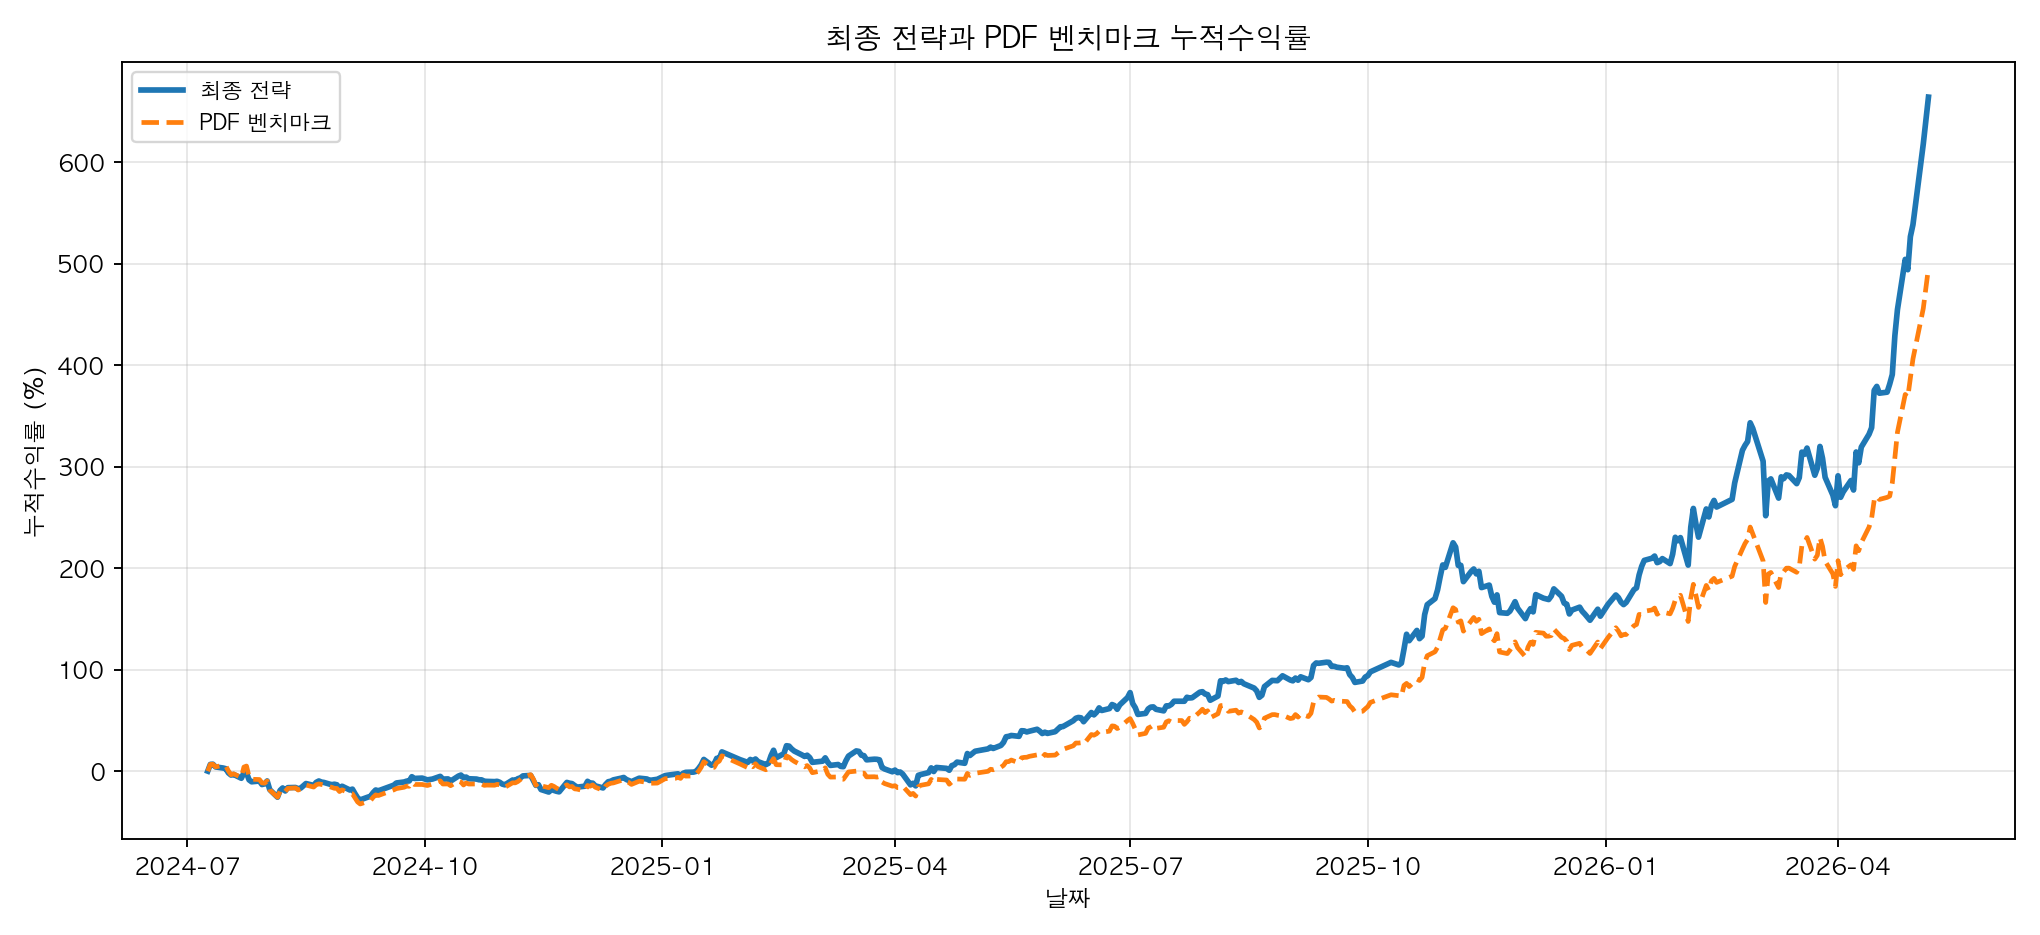

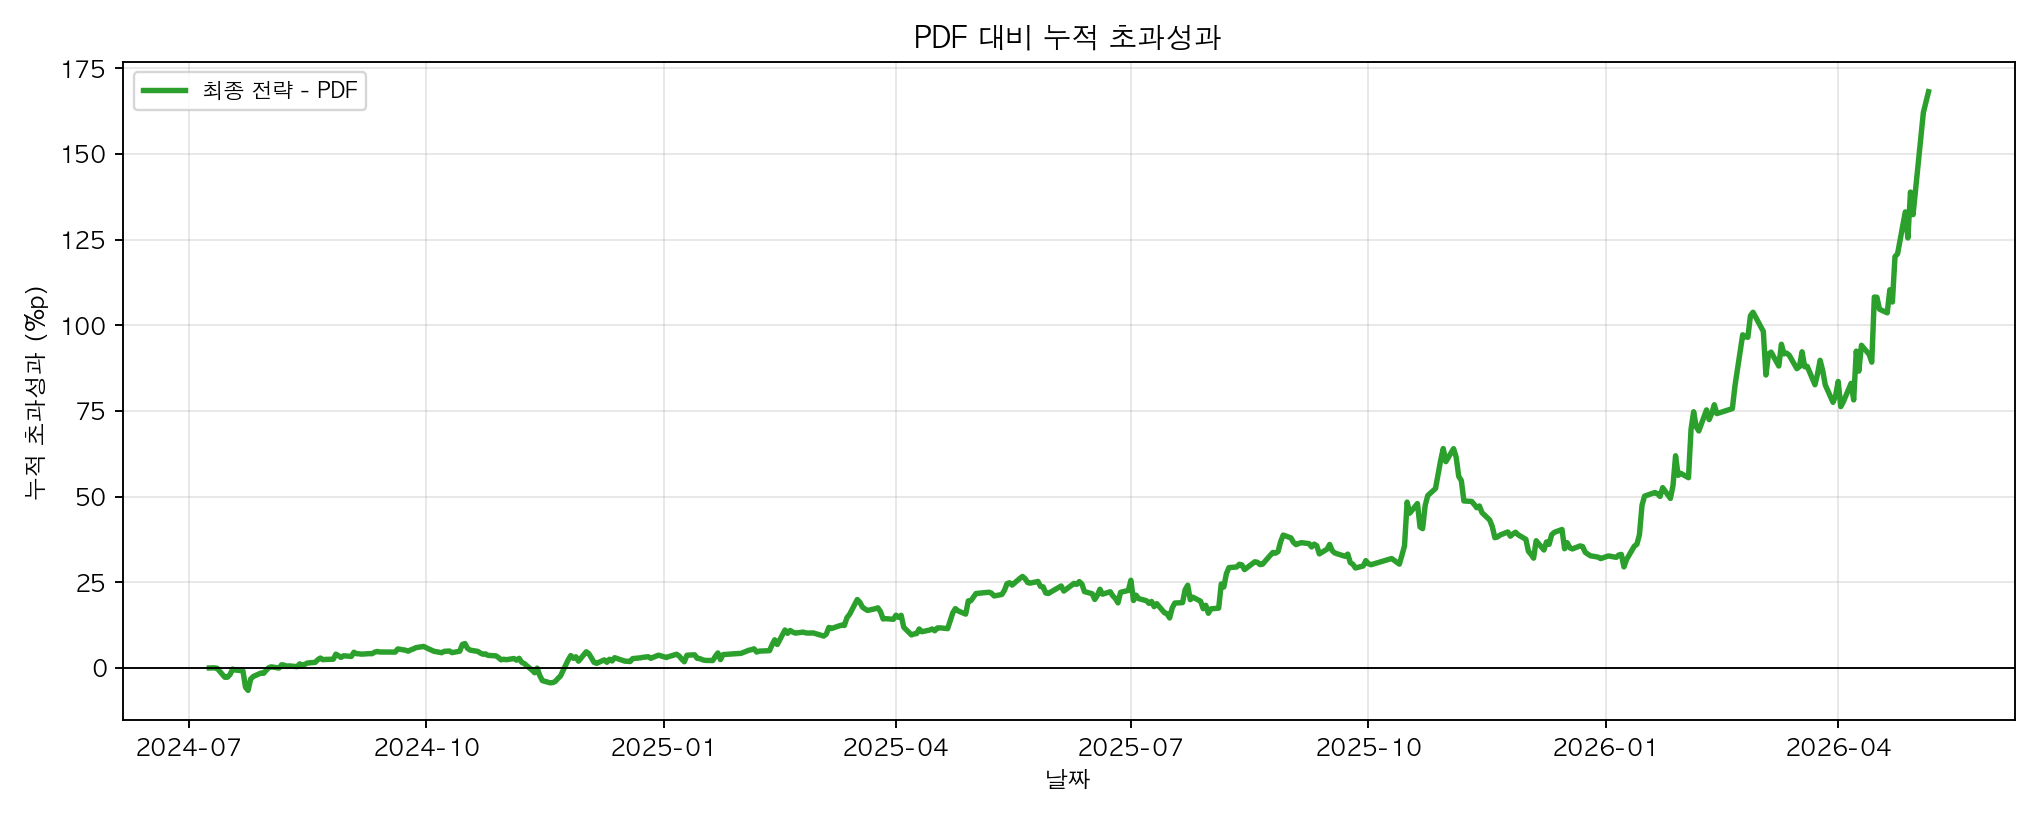

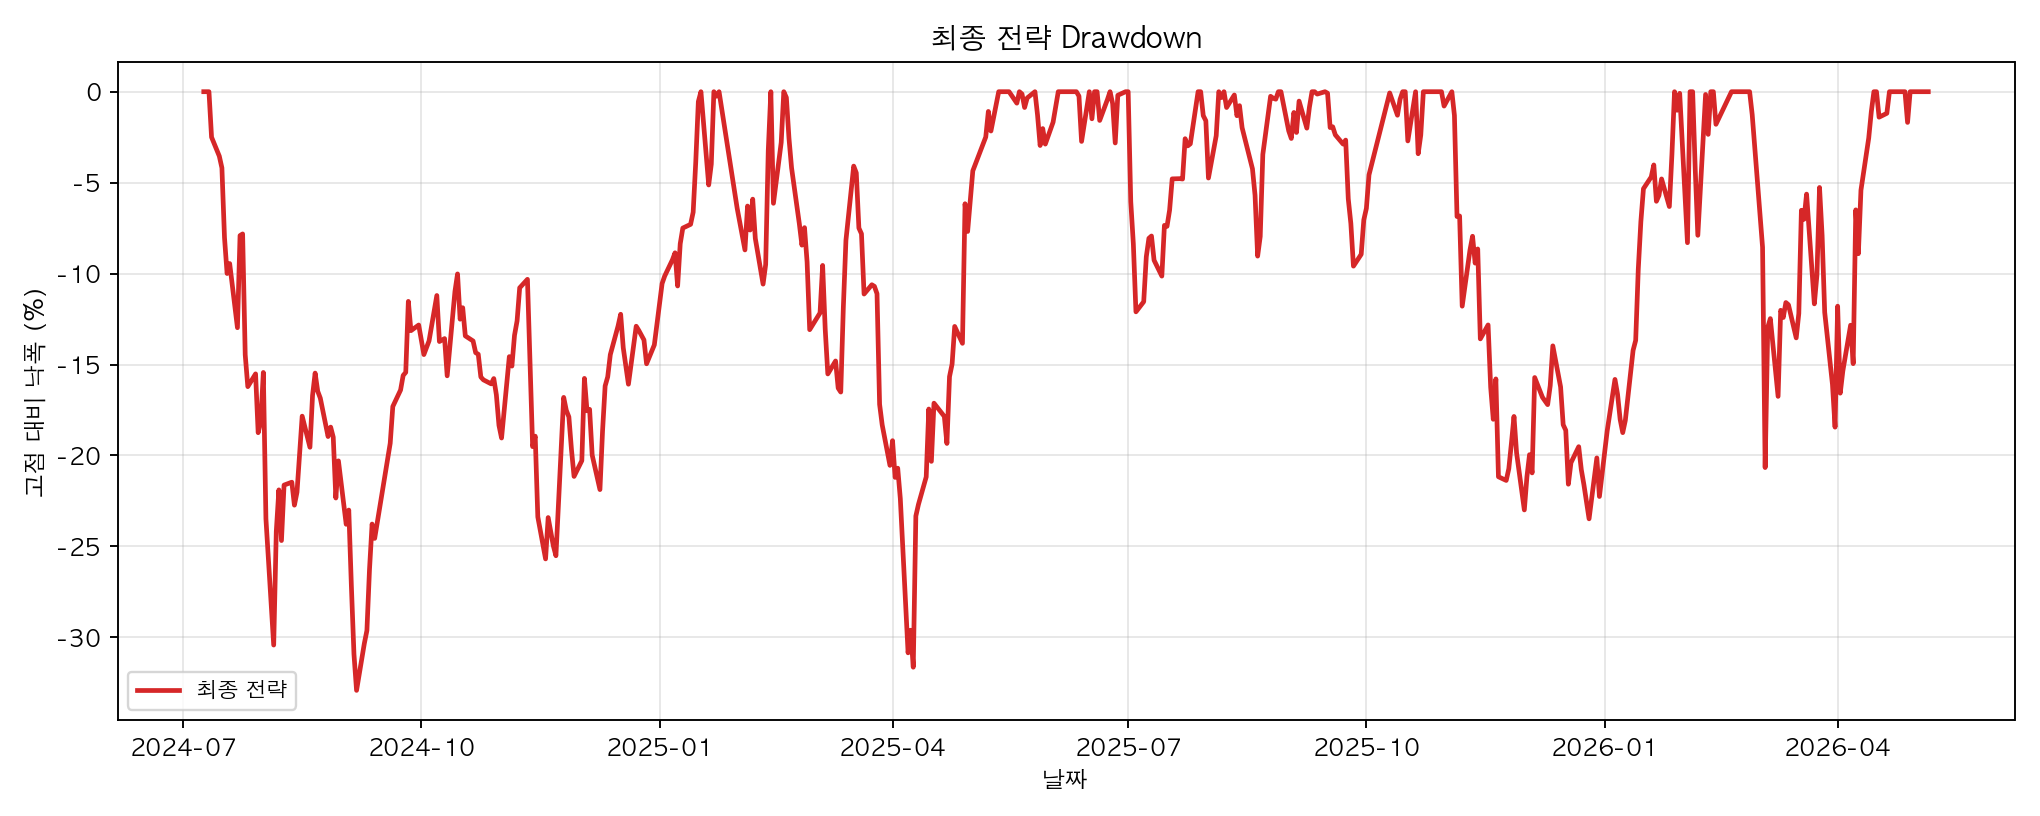

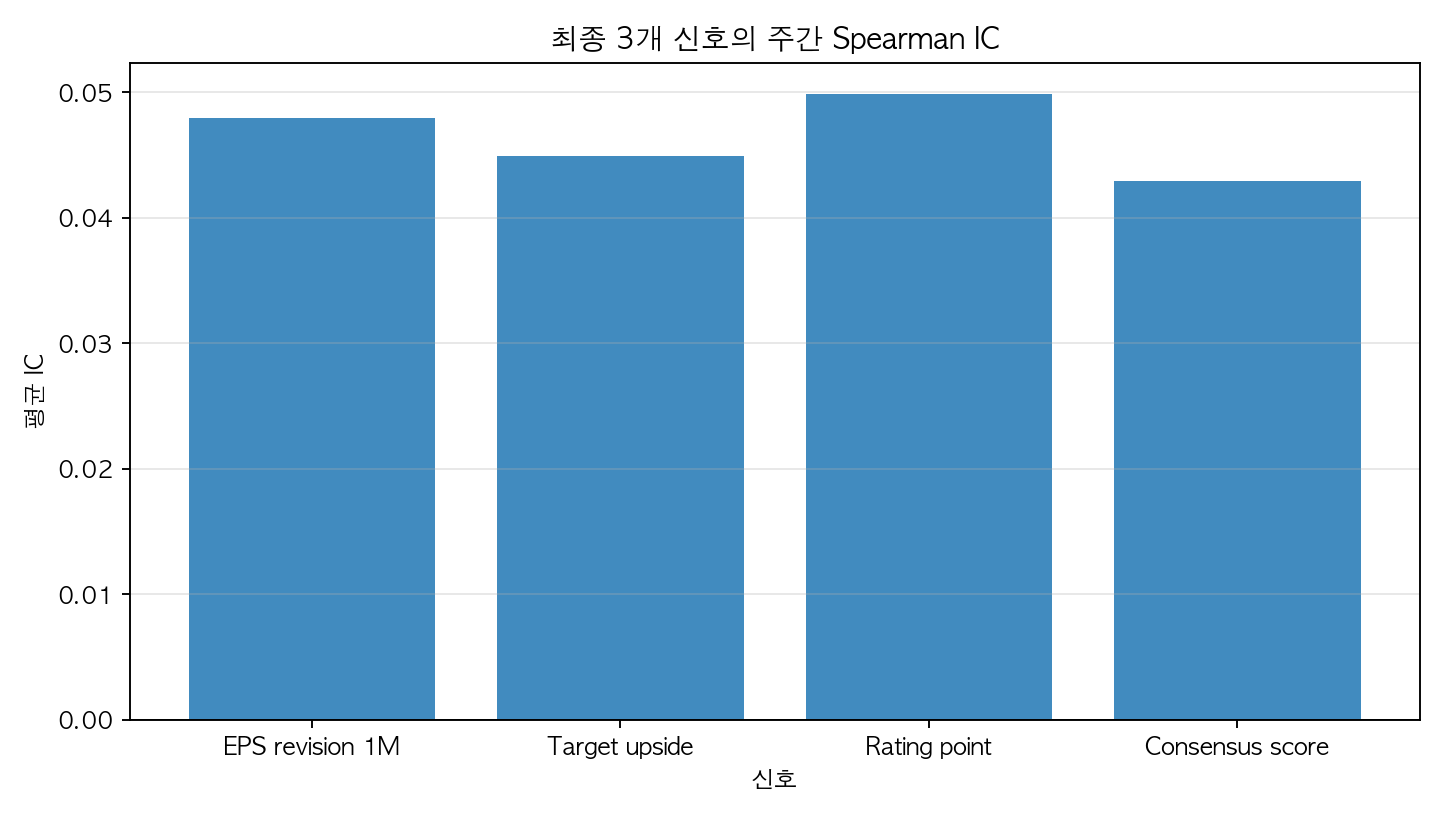

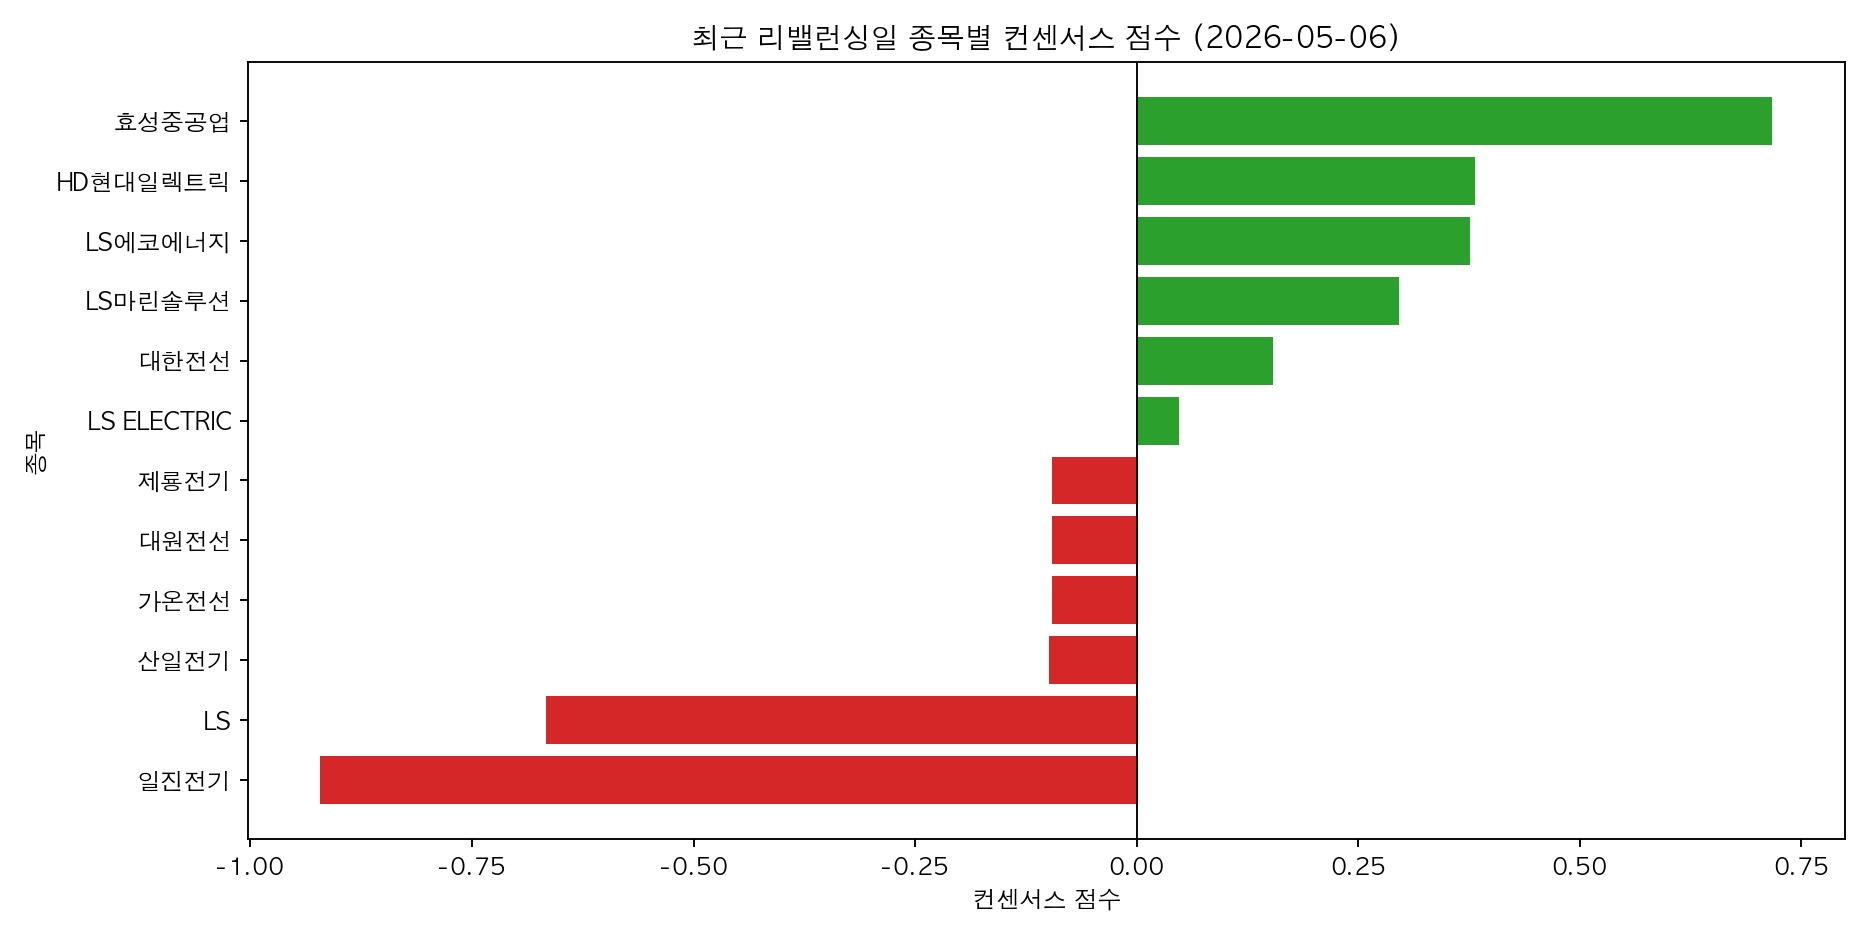

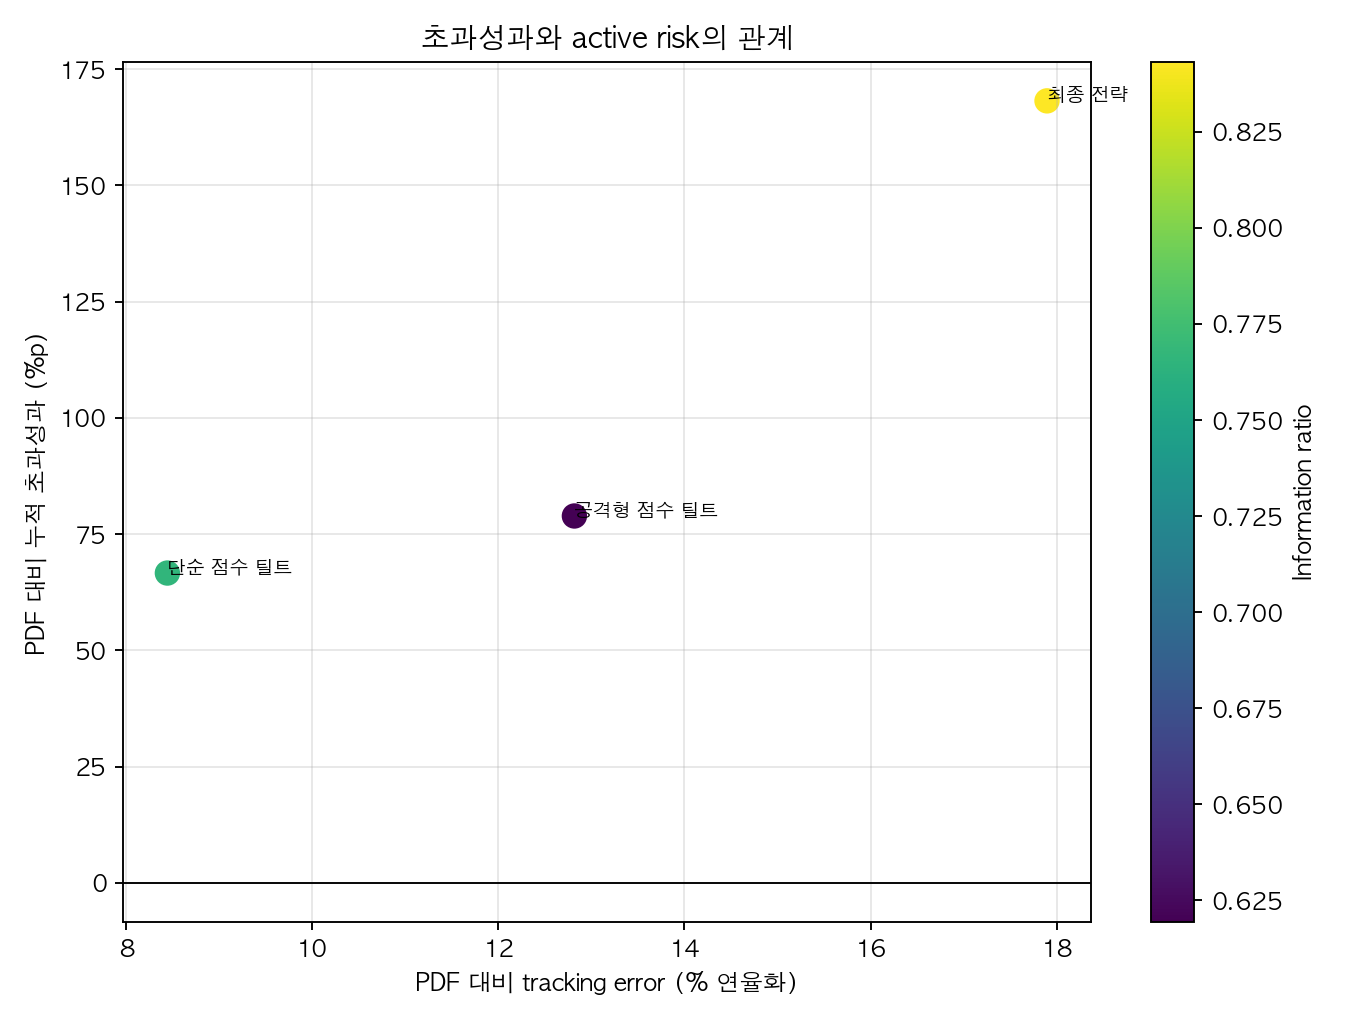

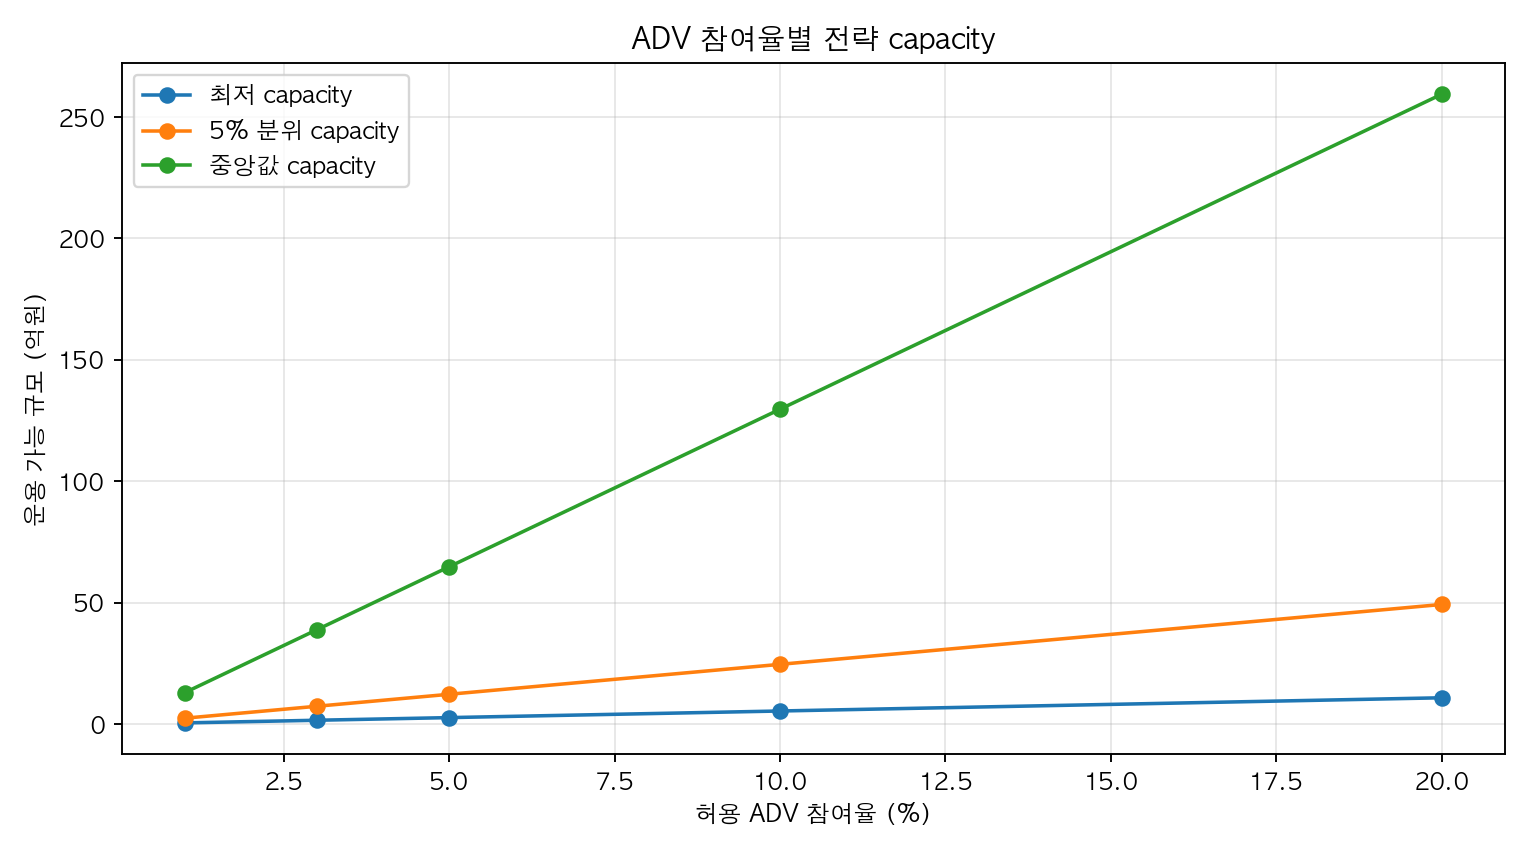

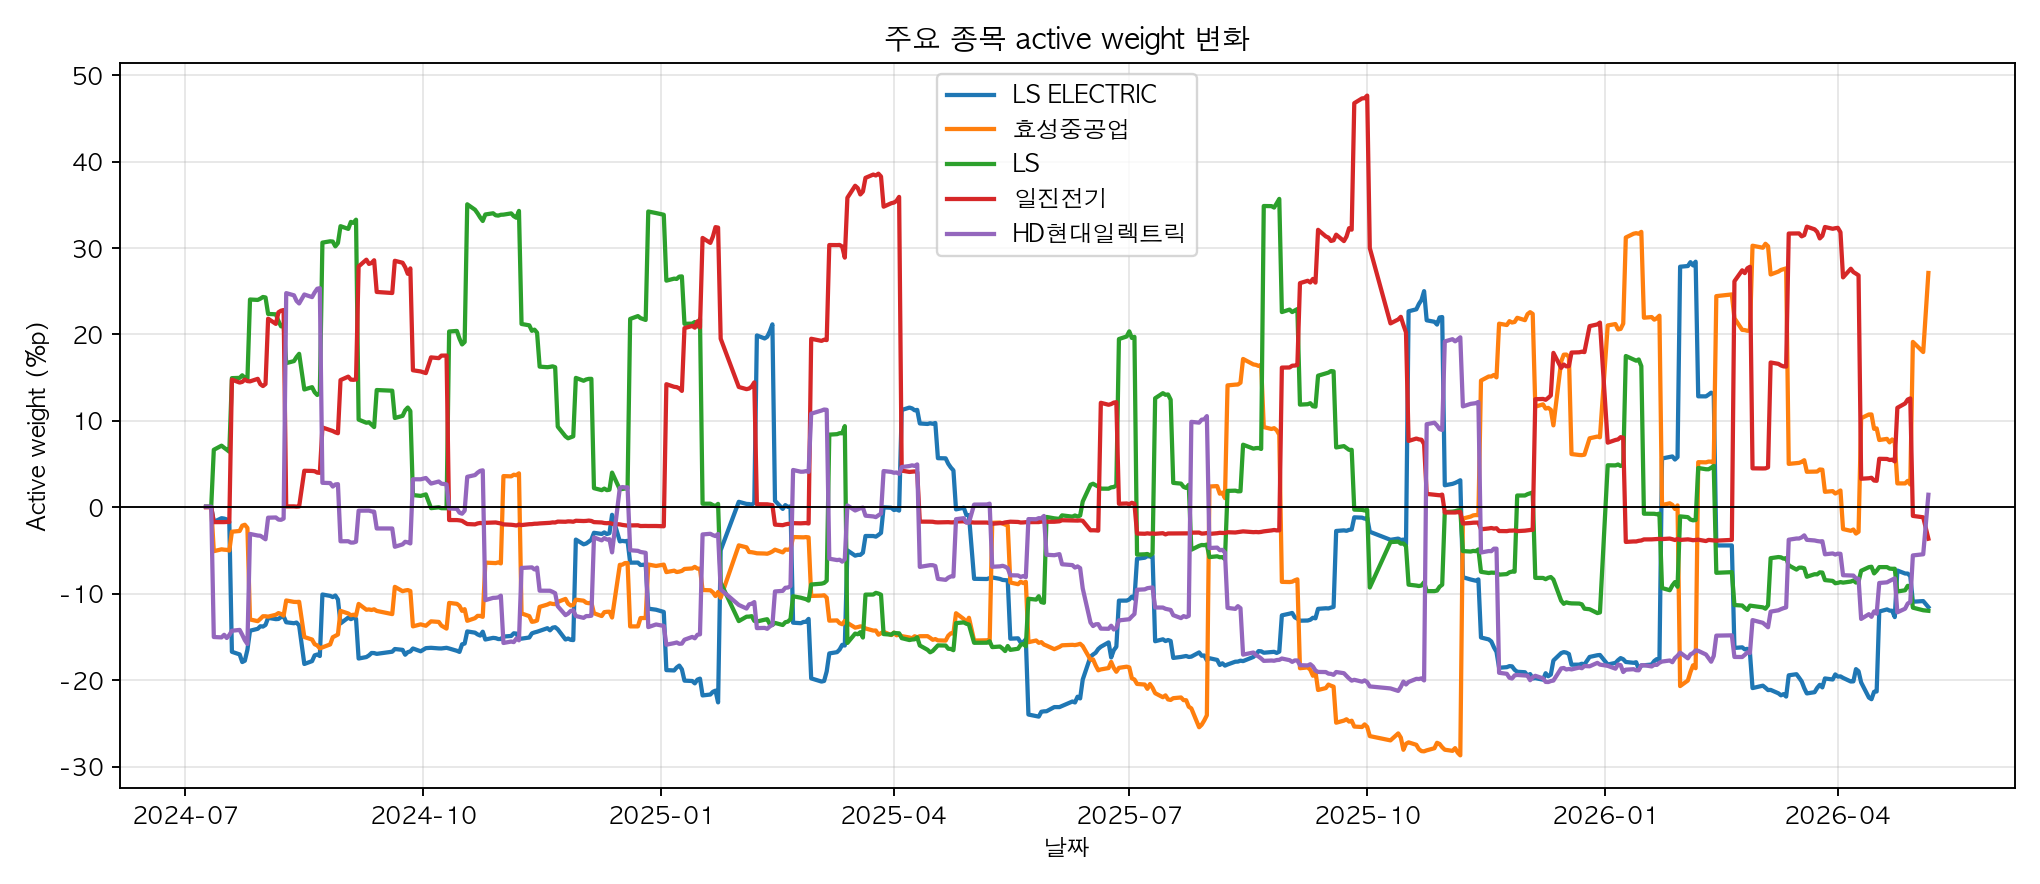

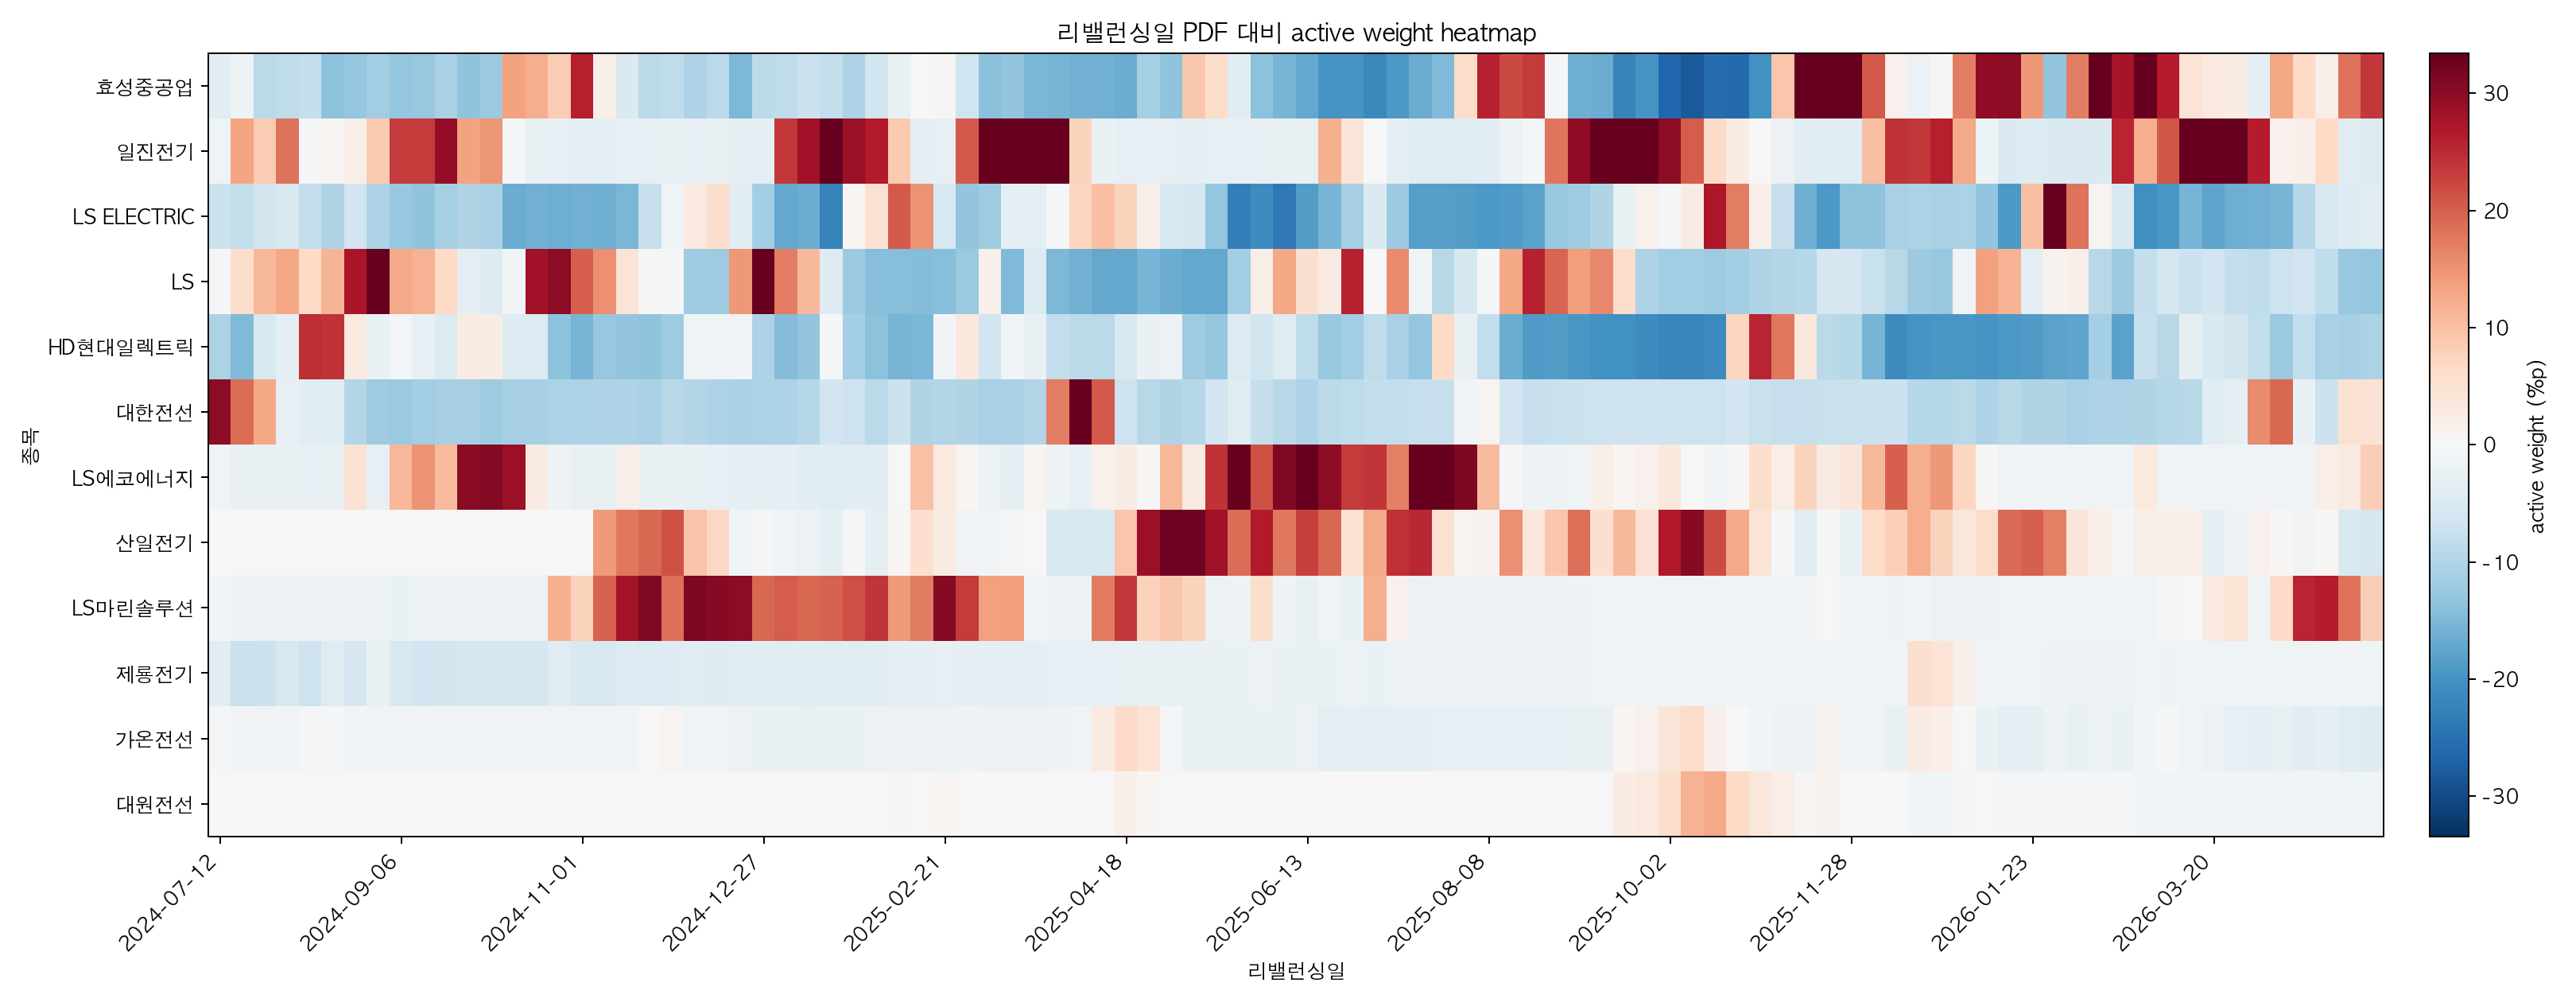

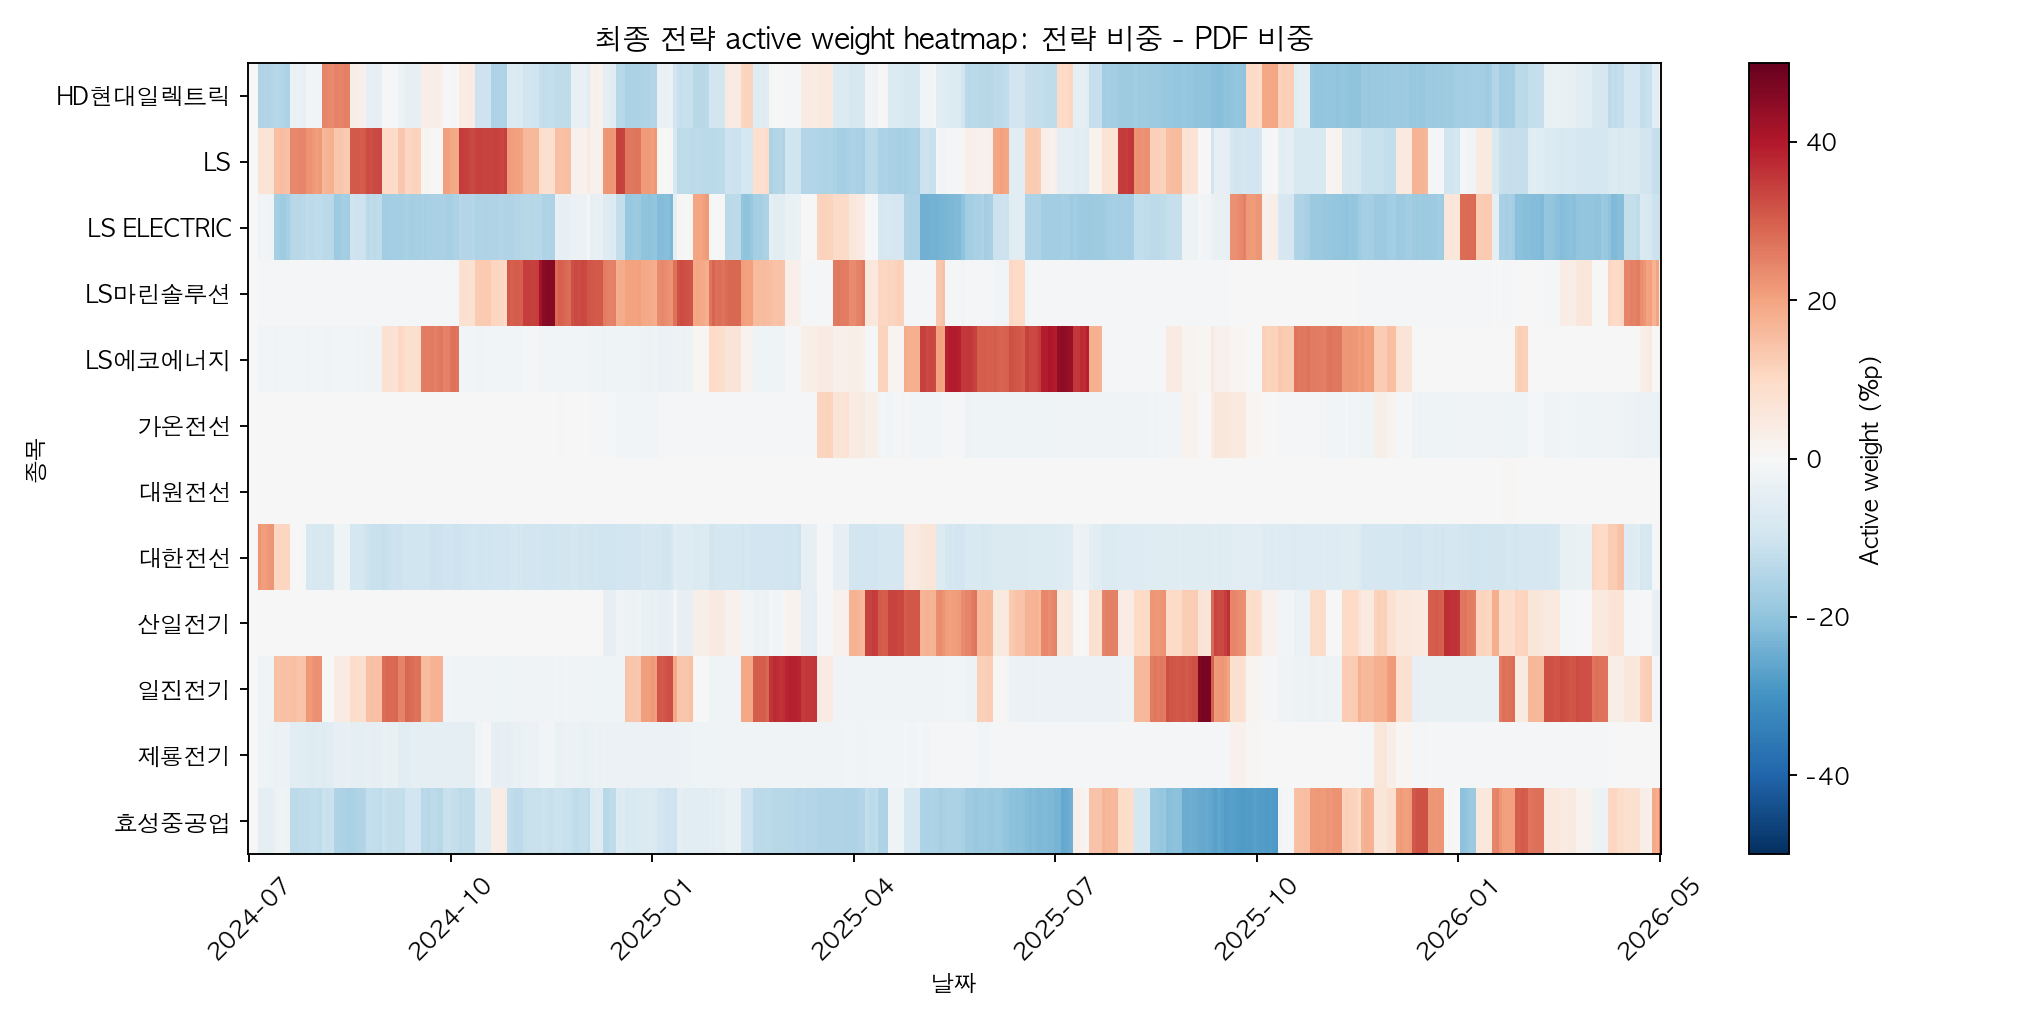

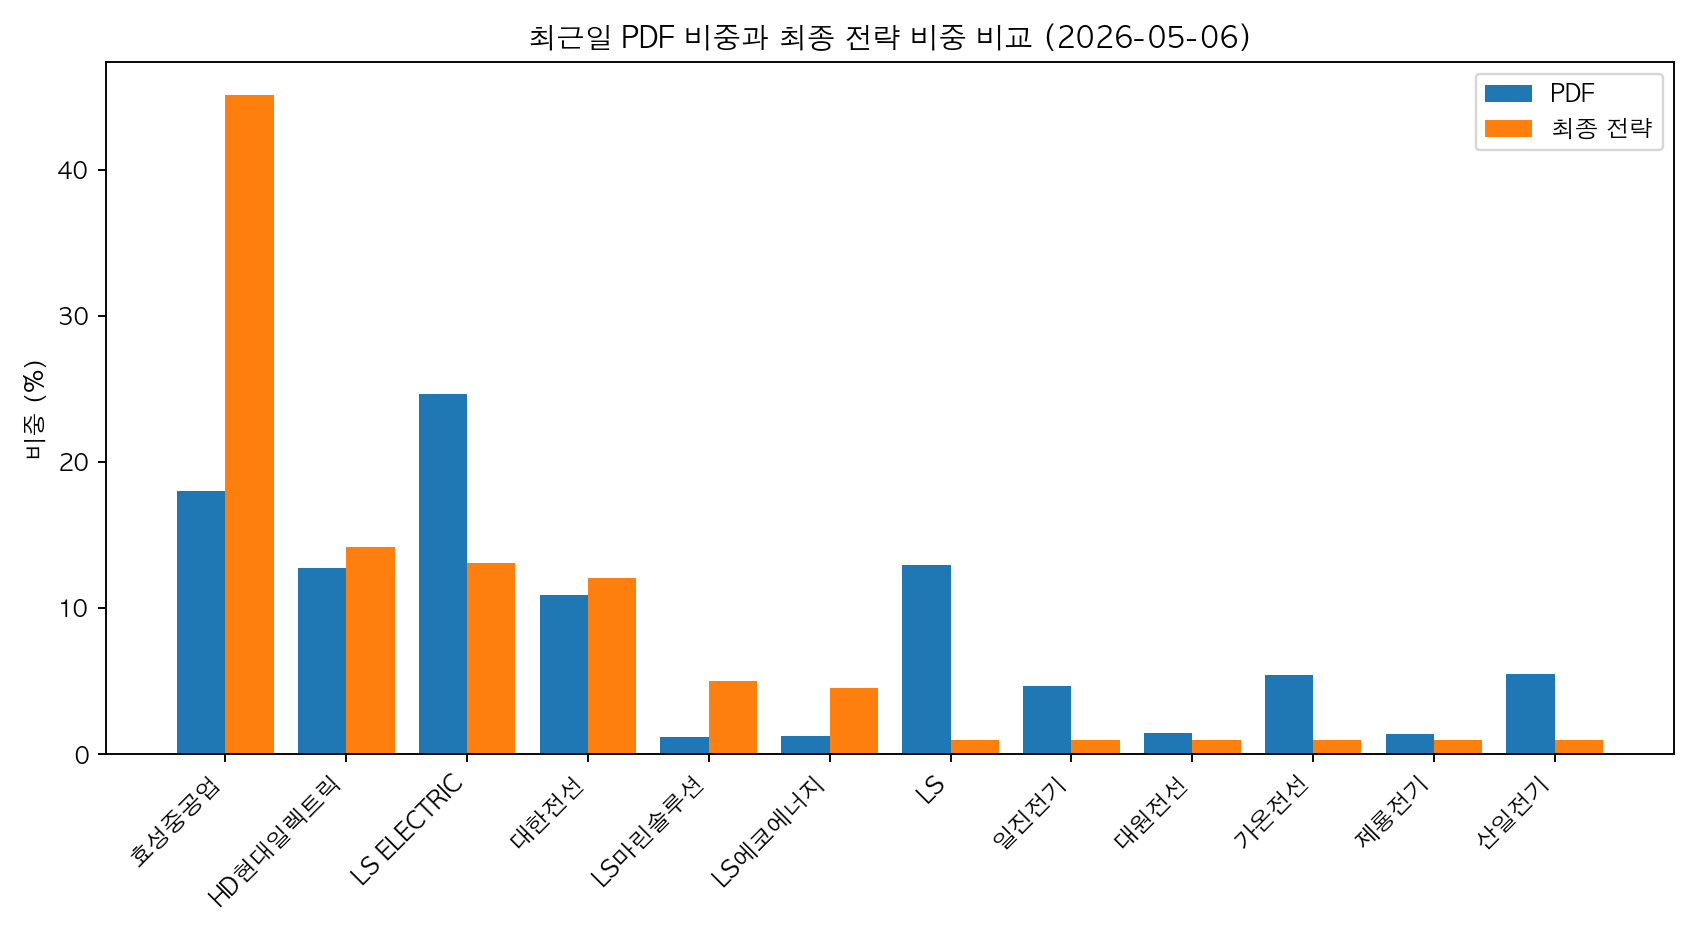

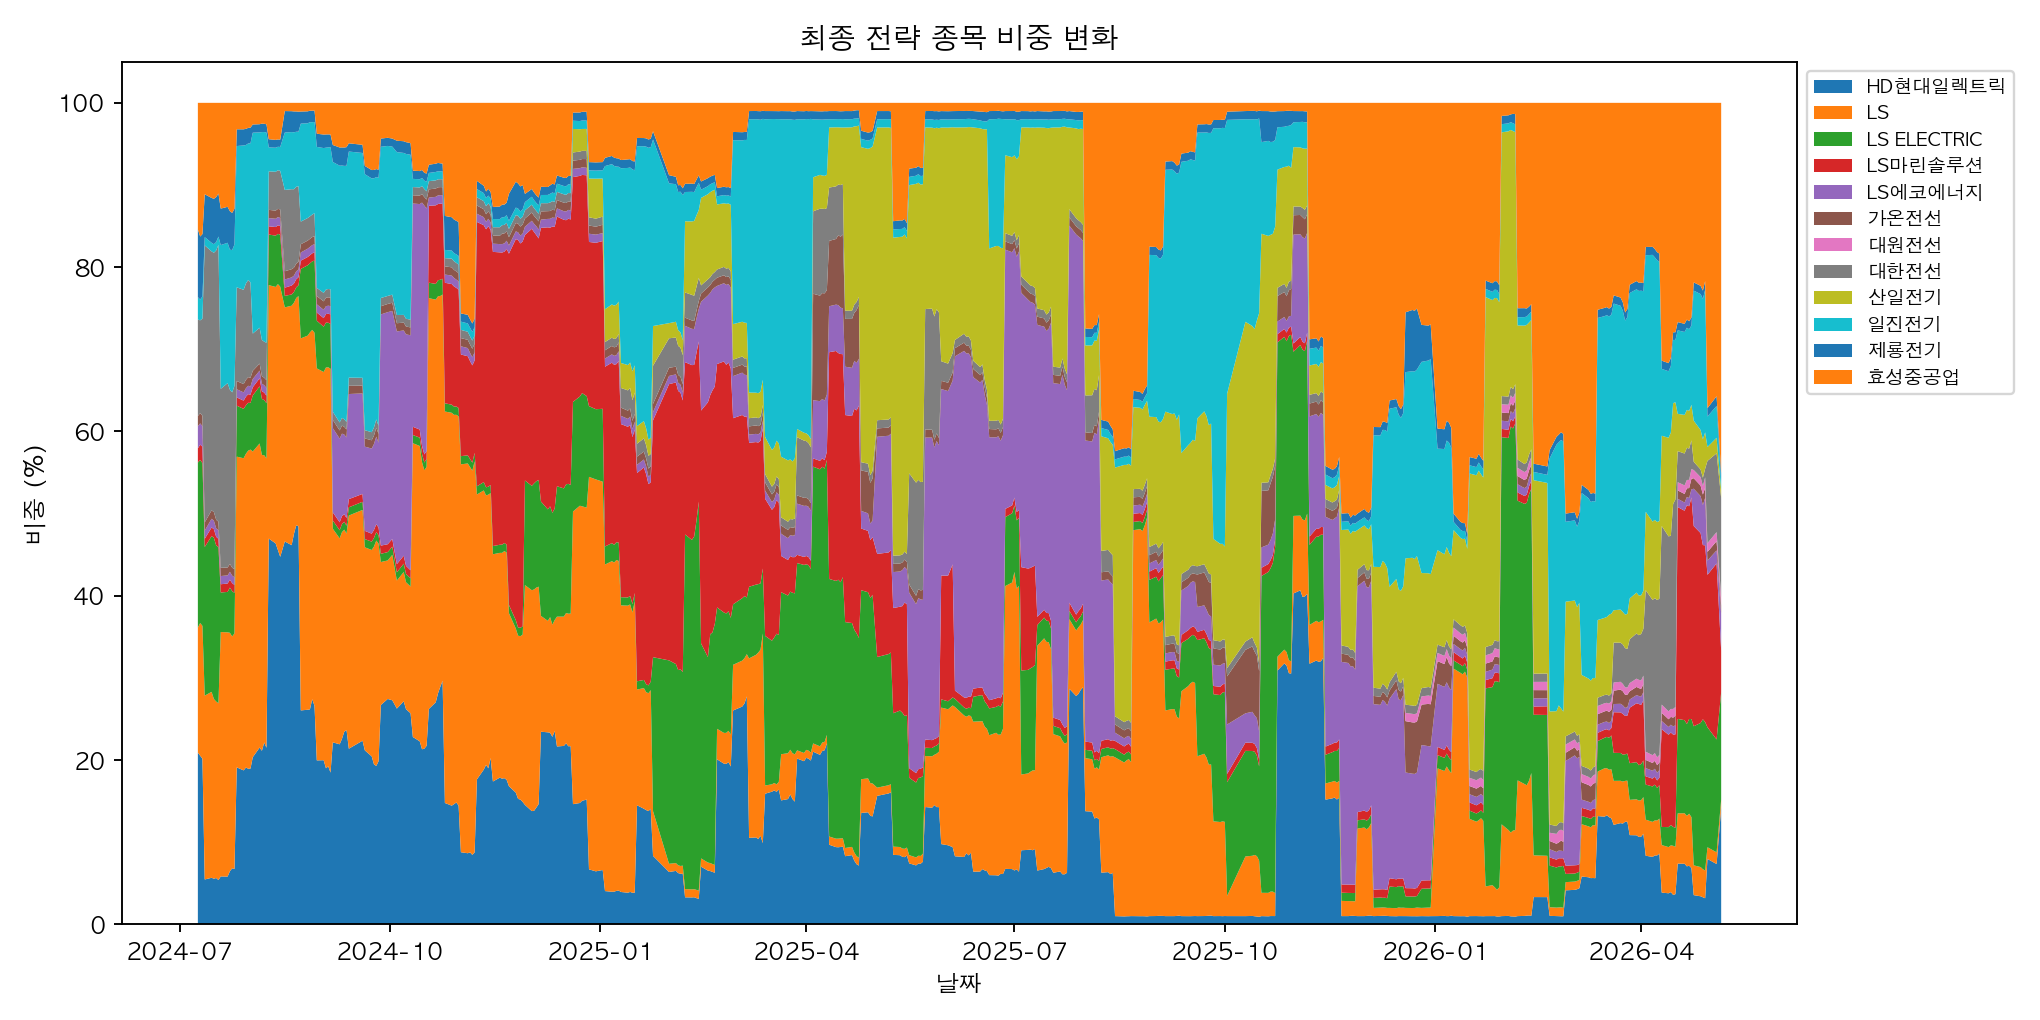

In [7]:
for img in [
    'chart_final_cumulative_return.png',
    'chart_final_cumulative_active_return.png',
    'chart_final_drawdown.png',
    'chart_final_weekly_ic.png',
    'chart_consensus_score_latest_scores.png',
    'chart_consensus_score_return_vs_te.png',
    'chart_strategy_capacity_sensitivity.png',
    'chart_final_top_active_weight_lines.png',
    'chart_final_active_weight_heatmap.png',
    'chart_final_vs_pdf_weight_diff_heatmap.png',
    'chart_final_latest_weight_comparison.png',
    'chart_final_strategy_weight_stack.png',
]:
    path = OUTPUT / img
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'missing: {path}')


## 13. 추가로 받으면 좋은 데이터

현재 최종 score는 설명 가능성과 데이터 안정성을 위해 3개 팩터만 사용했습니다.

```text
ConsensusScore
= 1/3 * z(EPS revision 1M)
+ 1/3 * z(Target upside)
+ 1/3 * z(Rating point)
```

다음 단계에서 가장 먼저 추가하면 좋은 데이터는 **분기 컨센서스**입니다. 삼성증권 리포트의 “다음 분기 실적 분위기”와 더 가깝게 만들 수 있기 때문입니다.

| 우선순위 | DataGuide에서 받을 데이터 | 만들 수 있는 팩터 | 용도 |
|---:|---|---|---|
| 1 | 분기 EPS 컨센서스 FQ1 일별 시계열 | `eps_revision_fq1_1m` | 다음 분기 EPS 전망 변화 |
| 2 | 분기 영업이익 컨센서스 FQ1 일별 시계열 | `op_revision_fq1_1m` | 다음 분기 영업이익 전망 변화 |
| 3 | 일별 목표주가 평균 시계열 | `target_price_revision_21d` | 목표가 변화율, sentiment momentum |
| 4 | 투자의견 상향/하향/유지 수 | `rating_revision_balance` | 의견 변화 방향 |

현재의 `rating_point`는 느리게 움직이는 보조 신호입니다. 분기 EPS나 분기 영업이익 revision이 들어오면, `rating_point`를 대체하거나 보완하는 것이 가장 자연스럽습니다.


## 14. 한계와 방어 문장

이 결과를 발표할 때 가장 안전한 표현은 다음입니다.

> 본 연구는 장기적으로 확정된 alpha를 증명한 것이 아니라, KODEX AI전력핵심설비 ETF의 관측 PDF 바스켓을 기준으로, 구성종목 내부의 컨센서스 신호를 이용한 active overlay 가능성을 확인한 연구입니다.

주요 한계는 다음입니다.

- ETF 상장 이후 표본이 짧습니다.
- 구성종목 수가 적어 IC의 통계적 안정성이 제한됩니다.
- 컨센서스 데이터가 없는 종목은 중앙값으로 보완했지만, 정보가 충분하다는 뜻은 아닙니다.
- 초과성과는 active risk를 사용한 결과이므로 TE와 IR을 같이 봐야 합니다.
- 공분산 행렬은 60거래일 표본으로 추정하므로 추정오차가 있습니다.
- 비용과 turnover 가정은 결과에 영향을 줄 수 있으므로 비용 반영 성과를 기준으로 설명해야 합니다.

공격 질문에 대한 짧은 답변은 다음입니다.

| 질문 | 답변 |
|---|---|
| 공분산 60일이 초반에 부족하지 않나요? | 새 보강 파일과 PDF 유니버스 제한으로 해결했습니다. 최종 전략 기준으로 모든 리밸런싱에서 현재 PDF 편입종목은 60개 수익률 관측치를 확보했습니다. |
| 왜 PDF를 벤치마크로 쓰나요? | 이 전략은 ETF 구성종목을 새로 고르는 것이 아니라, 실제 KRX PDF 바스켓 안에서 비중만 조정하기 때문입니다. |
| 편입된 지 얼마 안 된 종목도 미리 산 것 아닌가요? | 아닙니다. 투자 후보는 리밸런싱일 PDF 비중이 0보다 큰 종목으로 제한했습니다. 산일전기와 대원전선도 PDF 최초 편입일 이전 전략 비중은 0으로 확인했습니다. |
| 왜 TE가 20%인가요? | 20%는 1년 동안 PDF보다 반드시 20%p 다르게 간다는 뜻이 아니라, active return 변동성의 연율화 예산입니다. 실제 realized TE는 17.90%였습니다. |
| TE가 너무 큰 것 아닌가요? | 패시브 복제 기준이면 큰 편이지만, 최종 전략은 active overlay입니다. 그래서 TE만 보지 않고 PDF 대비 초과성과, IR, 상관계수를 함께 봅니다. 전략-PDF 상관계수는 0.947로 같은 테마 흐름은 유지했습니다. |
| 최종 전략 변동성이 너무 커진 것 아닌가요? | 최종 전략 연환산 변동성은 55.78%, PDF 벤치마크는 54.10%입니다. 전체 변동성이 크게 폭증했다기보다는, 비중조정 때문에 active return 변동성이 추가된 구조입니다. |
| 왜 편입종목이 0%가 아니고 1%인가요? | ETF 편입종목을 완전히 제외하는 것은 발표에서 공격받기 쉬워, 최종전략은 PDF 편입종목을 최소 1% 보유하도록 바꿨습니다. 신호가 약한 종목은 0%가 아니라 1% floor까지 축소됩니다. |
| 과적합 아닌가요? | 완전히 배제할 수 없습니다. 그래서 IC, top-bottom, 비용 반영 성과, TE/IR을 함께 봅니다. 표본이 짧으므로 확정적 alpha가 아니라 전략 후보로 해석합니다. |
| 왜 다른 배분모형을 안 쓰나요? | 이 연구의 목적은 기대수익률을 새로 추정하거나 위험균등 포트폴리오를 만드는 것이 아니라, 검증한 consensus score를 PDF 대비 비중조정에 직접 쓰는 것입니다. 그래서 score는 직접 active weight 방향으로 쓰고, MVO로 active risk만 제어합니다. |
| 절대수익률이 높은 건 테마장 때문 아닌가요? | 맞습니다. 그래서 절대수익률보다 PDF 대비 초과성과, TE, IR을 중심으로 평가합니다. |


<!-- practical_interpretation_section -->

## 15. 실무적 해석: 5개 질문에 대한 답

### 1. Historical backtest에서 일관된 성과를 보였는가?

큰 방향에서는 **그렇습니다.** 최종 전략은 비용 반영 후 누적수익률 **664.06%**를 기록했고, PDF 벤치마크 누적수익률 **495.88%** 대비 **+168.18%p**의 초과성과를 보였습니다. PDF 대비 tracking error는 **17.90%**, information ratio는 **0.843**, PDF와의 일별 수익률 상관계수는 **0.947**입니다.

다만 이 결과를 “매 기간 안정적으로 이겼다”라고 말하면 위험합니다. 최대낙폭은 **-32.92%**였고, 종목별 attribution도 일부 overweight 결정에 플러스 기여가 집중되었습니다.

발표에서는 이렇게 말하는 것이 안전합니다.

```text
Historical backtest에서는 PDF 대비 초과성과가 뚜렷했지만,
성과 경로는 테마 ETF 특유의 큰 변동성과 일부 종목 기여도 집중을 동반했다.
```

### 2. Resampling / Monte Carlo에서도 성과가 유지되었는가?

대체로 유지되었습니다. 5거래일 block bootstrap과 Student-t Monte Carlo를 각각 2,000개 경로로 돌렸을 때, 초과 누적수익률 중앙값은 각각 **130.59%**, **149.54%**였습니다. 초과성과가 양수였던 비율도 block bootstrap **88.10%**, Monte Carlo **86.15%**입니다.

| 검증 방식 | 초과 누적수익률 중앙값 | 초과성과 양수 비율 | TE 중앙값 | TE 20% 이하 비율 |
|---|---:|---:|---:|---:|
| Historical path | 168.18% | - | 17.90% | - |
| Block bootstrap 5D | 130.59% | 88.10% | 17.82% | 97.95% |
| Monte Carlo Student-t | 149.54% | 86.15% | 17.75% | 96.45% |

하지만 5% 분위수에서는 초과성과가 음수입니다. Block bootstrap의 5% 분위 초과수익률은 **-49.81%**, Monte Carlo의 5% 분위는 **-62.70%**입니다. 따라서 이 검증은 “미래에도 반드시 이긴다”는 증명이 아니라, **특정 historical path 하나에만 완전히 의존한 결과는 아닐 가능성이 있다**는 보조 근거입니다.

### 3. 성과는 높은데도 실제 운용이 어려울 수 있는 이유

가장 큰 이유는 **turnover, capacity, 집중도**입니다.

| 항목 | 최종 전략 수치 | 실무적 의미 |
|---|---:|---|
| 평균 리밸런싱 one-way turnover | 21.71% | 매주 상당한 비중 이동이 발생하므로 체결비용과 슬리피지가 누적됨 |
| 기준 capacity | 3일 분할ㆍ10% ADVㆍ시계열 하위 10% 99.09억 원 | 실행 가능성을 고려한 기준 운용규모 |
| 보수 capacity | 1일 체결ㆍ5% ADVㆍ시계열 하위 5% 12.33억 원 | 유동성이 약한 구간을 강하게 보수적으로 본 stress 기준 |
| 최신 HHI | 0.261 | PDF보다 특정 종목 집중도가 높음 |
| 최신 effective holdings | 3.84개 | 실질적으로 4개 안팎의 종목에 위험이 집중된 구조 |

즉 백테스트 성과가 좋아도, 실제 운용에서는 주문 규모가 커질수록 시장충격과 슬리피지가 커질 수 있습니다.

### 4. 거래비용과 capacity를 고려해도 실무적으로 매력적인가?

**소규모 active overlay 전략으로는 매력적입니다.** 최종 성과는 이미 매매비용과 펀드 총보수ㆍ비용을 반영한 값입니다. 비용 반영 후에도 PDF 대비 초과성과가 **+168.18%p**였고, stress cost와 격주 리밸런싱 sensitivity에서도 초과성과가 양수로 유지되었습니다.

다만 큰 운용규모로 바로 확장하기에는 조심해야 합니다. 발표 기준 capacity는 **3일 분할 체결ㆍ10% ADV 참여율ㆍ시계열 하위 10% 기준 약 99억 원**입니다. 더 보수적으로 하루에 모두 체결하고 5% ADV만 허용하면 약 **12억 원**까지 낮아집니다. 따라서 99억 원은 실행 가능성을 고려한 기준값이고, 12억 원은 stress 성격의 보수값으로 함께 제시하는 것이 안전합니다.

실무 적용을 위해서는 다음 보완이 필요합니다.

- 종목별 ADV 참여율 제약을 최적화에 직접 추가
- 주문을 여러 날에 나누는 execution schedule
- turnover limit 하향
- 유동성이 작은 종목의 active weight 상한 축소
- slippage stress scenario를 더 보수적으로 적용

### 5. 가장 중요한 리스크는 무엇인가?

가장 중요한 리스크는 **테마 집중과 active weight 집중이 동시에 존재한다는 점**입니다.

이 전략은 KODEX AI전력핵심설비 ETF 구성종목 안에서만 움직이므로, 유니버스 자체가 전력설비 테마에 집중되어 있습니다. 여기에 MVO가 consensus score가 높은 종목으로 비중을 더 몰아주기 때문에, 최신 effective holdings는 약 **3.84개**까지 낮아졌습니다.

| 리스크 | 설명 | 대응 |
|---|---|---|
| 테마 리스크 | AI 전력설비 테마 전체가 꺾이면 PDF와 전략이 같이 하락 | PDF 대비 성과와 절대 drawdown을 분리해서 관리 |
| 종목 집중 리스크 | 일부 종목 overweight가 성과와 위험을 동시에 키움 | HHI, max weight, effective holdings 모니터링 |
| 거래비용ㆍ슬리피지 리스크 | 주간 리밸런싱과 높은 turnover가 비용을 키움 | turnover limit, stress cost, ADV 제약 추가 |
| 표본ㆍ과적합 리스크 | ETF 상장 이후 표본이 짧고 구성종목 수가 적음 | resampling, Monte Carlo, 향후 실시간 성과 검증 |

최종 발표 문장은 이렇게 정리할 수 있습니다.

> 최종 전략은 historical backtest와 resampling/Monte Carlo에서 유망한 active overlay 후보로 보였지만, 확정적 alpha 증명은 아닙니다. 실무적으로는 PDF 대비 초과성과와 IR이 매력적인 반면, 주간 turnover, 유동성 capacity, 종목 집중도, 짧은 표본이라는 리스크를 함께 관리해야 합니다.




## 16. Factsheet용 숫자와 그래프

아래 섹션은 발표 본문 설명용이라기보다, factsheet 디자인에 그대로 옮겨 넣을 수 있는 **숫자ㆍ표ㆍ그래프 재료**입니다.

factsheet에서는 최종 전략을 공식 비교지수와 나란히 보여주는 것이 자연스럽기 때문에, 여기서는 직접 벤치마크인 PDF가 아니라 **iSelect AI전력핵심설비 기초지수**와 비교합니다.

색상은 다음처럼 고정했습니다.

```text
최종 전략: 와인색
기초지수: 회색
```

생성되는 주요 산출물은 다음입니다.

| 파일 | 내용 |
|---|---|
| `output/factsheet_key_info.csv` | factsheet 상단에 넣을 기본 정보 |
| `output/factsheet_performance_summary_pretty.csv` | 최종 전략 vs 기초지수 성과ㆍ위험 요약 |
| `output/factsheet_period_returns_pretty.csv` | MTD, YTD, 1M, 3M, 6M, 1Y, 설정 이후 수익률 |
| `output/factsheet_calendar_year_returns_pretty.csv` | 연도별 수익률 |
| `output/factsheet_top10_holdings_pretty.csv` | 최근일 최종 전략 상위 보유종목 |
| `output/chart_factsheet_cumulative_vs_index.png` | 최종 전략과 기초지수 누적성과 |
| `output/chart_factsheet_drawdown_vs_index.png` | 최종 전략과 기초지수 drawdown |
| `output/chart_factsheet_period_returns_vs_index.png` | 기간별 수익률 비교 |
| `output/chart_factsheet_rolling_te_vs_index.png` | 기초지수 대비 rolling 60D active risk |

주의할 점은 두 가지입니다.

1. 최종 전략 설계와 active overlay 평가의 직접 기준은 여전히 **PDF replication**입니다.
2. factsheet 형식에서는 투자자가 익숙한 공식 비교지수와의 비교가 필요하므로, 이 섹션에서는 **기초지수 대비 성과**를 별도로 보여줍니다.



Factsheet key info


,item,value
0,Factsheet date,2026-05-06
1,Strategy,Consensus Active MVO
2,Benchmark,iSelect AI전력핵심설비 지수
3,Universe,KODEX AI전력핵심설비 ETF KRX PDF constituents
4,Rebalancing,Weekly
5,Factor score,"Equal-weighted EPS revision 1M, target upside,..."
6,MVO TE budget,20% ex-ante annualized
7,Max stock weight,50%
8,One-way turnover limit,30%
9,Average one-way turnover,4.71%


Performance summary: strategy vs underlying index


,name,observations,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,excess_cumulative_return_pct_point,tracking_error_vs_index,information_ratio_vs_index,correlation_vs_index,active_mean_daily,start_date,end_date
0,Consensus Active MVO,441,664.06%,219.63%,55.78%,3.937,-32.92%,+165.45%p,17.90%,0.821,0.947,0.06%,2024-07-10,2026-05-06
1,Underlying Index,441,498.60%,178.02%,54.32%,3.277,-36.79%,NaN,NaN,NaN,NaN,NaN,2024-07-10,2026-05-06


Period returns


,period,start_date,end_date,strategy_return,underlying_index_return,excess_return_pct_point
0,MTD,2026-05-04,2026-05-06,19.68%,17.75%,+1.93%p
1,YTD,2026-01-02,2026-05-06,202.41%,170.43%,+31.98%p
2,1M,2026-04-06,2026-05-06,103.67%,100.65%,+3.02%p
3,3M,2026-02-06,2026-05-06,122.41%,118.47%,+3.93%p
4,6M,2025-11-06,2026-05-06,152.43%,142.10%,+10.34%p
5,1Y,2025-05-07,2026-05-06,538.81%,511.48%,+27.33%p
6,Since inception,2024-07-10,2026-05-06,664.06%,498.60%,+165.45%p


Calendar year returns


,year,strategy_return,underlying_index_return,excess_return_pct_point
0,2024,-8.03%,-11.78%,+3.75%p
1,2025,174.72%,150.91%,+23.81%p
2,2026,202.41%,170.43%,+31.98%p


Top 10 holdings


,date,stock_code,stock_name,strategy_weight,pdf_weight,active_weight
0,2026-05-06,298040,효성중공업,45.12%,18.00%,+27.12%p
1,2026-05-06,267260,HD현대일렉트릭,14.20%,12.74%,+1.46%p
2,2026-05-06,10120,LS ELECTRIC,13.06%,24.61%,-11.55%p
3,2026-05-06,1440,대한전선,12.08%,10.88%,+1.20%p
4,2026-05-06,60370,LS마린솔루션,5.02%,1.14%,+3.88%p
5,2026-05-06,229640,LS에코에너지,4.52%,1.23%,+3.29%p
6,2026-05-06,6260,LS,1.00%,12.97%,-11.97%p
7,2026-05-06,103590,일진전기,1.00%,4.63%,-3.63%p
8,2026-05-06,6340,대원전선,1.00%,1.43%,-0.43%p
9,2026-05-06,500,가온전선,1.00%,5.38%,-4.38%p


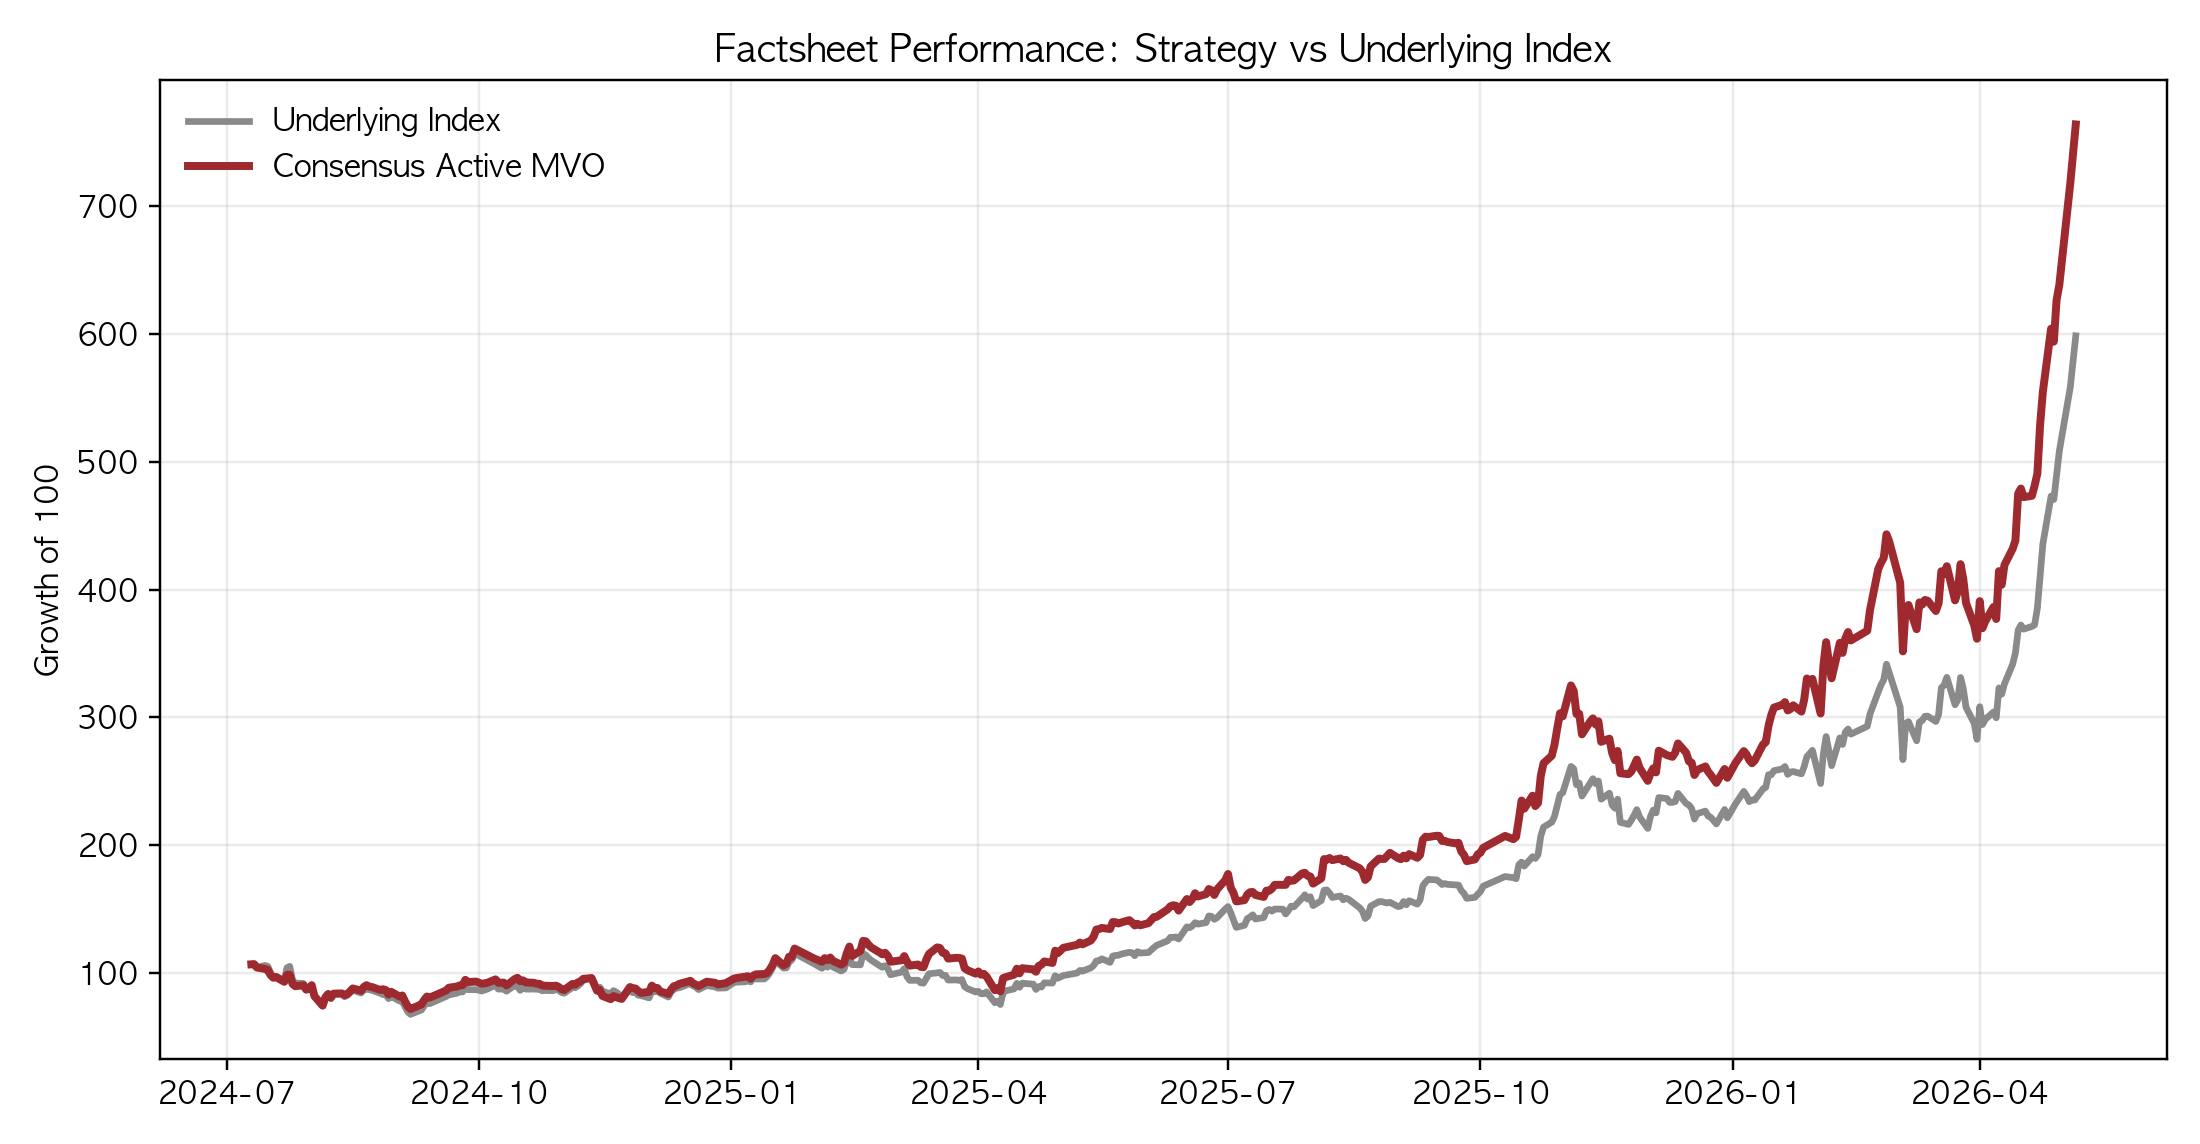

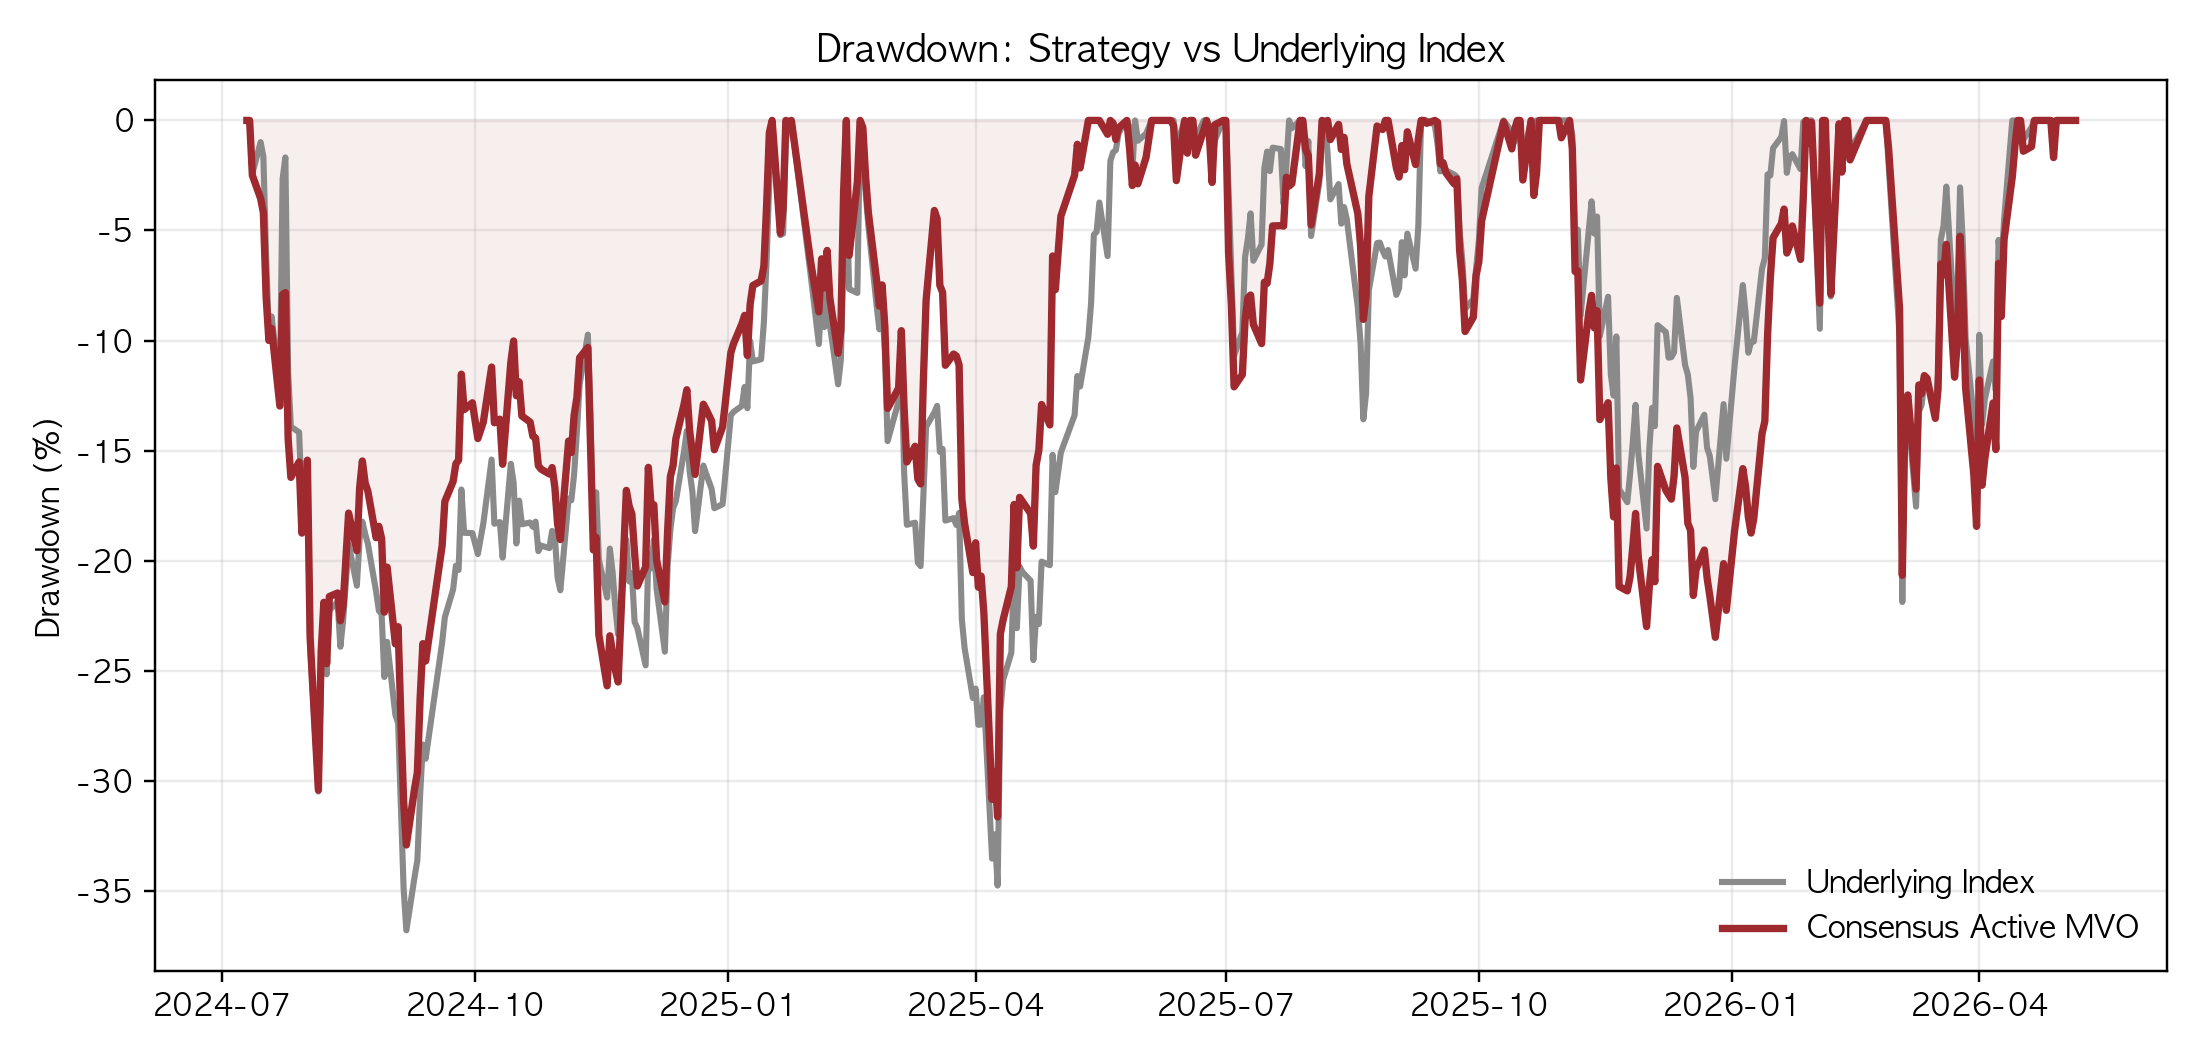

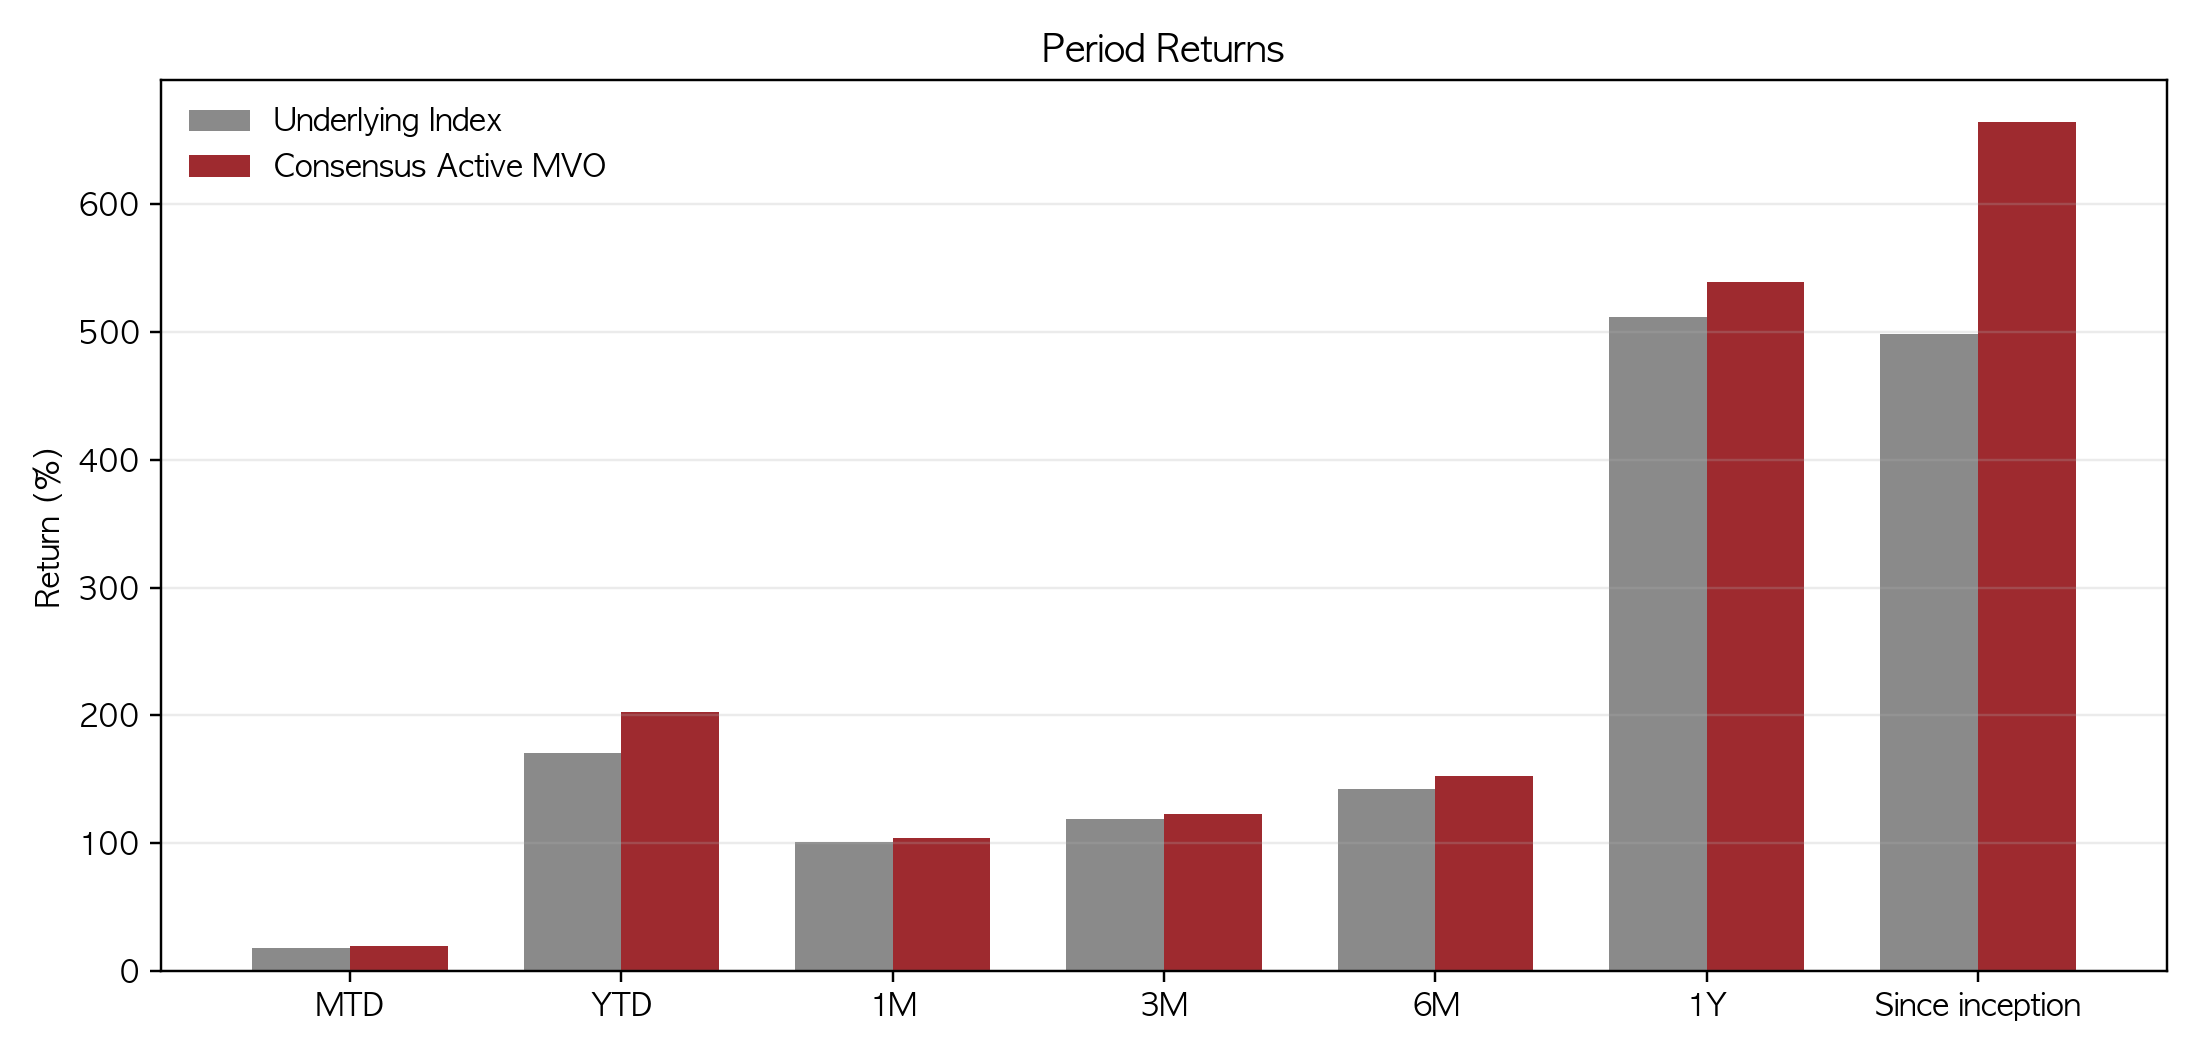

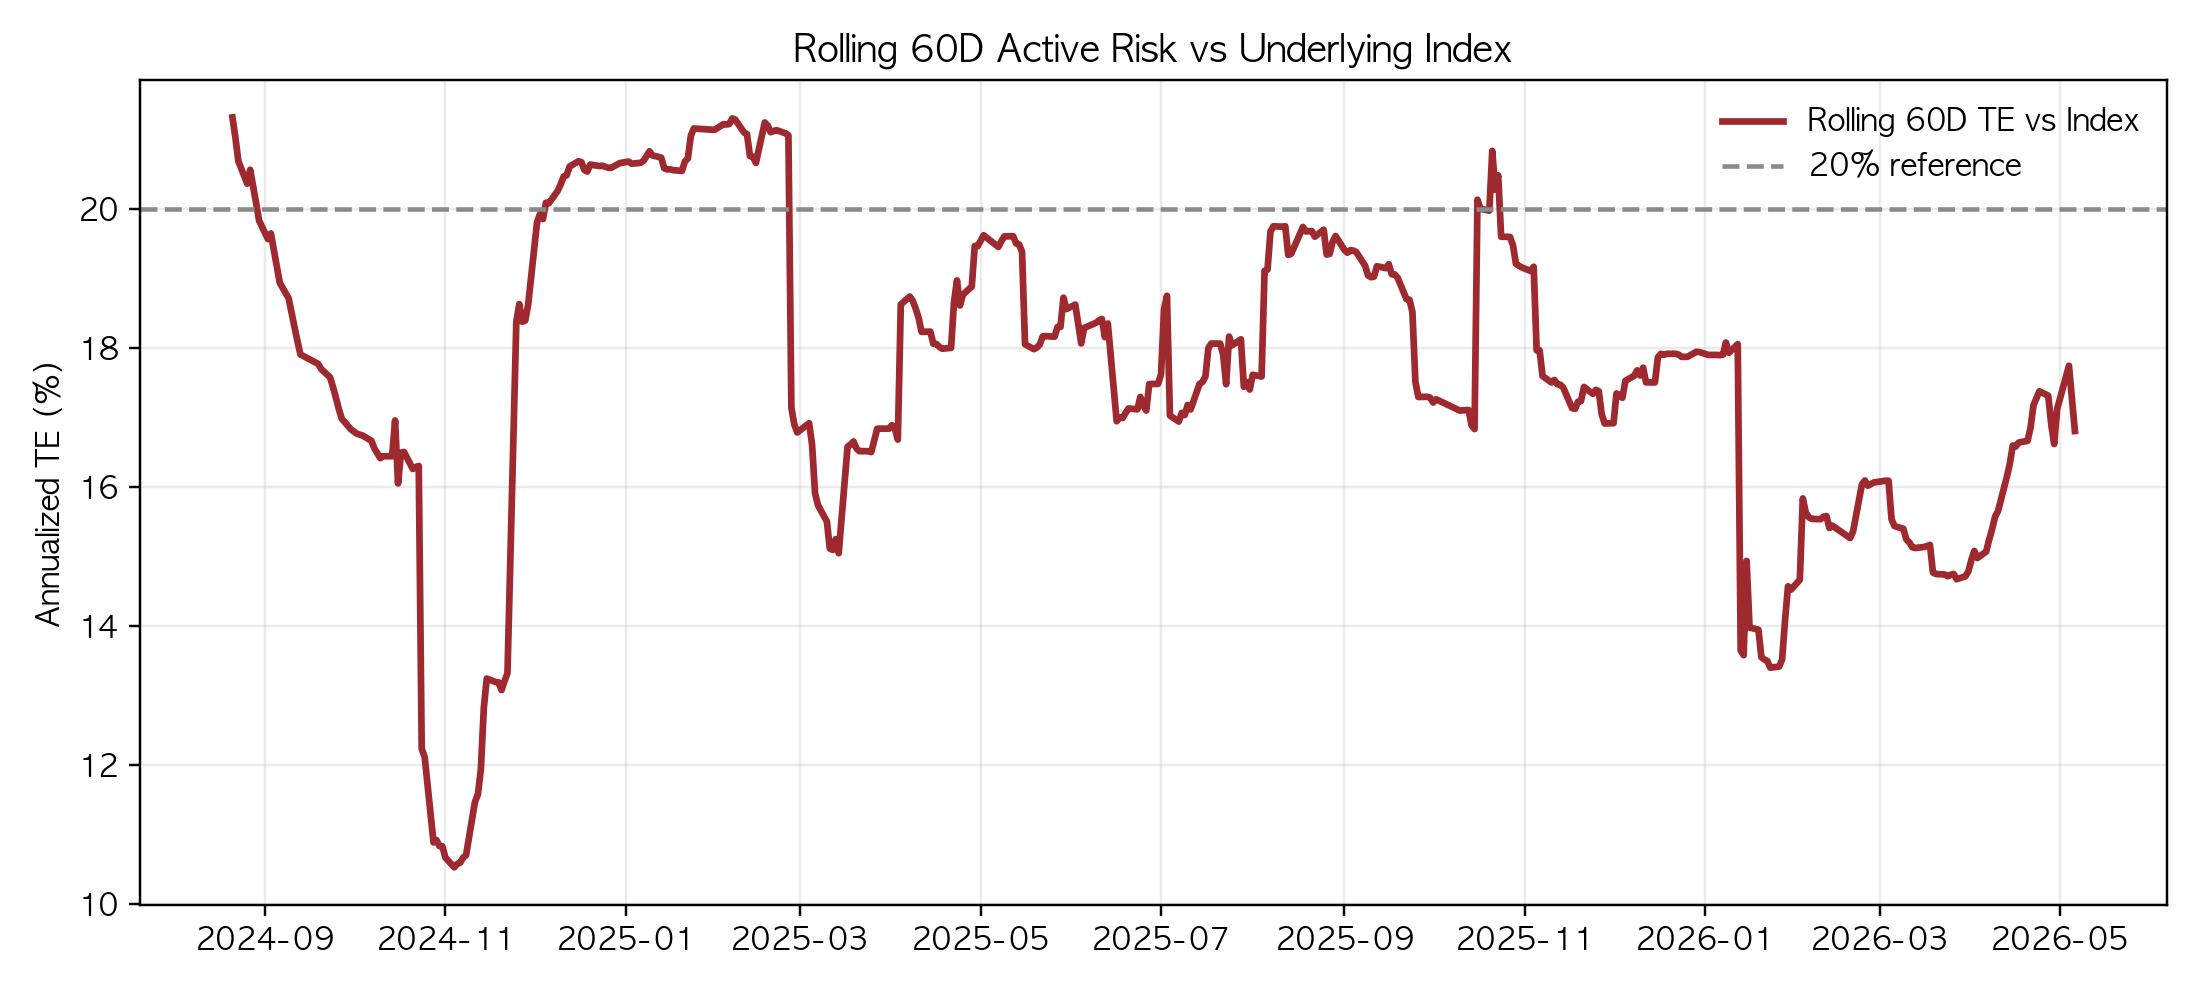

In [8]:
from factsheet_diagnostics import run_factsheet_diagnostics

run_factsheet_diagnostics()

factsheet_key_info = read_csv('factsheet_key_info.csv')
factsheet_summary = read_csv('factsheet_performance_summary_pretty.csv')
factsheet_period = read_csv('factsheet_period_returns_pretty.csv')
factsheet_calendar = read_csv('factsheet_calendar_year_returns_pretty.csv')
factsheet_holdings = read_csv('factsheet_top10_holdings_pretty.csv')

print('Factsheet key info')
display(factsheet_key_info)

print('Performance summary: strategy vs underlying index')
display(factsheet_summary)

print('Period returns')
display(factsheet_period)

print('Calendar year returns')
display(factsheet_calendar)

print('Top 10 holdings')
display(factsheet_holdings)

for img in [
    'chart_factsheet_cumulative_vs_index.png',
    'chart_factsheet_drawdown_vs_index.png',
    'chart_factsheet_period_returns_vs_index.png',
    'chart_factsheet_rolling_te_vs_index.png',
]:
    display(Image(filename=str(OUTPUT / img)))


## Appendix. 최종 전략 Metrics 산출
<!-- final_metrics_appendix -->

아래 지표는 최종 전략 `consensus_active_mvo_te20_ra1_min1` 기준입니다. 수익률은 비용 반영 후 일별 수익률을 사용했고, benchmark는 KRX PDF 비중 복제 포트폴리오입니다.

| 지표 | 최종값 | 의미 | 실무적 해석 |
|---|---:|---|---|
| Average Holding Periods | 21.2거래일 / 약 30.7일 | 연환산 one-way turnover의 역수로 본 평균 보유기간입니다. | 주간 리밸런싱이지만 모든 비중을 매주 갈아엎는 구조는 아니며, 평균적으로 약 21.2거래일마다 보유비중이 한 바퀴 도는 수준입니다. |
| Maximum Strategy Capacity | 3일 분할 x 10% ADV x 시계열 하위 10% 99.09억 원 | 리밸런싱 주문이 직전 20거래일 평균 거래대금의 일정 비율을 넘지 않는 운용규모 한도입니다. | 발표 기준 capacity는 3일 분할 체결, 하루 10% ADV 참여율, 시계열 하위 10% 기준 99.09억 원입니다. 1일 체결ㆍ5% ADVㆍ시계열 하위 5% 기준 12.33억 원과 3일 분할ㆍ5% ADVㆍ시계열 하위 5% 기준 36.98억 원은 더 보수적인 참고값입니다. 3일 분할ㆍ10% ADVㆍ시계열 하위 5% 기준은 73.97억 원입니다. |
| Turnover and Costs | 리밸런싱 평균 one-way 21.71%, 매매비용 -6.14%p, 총보수ㆍ비용 -0.80%p | Turnover는 리밸런싱 때 목표비중으로 이동하기 위해 사고파는 비중 변화입니다. 비용은 매매비용과 펀드 총보수ㆍ비용을 분리해 반영했습니다. | 평균 리밸런싱 one-way turnover는 21.71%이고, 최대값은 약 30%로 turnover limit 근처입니다. 비용 반영 누적수익률은 비용 미반영 대비 -54.97%p 낮아집니다. |
| Sharpe Ratio | 3.937 | 성과표의 Sharpe는 CAGR을 연환산 변동성으로 나눈 값입니다. | 최종 전략은 누적수익률 664.06%, 연환산 변동성 55.78% 기준 Sharpe 3.94입니다. 단, 표본이 짧으므로 PSR/DSR과 함께 봅니다. |
| Probabilistic Sharpe Ratio | PSR(SR*>0) 99.92%, PSR(SR*>1) 96.55%, PSR(SR*>2) 68.62% | 관측된 표본 Sharpe가 특정 기준 Sharpe를 초과할 확률을 왜도ㆍ첨도를 반영해 계산한 값입니다. | 표본 연율 Sharpe 2.36 기준, 장기 Sharpe가 1을 넘을 가능성은 96.55%로 추정됩니다. PSR은 미래 보장이 아니라 짧은 표본의 Sharpe 신뢰도 점검입니다. |
| Deflated Sharpe Ratio | 91.65% (trial count 15) | 여러 전략 후보를 테스트했을 때 우연히 높아진 Sharpe를 할인한 확률입니다. | 현재 발표에 남긴 후보/민감도 조합 15개를 고려해 기대 최대 Sharpe 기준을 1.33로 높이면 DSR은 91.65%입니다. 여러 후보 중 고른 효과를 반영해도 Sharpe가 완전히 우연이라고 보기는 어렵지만, trial count 정의에 따라 값이 달라지므로 scenario table과 함께 해석합니다. |
| Drawdown | -32.92% (2024-09-06) | 누적 wealth가 이전 고점 대비 얼마나 하락했는지의 최대값입니다. | 최대낙폭은 -32.92%로, 수익률은 높지만 테마 ETF 특유의 하락위험은 큽니다. 따라서 이 전략은 저위험 전략이 아니라 active overlay 전략으로 해석해야 합니다. |
| Tracking Error | 17.90% | 전략 일별 수익률에서 PDF 벤치마크 일별 수익률을 뺀 active return의 표준편차를 연율화한 값입니다. | 실현 TE는 17.90%, IR은 0.843, PDF 상관계수는 0.947입니다. TE는 패시브 복제 오차가 아니라 초과성과를 얻기 위해 사용한 active risk 예산입니다. |
| Herfindahl-Hirschman Index | latest HHI 0.261, effective holdings 3.84 | 종목별 비중 제곱합입니다. 1/HHI는 실질적으로 몇 종목에 분산된 것처럼 보이는지 보여줍니다. | 최신 전략 HHI는 0.261, PDF HHI는 0.147입니다. 전략의 최신 effective holdings는 3.84개로 PDF 6.82개보다 낮아, 초과성과와 함께 집중위험이 커졌습니다. |

### 지표별 핵심 해석

- **Average Holding Periods**: turnover가 높을수록 평균 보유기간은 짧아집니다. 최종 전략은 주간 리밸런싱이므로 월간 전략보다 빠르게 컨센서스 변화를 반영하지만, 비용과 capacity를 반드시 같이 봐야 합니다.
- **Maximum Strategy Capacity**: 성과가 좋아도 거래대금이 작은 종목을 크게 사고팔아야 하면 실제 운용규모는 제한됩니다. 본문 기준은 3일 분할 체결, 하루 10% ADV 참여율, 시계열 하위 10% capacity이고, 1일 체결 또는 5% ADV 기준은 더 보수적인 참고 시나리오입니다.
- **Turnover and Costs**: turnover는 신호를 얼마나 자주 비중으로 옮기는지 보여주고, 비용은 그 대가입니다. 최종 성과는 매매비용과 펀드 총보수ㆍ비용을 반영한 값으로 설명해야 합니다.
- **Sharpe / PSR / DSR**: Sharpe는 위험 대비 성과, PSR은 Sharpe의 표본 신뢰도, DSR은 여러 후보를 테스트한 효과를 감안한 보수적 Sharpe 검증입니다.
- **Drawdown**: 최종 전략은 초과성과가 있지만 MDD가 작지 않습니다. 저위험 절대수익 전략이 아니라 테마 ETF 위에서 active risk를 쓰는 전략입니다.
- **Tracking Error**: 여기서 TE는 공식 ETF 추적오차가 아니라 PDF benchmark 대비 active return의 변동성입니다. active 전략에서는 TE 자체보다 IR과 함께 해석합니다.
- **HHI**: HHI가 높아질수록 특정 종목에 집중된 포트폴리오입니다. 최종 전략은 PDF보다 effective holdings가 낮아졌으므로 초과성과와 함께 집중위험도 커졌습니다.

### Deflated Sharpe Ratio의 조합 수 기준

DSR에서 가장 중요한 선택은 `trial count`, 즉 몇 개의 전략 후보를 비교했다고 볼 것인지입니다. 이 숫자는 정답이 하나로 정해져 있다기보다, 연구자가 실제로 어떤 후보군 안에서 최종 전략을 골랐는지 투명하게 정해야 합니다.

이번 프로젝트에서는 다음 원칙을 사용했습니다.

```text
1. Resampling / Monte Carlo 경로는 trial로 세지 않는다.
   이미 선택된 전략의 경로 안정성 검증이지, 새로운 전략 후보가 아니기 때문입니다.

2. 개별 종목이나 개별 날짜의 IC 관측치도 trial로 세지 않는다.
   이들은 전략 후보가 아니라 신호 검증 단위입니다.

3. 실제로 최종 전략 선택에 영향을 줄 수 있었던 비중화 방식과 운용 파라미터 조합을 trial로 본다.
   예: 단순 점수 틸트, 공격형 점수 틸트, MVO, TE budget, max weight, 비용, 리밸런싱, factor weight 설정.
```

본문 기준 DSR은 **reported_spec_rows_conservative**를 사용했습니다. 이는 MVO 적용 전 2개 후보와 현재 발표/README에 남긴 robustness 설정 13개를 모두 포함한 **15개 조합**입니다. 같은 최종 경로가 여러 sensitivity 항목에 중복 등장하더라도 모두 세기 때문에 다소 보수적인 기준입니다.

여기서 중요한 구분은, resampling이나 Monte Carlo에서 만든 2,000개 가상 경로는 DSR의 trial count에 넣지 않는다는 점입니다. 그 경로들은 이미 선택한 최종 전략의 수익률을 흔들어 보는 안정성 검증이지, 새로 비교한 전략 후보가 아니기 때문입니다. DSR의 trial은 '최종 전략을 고르기 전에 실제로 비교할 수 있었던 전략 설계 조합'입니다.

| scenario | trial count | DSR | 표본 Sharpe | 기대 최대 Sharpe | 기준 설명 |
|---|---:|---:|---:|---:|---|
| core_candidate_set | 3 | 98.93% | 2.36 | 0.64 | MVO 적용 전 단순 점수 틸트, MVO 적용 전 공격형 점수 틸트, 최종 Consensus Active MVO의 3개 핵심 후보만 trial로 간주 |
| unique_return_paths_current | 10 | 94.27% | 2.36 | 1.18 | MVO 적용 전 2개 후보와, 최종 robustness 표에서 성과 경로가 실제로 다른 8개 MVO 경로를 합산 |
| reported_spec_rows_conservative | 15 | 91.65% | 2.36 | 1.33 | MVO 적용 전 2개 후보와, 발표/README에 남긴 robustness 설정 13개 행을 모두 trial로 간주. 동일 경로 중복도 포함하므로 보수적 |
| broad_stress_legacy | 26 | 87.27% | 2.36 | 1.51 | 이전 실험 과정에서 검토했던 더 넓은 후보 수를 stress trial count로 사용. 현재 본문 전략 선택 기준은 아니며 민감도 점검용 |

해석은 다음과 같습니다.

- trial count를 3개 핵심 후보만으로 보면 DSR은 더 높게 나옵니다.
- 중복 경로를 제거한 현재 후보군 기준은 10개입니다.
- 본문에서는 더 보수적으로 15개를 사용했습니다.
- 26개 stress count를 적용해도 DSR은 80%대 후반으로 유지됩니다.

따라서 DSR은 'Sharpe가 여러 조합을 돌리다 우연히 높아진 것일 수 있다'는 비판을 완전히 없애는 도구는 아니지만, 현재 공개한 후보군 기준에서는 최종 Sharpe가 단순 우연이라고 보기 어렵다는 보조 근거로 사용할 수 있습니다.

### 추가 산출 파일

| 파일 | 내용 |
|---|---|
| `output/final_metrics_summary.csv` | 지표별 원자료 요약 |
| `output/final_metrics_summary_pretty.csv` | 발표용 지표 설명 표 |
| `output/final_metrics_detail.csv` | turnover, DSR, HHI 세부 수치 |
| `output/deflated_sharpe_ratio_scenarios.csv` | DSR trial count 시나리오별 원자료 |
| `output/deflated_sharpe_ratio_scenarios_pretty.csv` | DSR trial count 시나리오별 발표용 표 |
| `output/chart_deflated_sharpe_ratio_scenarios.png` | trial count 기준별 DSR 민감도 그래프 |
| `output/final_hhi_timeseries.csv` | 날짜별 전략/PDF HHI 및 effective holdings |
| `output/chart_final_hhi_timeseries.png` | 전략/PDF HHI 변화 |
| `output/chart_final_effective_holdings.png` | 전략/PDF effective holdings 변화 |

### DSR 그래프 해석

DSR 그래프는 `trial count`, 즉 몇 개의 전략 후보를 비교했다고 볼 것인지에 따라 Deflated Sharpe Ratio가 어떻게 달라지는지 보여줍니다. x축은 trial count 기준별 시나리오이고, y축은 DSR입니다. 와인색 막대는 본문에서 사용한 기준입니다.

읽는 방법은 다음과 같습니다.

- trial count가 커질수록 DSR은 낮아집니다. 여러 조합을 많이 시도할수록 우연히 높은 Sharpe가 나올 가능성이 커지기 때문입니다.
- 핵심 후보 3개만 보면 DSR은 98.93%로 매우 높습니다.
- 본문 기준인 15개 조합에서는 91.65%입니다.
- 더 보수적인 26개 stress 기준에서도 87.27%입니다.
- 50% 기준선보다 충분히 높기 때문에, 현재 공개한 후보군 안에서는 최종 Sharpe가 단순한 후보 선택 운으로만 나온 것이라고 보기는 어렵습니다.

다만 이 그래프도 미래 성과를 보장하는 증거는 아닙니다. 정확한 발표 표현은 **'과최적화 가능성을 낮춰 보는 보조 진단'**입니다.

![DSR trial count 민감도](output/chart_deflated_sharpe_ratio_scenarios.png)

### HHI 그래프 해석

HHI는 종목별 비중의 제곱합입니다.

```text
HHI = sum_i weight_i^2
Effective holdings = 1 / HHI
```

즉 HHI가 높을수록 특정 종목에 비중이 몰려 있고, `1 / HHI`로 계산한 effective holdings는 실질적으로 몇 종목에 분산된 것처럼 보이는지를 나타냅니다.

첫 번째 HHI 그래프에서는 최종 전략의 HHI가 PDF보다 대체로 높습니다. 이는 전략이 PDF를 그대로 복제한 것이 아니라, consensus score가 좋은 종목에 더 집중해서 초과성과를 만들었다는 뜻입니다.

최신 시점 기준으로 전략 HHI는 0.261, PDF HHI는 0.147입니다. 이를 effective holdings로 바꾸면 전략은 약 3.84개, PDF는 약 6.82개입니다.

따라서 해석은 양면적입니다.

- 긍정적 해석: 점수가 높은 종목에 집중했기 때문에 PDF 대비 초과성과가 커졌습니다.
- 리스크 해석: 실질 분산 종목 수가 줄어들었기 때문에 특정 종목의 급락이나 신호 오류에 더 민감해졌습니다.

발표에서는 **'초과성과는 공짜가 아니라, 더 높은 active concentration을 감수한 결과'**라고 설명하는 것이 안전합니다.

![최종 전략 HHI](output/chart_final_hhi_timeseries.png)

두 번째 effective holdings 그래프는 같은 내용을 더 직관적으로 보여줍니다. 선이 낮아질수록 포트폴리오가 소수 종목에 집중된다는 의미입니다. 최종 전략의 effective holdings가 PDF보다 낮게 유지되는 구간은, MVO가 컨센서스 점수가 높은 종목으로 비중을 몰아준 구간으로 해석하면 됩니다.

![최종 전략 effective holdings](output/chart_final_effective_holdings.png)


## Appendix. Probabilistic Sharpe Ratio (PSR)


이 내용은 본문 성과 판단의 핵심 근거가 아니라, **Sharpe ratio가 짧은 표본에서 우연히 높게 보였을 가능성을 점검하는 참고 진단**입니다. 발표 본문에서는 TE, IR, 비용, turnover, capacity를 중심으로 설명하고, PSR은 질문이 들어왔을 때 부록으로만 사용합니다.

Sharpe Ratio가 높게 나왔더라도, 표본이 짧거나 수익률 분포가 비정규적이면 그 Sharpe가 우연히 높게 보였을 수 있습니다. **Probabilistic Sharpe Ratio, PSR**은 관측된 표본 Sharpe가 특정 기준 Sharpe Ratio $SR^*$를 초과할 확률을 계산하는 지표입니다.

Lopez de Prado(2013)의 표현을 따르면, 표본 Sharpe Ratio를 $\widehat{SR}$, 표본 수를 $T$, 수익률의 왜도를 $\hat{\gamma}_3$, 비초과 첨도를 $\hat{\gamma}_4$라고 할 때 PSR은 다음처럼 쓸 수 있습니다.

$$
PSR(SR^*) =
\Phi\left(
\frac{
(\widehat{SR} - SR^*)\sqrt{T-1}
}{
\sqrt{
1 - \hat{\gamma}_3 \widehat{SR}
+ \frac{\hat{\gamma}_4 - 1}{4}\widehat{SR}^2
}
}
\right)
$$

여기서 $\Phi(\cdot)$는 표준정규분포의 누적분포함수입니다.

해석은 다음입니다.

- $\widehat{SR}$가 클수록 PSR은 커집니다.
- 표본 수 $T$가 많을수록 추정 신뢰도가 높아져 PSR이 커질 수 있습니다.
- 왜도와 첨도가 크면 단순 정규성 가정보다 더 보수적으로 평가됩니다.

여기서 왜도와 첨도는 별도 외부 데이터에서 가져온 값이 아니라, **최종 전략의 비용 반영 일별 수익률 441개**에서 직접 계산했습니다.

```text
skewness = daily strategy return의 왜도 = 0.251
excess kurtosis = daily strategy return의 초과첨도 = 1.389
raw kurtosis = excess kurtosis + 3 = 4.389
```

`pandas`의 `kurtosis()`는 정규분포를 0으로 보는 **초과첨도(excess kurtosis)**를 반환합니다. 그런데 PSR 공식에는 raw kurtosis가 들어가므로 코드에서는 `r.kurtosis() + 3.0`을 사용했습니다. raw kurtosis가 3보다 크다는 것은 정규분포보다 꼬리가 두꺼운 수익률 분포였다는 뜻이고, 그래서 PSR은 단순 정규 Sharpe 평가보다 더 보수적으로 해석합니다.

주의할 점이 있습니다. 기존 성과표의 Sharpe `3.94`는 CAGR을 연환산 변동성으로 나눈 값입니다. 반면 PSR 공식의 표본 Sharpe는 일별 수익률의 평균을 표준편차로 나눈 뒤 연율화한 값입니다. 그래서 PSR 계산에 사용한 최종 전략의 표본 연율 Sharpe는 **2.36**입니다. 두 값이 다른 것은 오류가 아니라 Sharpe 정의가 다르기 때문입니다.

최종 전략의 PSR 주요 값은 다음입니다.

| 기준 연환산 Sharpe $SR^*$ | 최종 전략 PSR |
|---:|---:|
| 0.0 | 99.92% |
| 1.0 | 96.55% |
| 2.0 | 68.62% |
| 3.0 | 19.81% |
| 4.0 | 1.45% |

따라서 “진짜 Sharpe가 0보다 클 가능성”은 매우 높게 나오지만, “진짜 Sharpe가 3 이상일 가능성”은 낮습니다. 이 해석이 중요합니다. PSR은 높은 성과를 무조건 확정하는 도구가 아니라, 짧은 표본과 비정규 분포를 감안해 Sharpe의 신뢰도를 더 보수적으로 보는 도구입니다.

또한 $SR^*=0$일 때의 PSR은 “손실을 보지 않을 확률”이 아닙니다. 더 정확히는 **전략의 장기 Sharpe가 0보다 클 가능성**, 즉 평균 수익률이 변동성 대비 양수라고 볼 수 있는 정도입니다.

여기서 그래프를 볼 때도 두 가지를 구분해야 합니다.

- `PSR 곡선`: 기준 Sharpe $SR^*$를 바꿨을 때, 그 기준을 넘을 확률이 어떻게 변하는지 보는 **누적확률 그래프**입니다. 그래서 종 모양이 아니라 기준 Sharpe가 높아질수록 내려가는 곡선입니다.
- `Sharpe 분포 근사`: 관측된 Sharpe의 추정 불확실성을 정규분포 형태로 시각화한 그림입니다. 발표에서 직관적으로 설명하기에는 이 그래프가 더 좋습니다.

중요한 점은, 정규분포형 그래프가 **여러 번 백테스트해서 얻은 Sharpe들의 실제 히스토그램이 아니라는 것**입니다. 이 그래프는 최종 전략의 일별 수익률 441개에서 표본 Sharpe를 하나 계산한 뒤, 표본 수, 왜도, 첨도를 이용해 Sharpe 추정치의 표준오차를 근사해서 그린 분포입니다.

계산 흐름은 다음입니다.

```text
1. 비용 반영 일별 수익률 441개를 사용한다.
2. 일별 평균수익률 / 일별 표준편차로 daily Sharpe를 계산한다.
3. daily Sharpe에 sqrt(252)를 곱해 표본 연율 Sharpe 2.36를 만든다.
4. 일별 수익률의 왜도와 첨도를 계산한다.
5. PSR 공식에서 implied standard error of Sharpe를 계산한다.
6. N(sample Sharpe, Sharpe standard error^2) 형태의 정규근사 분포를 그린다.
```

따라서 그래프의 x축에 있는 여러 Sharpe 값은 실제로 여러 번 관측된 Sharpe가 아니라, “진짜 Sharpe가 이 값일 가능성을 어떻게 볼 것인가”를 보여주기 위해 그린 후보 값입니다. 와인색 실선은 표본 Sharpe 2.36 위치이고, 점선으로 표시된 $SR^*=0,1,2,3$은 비교 기준 Sharpe입니다. 곡선 아래에서 각 기준 Sharpe 오른쪽 면적이 해당 기준을 넘을 PSR입니다.

정규근사 분포에서는 평균, 중앙값, 최빈값이 같은 위치에 놓입니다. 다만 발표 그래프에서는 시각적 혼동을 줄이기 위해 이 설명 문구를 그래프 안에는 넣지 않았습니다.

![PSR 해석용 Sharpe 분포 근사](output/chart_probabilistic_sharpe_ratio_distribution.png)

![최종 전략 PSR 주요 기준값](output/chart_probabilistic_sharpe_ratio_key_thresholds.png)

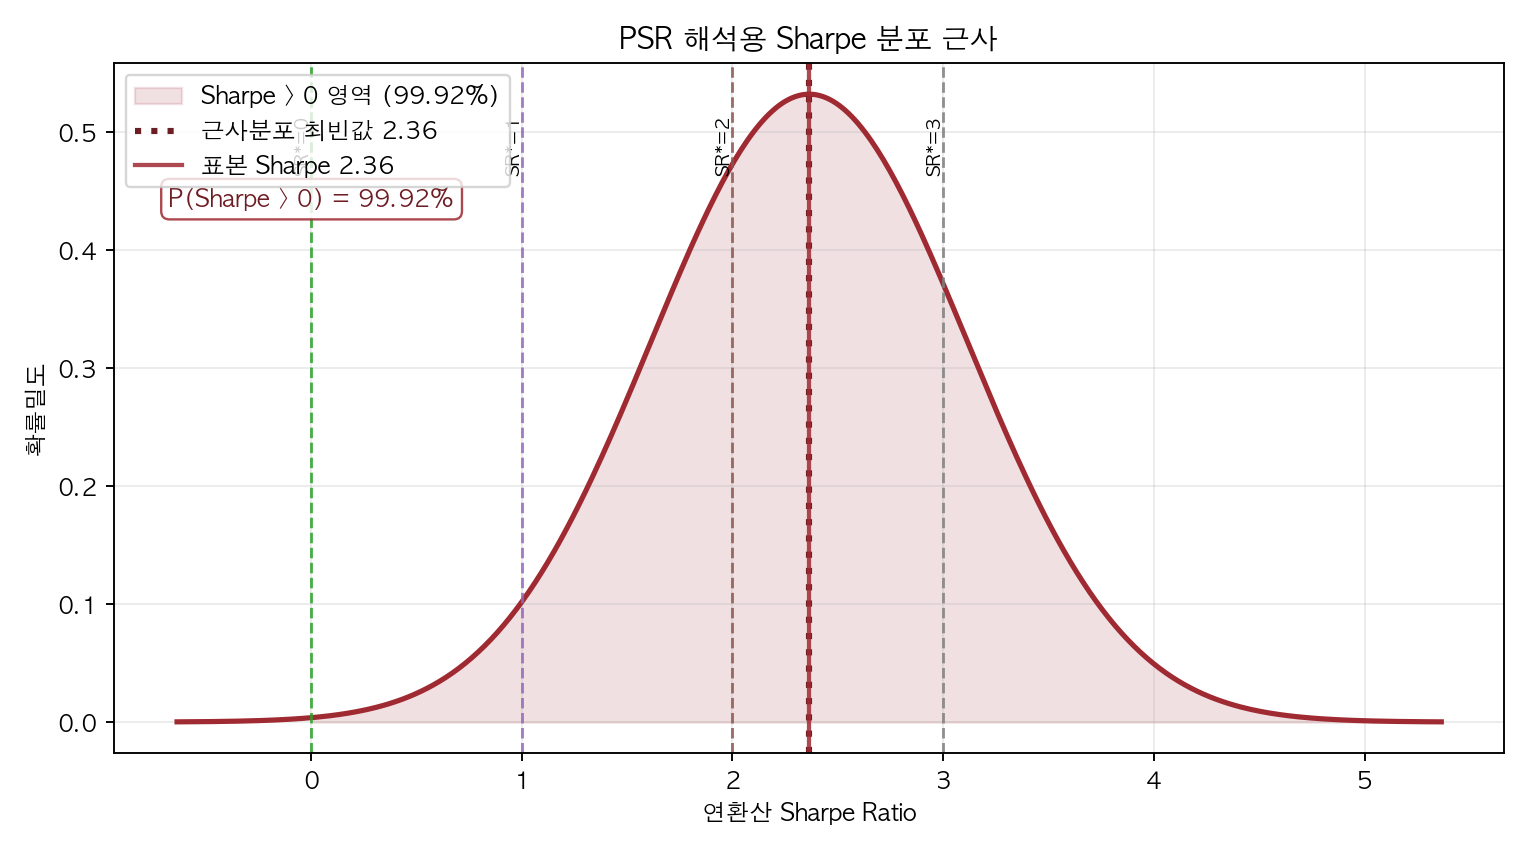

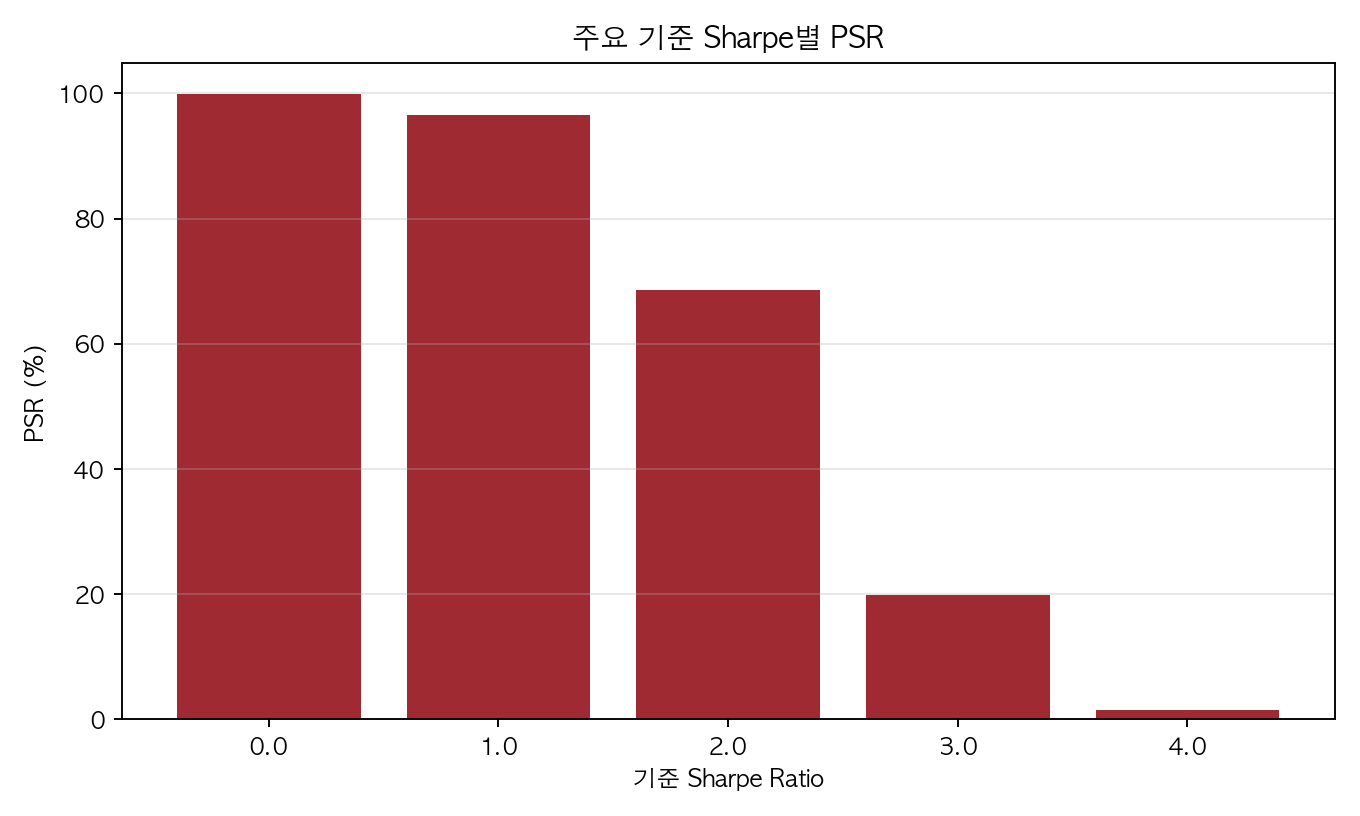

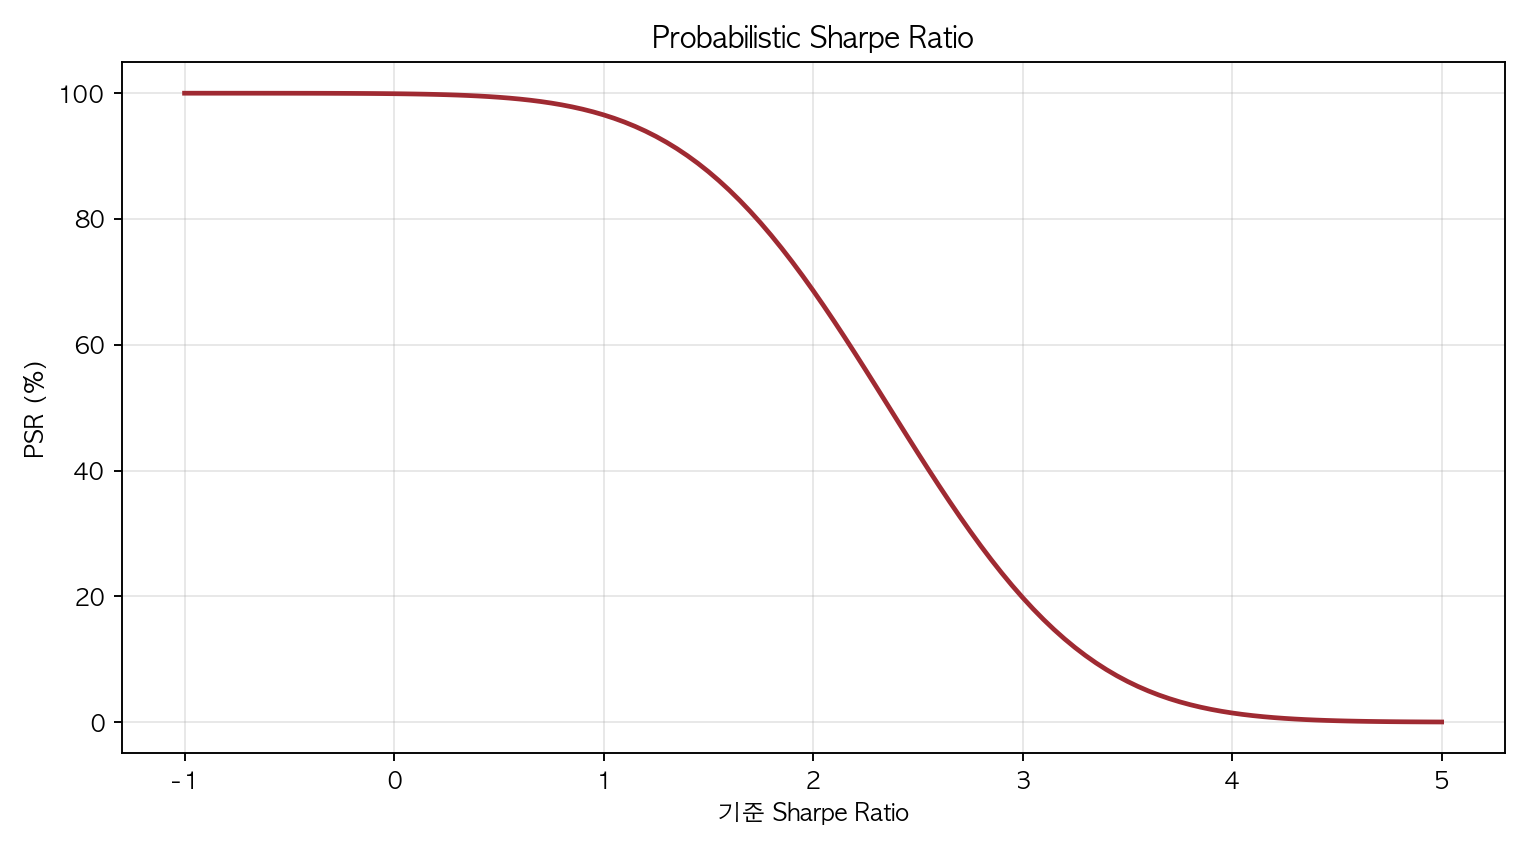

In [9]:
for img in [
    'chart_probabilistic_sharpe_ratio_distribution.png',
    'chart_probabilistic_sharpe_ratio_key_thresholds.png',
    'chart_probabilistic_sharpe_ratio.png',
]:
    path = OUTPUT / img
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f'missing: {path}')


## Appendix. 분배금 추정: 실제 KODEX 분배금과 PDF 복제 포트폴리오 비교

KODEX 사이트에서 받은 실제 분배금 현황과, KRX PDF 비중으로 복제한 포트폴리오의 보유종목 배당수익률을 이용해 추정한 분배금을 비교했습니다.

추정식은 다음과 같습니다.

$$
\text{Estimated Distribution Rate}_t
= \sum_i w^{PDF}_{i,t} \times \text{Dividend Yield}_{i,t}
$$

$$
\text{Estimated Distribution Amount}_t
= \text{ETF NAV}_t \times \text{Estimated Distribution Rate}_t
$$

주의할 점은, 이 값은 **정확한 ETF 분배금 예측치가 아니라 보유종목 배당수익률 기반 근사치**라는 점입니다. 실제 ETF 분배금은 종목별 배당락일, 배당 지급일, ETF의 실제 보유수량, 현금 잔고, 비용, 과표기준가, 운용사의 분배정책을 거쳐 결정됩니다.

| 지급기준일 | 실제 분배금 | 실제 분배율 | 복제 추정 분배금 | 복제 추정 분배율 | 추정/실제 | 해석 |
|---|---:|---:|---:|---:|---:|---|
| 2025-04-30 | 119.0원 | 1.231% | 116.5원 | 1.171% | 0.98x | 실제와 매우 유사 |
| 2026-04-30 | 39.0원 | 0.080% | 165.5원 | 0.314% | 4.24x | 배당수익률 기반 추정이 실제보다 큼 |

2025년은 추정치가 실제 분배금과 거의 같습니다. 반면 2026년은 추정치가 실제보다 크게 높습니다. 가장 큰 이유는 2026년 기준일에 `DPS(보통주, 현금)`과 `현금배당액(전체)`이 아직 비어 있고, `dividend_yield_pct`만 존재하기 때문입니다. 따라서 2026년 차이는 복제 포트폴리오의 비중 문제가 아니라, 현재 파일만으로 ETF가 실제로 받은 배당 현금흐름을 완전히 재현하기 어렵다는 한계로 해석하는 것이 맞습니다.

![실제 분배금 vs PDF 복제 추정 분배금](output/chart_distribution_actual_vs_estimated.png)

![종목별 추정 분배금 기여도](output/chart_distribution_estimate_by_stock.png)




In [ ]:
import pandas as pd
from IPython.display import display

resampling_summary = read_csv('resampling_monte_carlo_summary_pretty.csv')
display(resampling_summary)


### 결과 해석

요약하면 두 검증 모두에서 초과성과가 양수로 유지되는 비율이 80%대 후반으로 나왔습니다.

- Block bootstrap: 초과성과 양수 비율 약 88%, IR 양수 비율 약 89%
- Monte Carlo: 초과성과 양수 비율 약 86%, IR 양수 비율 약 88%
- 두 방식 모두 TE 20% 이하 비율이 96% 이상입니다.

따라서 최종 전략의 결과가 특정 날짜 순서 하나에만 전적으로 의존한다고 보기는 어렵습니다. 다만 5% 분위수에서는 초과성과이 음수로 나올 수 있으므로, 이 결과는 “항상 이긴다”는 의미가 아니라 **여러 대체 경로에서도 양의 active return이 유지될 가능성이 비교적 높았다**는 의미로 해석해야 합니다.

아래 첫 번째 그래프는 PDF 대비 초과 누적수익률의 분포입니다. 검은 점선은 실제 historical path의 초과성과입니다.

![Resampling/Monte Carlo 초과성과 분포](output/chart_resampling_mc_excess_return_distribution.png)

두 번째 그래프는 IR 분포입니다. IR은 `평균 active return / tracking error`로, 사용한 active risk 대비 초과성과가 얼마나 효율적이었는지를 보는 지표입니다.

![Resampling/Monte Carlo IR 분포](output/chart_resampling_mc_ir_distribution.png)


## Appendix. Resampling / Monte Carlo 검증
<!-- resampling_monte_carlo_appendix -->

선택한 최종 전략이 특정 historical path 하나에만 우연히 맞은 것인지 확인하기 위해 두 가지 추가 검증을 수행했습니다. 핵심 질문은 다음입니다.

```text
실제 2024-07~2026-05의 날짜 순서가 조금 달랐거나,
비슷한 통계적 성격을 가진 다른 시장 경로가 나타났어도
전략이 PDF 벤치마크 대비 초과성과를 낼 가능성이 있었는가?
```

이 검증은 전략을 새로 고르거나 파라미터를 다시 맞추는 과정이 아닙니다. 이미 확정한 최종 전략의 비용 반영 일별 수익률과 PDF 벤치마크 일별 수익률을 가지고, 경로만 여러 방식으로 다시 만들어 보는 appendix용 안정성 점검입니다.

### ResamplingㆍMonte Carlo와 DSR은 무엇이 다른가

세 검증은 이름이 모두 통계적으로 들리지만, 보는 질문이 다릅니다.

| 구분 | 무엇을 새로 만드나 | 바뀌는 대상 | 답하려는 질문 | 새 전략 후보를 고르나 |
|---|---|---|---|---|
| Block bootstrap resampling | 실제 과거 수익률 block을 다시 배열한 경로 | 날짜 순서 | 과거 수익률 조각의 순서가 달라도 성과가 유지되는가 | 아니오 |
| Monte Carlo synthetic path | 평균ㆍ공분산이 비슷한 가상 수익률 경로 | 수익률 충격 자체 | 비슷하지만 실제와 다른 시장 경로에서도 성과가 유지되는가 | 아니오 |
| DSR | 새로운 경로를 만들지 않음 | 비교한 전략 후보 수, 즉 trial count | 여러 후보를 돌리다 우연히 Sharpe가 높아진 것 아닌가 | 아니오, 이미 고른 전략을 보정 평가 |

즉 resampling과 Monte Carlo는 **최종 전략의 수익률 경로를 흔들어 보는 테스트**이고, DSR은 **최종 전략을 고르기 전 여러 후보를 봤다는 선택 편향을 Sharpe에서 할인하는 테스트**입니다.

간단한 비유로 보면 다음과 같습니다.

```text
Resampling / Monte Carlo:
  이미 고른 자동차를 여러 도로 조건에서 다시 달려 보게 하는 테스트

DSR:
  여러 자동차를 시험 주행한 뒤 가장 빨랐던 한 대를 골랐으니,
  그 기록이 운 좋게 나온 최고 기록일 가능성을 할인하는 테스트
```

### 1. Block bootstrap resampling

Block bootstrap은 실제 과거 수익률 조각을 잘라서 다시 섞는 방식입니다. 하루 단위로 섞으면 주간 단위의 추세, 반등, 급락 같은 짧은 흐름이 깨질 수 있으므로 여기서는 5거래일, 즉 약 1주일 단위 block을 사용했습니다.

```text
실제 경로: [1주차] [2주차] [3주차] [4주차] ...
가상 경로: [3주차] [1주차] [1주차] [8주차] ...
```

복원추출이므로 같은 block이 여러 번 뽑힐 수도 있고, 어떤 block은 한 번도 뽑히지 않을 수도 있습니다. 중요한 점은 전략 수익률과 PDF 수익률을 같은 날짜 쌍으로 묶어 함께 뽑는다는 것입니다. 그래야 시장이 크게 오르는 날에는 전략과 PDF가 같이 움직였던 관계가 깨지지 않습니다.

예를 들어 실제 데이터에 다음처럼 5일짜리 block이 있다고 하겠습니다.

| block | 포함 내용 |
|---|---|
| A | 1주차의 PDF 수익률 5개와 전략 수익률 5개 |
| B | 2주차의 PDF 수익률 5개와 전략 수익률 5개 |
| C | 3주차의 PDF 수익률 5개와 전략 수익률 5개 |
| D | 4주차의 PDF 수익률 5개와 전략 수익률 5개 |

bootstrap 경로는 `C -> A -> A -> D`처럼 만들 수 있습니다. 여기서 A가 두 번 나오는 것은 복원추출이기 때문입니다. 이때 PDF만 따로 뽑고 전략만 따로 뽑지 않습니다. 날짜별 `PDF return, strategy return` 쌍을 같이 움직여야 두 수익률의 상관관계와 active return 구조가 유지됩니다.

- block 길이: 5거래일
- 시뮬레이션 경로 수: 2,000개
- 장점: 실제 관측된 수익률 조각만 사용하므로 가정이 적습니다.
- 한계: 과거에 없었던 완전히 새로운 위기나 국면은 만들지 못합니다.

### 2. Monte Carlo synthetic path

Monte Carlo는 실제 날짜 조각을 그대로 쓰는 대신, 수익률의 통계적 특성을 추정한 뒤 새로운 가상 경로를 생성하는 방식입니다. 여기서는 전략 수익률을 직접 생성하지 않고, PDF 벤치마크 수익률과 active return을 나누어 봅니다.

```text
active return = 최종 전략 수익률 - PDF 벤치마크 수익률
최종 전략 수익률 = PDF 벤치마크 수익률 + active return
```

이렇게 나눈 이유는 전략의 성과가 두 부분으로 구성되기 때문입니다. 하나는 ETF 테마 자체가 오르내리는 PDF 벤치마크 수익률이고, 다른 하나는 비중조정으로 PDF보다 더 벌거나 덜 번 active return입니다.

Monte Carlo에서는 PDF return과 active return의 평균, 변동성, 두 값의 공분산을 추정합니다. 이후 금융 수익률의 꼬리가 두꺼운 특성을 반영하기 위해 정규분포가 아니라 Student-t shock을 사용해 2,000개의 가상 경로를 만듭니다.

예를 들어 과거 데이터에서 다음 관계를 추정했다고 생각하면 됩니다.

```text
PDF return의 평균과 변동성
active return의 평균과 변동성
PDF return과 active return이 같이 움직이는 정도, 즉 공분산
```

그다음 매일 새로운 충격을 뽑아 `가상의 PDF return`과 `가상의 active return`을 만듭니다. 마지막에 둘을 더해서 가상의 전략 수익률을 만듭니다.

```text
synthetic strategy return
= synthetic PDF return + synthetic active return
```

따라서 Monte Carlo 경로는 과거 날짜 조각을 그대로 재배열한 것이 아니라, 과거와 평균ㆍ변동성ㆍ상관 구조가 비슷한 새 가상 경로입니다.

- Student-t 자유도: 5
- 시뮬레이션 경로 수: 2,000개
- 장점: block bootstrap보다 다양한 경로를 만들 수 있습니다.
- 한계: 평균ㆍ공분산ㆍ분포 가정이 들어가므로 결과가 모형 가정에 의존합니다.

### 두 경로 검증의 차이

| 방식 | 무엇을 다시 만드나 | 장점 | 한계 |
|---|---|---|---|
| Block bootstrap | 실제 5거래일 수익률 block의 순서 | 가정이 적고 실제 관측값 기반 | 과거에 없던 새 국면은 만들기 어려움 |
| Monte Carlo | 평균ㆍ공분산이 비슷한 가상 수익률 경로 | 더 다양한 경로 생성 가능 | 분포와 공분산 가정에 의존 |

반대로 DSR은 위 표의 두 방식처럼 2,000개의 수익률 경로를 새로 만드는 검증이 아닙니다. 예를 들어 발표 과정에서 `단순 점수 틸트`, `공격형 점수 틸트`, `MVO`, `TE budget 변경`, `max weight 변경` 등 총 15개 후보를 봤다면, 그중 가장 Sharpe가 높은 후보가 우연히 좋아 보였을 가능성이 있습니다. DSR은 이 15개 후보를 봤다는 사실을 반영해서 비교 기준 Sharpe를 더 높게 잡고, 최종 전략의 Sharpe가 그 기준을 넘을 가능성을 계산합니다.

그래서 발표에서는 다음처럼 구분하는 것이 가장 안전합니다.

```text
Resampling / Monte Carlo = 경로 안정성 검증
DSR = 후보 선택 편향과 과최적화 가능성 보정
```

### 설정

| 항목 | 설정 |
|---|---|
| 학습/관측 데이터 | 최종 전략 비용 반영 일별 수익률, PDF 벤치마크 일별 수익률 |
| 기간 | 2024-07-10 ~ 2026-05-06 |
| Block length | 5거래일 |
| Monte Carlo paths | 2,000개 |
| Benchmark | KRX PDF 비중 복제 포트폴리오 |
| 거래비용 | 최종 전략 수익률에 이미 반영 |

### 결과 요약

| 검증 방식             |   경로 수 | 초과 누적수익률 중앙값   | 초과 누적수익률 5%   | 초과 누적수익률 95%   | TE 중앙값   |   IR 중앙값 | 초과성과 양수 비율   | IR 양수 비율   | TE 20% 이하 비율   |
|:----------------------|----------:|:-------------------------|:---------------------|:----------------------|:------------|------------:|:---------------------|:---------------|:-------------------|
| historical_path       |         1 | 168.18%                  | 168.18%              | 168.18%               | 17.90%      |       0.843 | -                    | -              | -                  |
| block_bootstrap_5d    |      2000 | 130.59%                  | -49.81%              | 720.81%               | 17.82%      |       0.865 | 88.10%               | 88.85%         | 97.95%             |
| monte_carlo_student_t |      2000 | 149.54%                  | -62.70%              | 817.62%               | 17.75%      |       0.873 | 86.15%               | 87.60%         | 96.45%             |

해석은 방어적으로 해야 합니다. 이 검증은 미래 성과를 보장하는 테스트가 아니라, 최종 전략의 초과성과가 특정 날짜 순서 하나에만 완전히 의존하는지 확인하는 보조 진단입니다.

실제 historical path의 PDF 대비 초과 누적수익률은 168.18%p, IR은 0.843, TE는 17.90%입니다.

결과를 읽는 방법은 다음과 같습니다.

- 초과성과 양수 비율이 86~88%라는 것은, 2,000개 대체 경로 중 대략 86~88%에서 최종 전략이 PDF보다 누적수익률이 높았다는 뜻입니다.
- TE 20% 이하 비율이 96% 이상이라는 것은, 가상 경로 대부분에서 사전에 둔 active risk 예산 20% 근처 또는 이하로 위험이 유지되었다는 뜻입니다.
- 하지만 초과 누적수익률 5% 분위가 음수라는 것은, 불리한 경로에서는 전략이 PDF보다 못할 수 있다는 뜻입니다.

따라서 이 표는 '미래에도 반드시 이긴다'는 증명이 아니라, '현재 선택한 전략이 하나의 운 좋은 날짜 순서에만 의존한 결과는 아닐 가능성이 있다'는 보조 근거로 해석해야 합니다.

![Resampling/Monte Carlo 초과성과 분포](output/chart_resampling_mc_excess_return_distribution.png)

![Resampling/Monte Carlo IR 분포](output/chart_resampling_mc_ir_distribution.png)